In [1]:

import argparse
import os
# choose cuda device
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import pprint

import gymnasium as gym
import numpy as np
import torch
from torch.utils.tensorboard import SummaryWriter

from LCRL.env import DummyVectorEnv
from LCRL.exploration import GaussianNoise
from LCRL.utils.net.common import Net
from LCRL.utils.net.continuous import Actor, Critic
import LCRL.reach_rl_gym_envs as reach_rl_gym_envs
# from time import time
import time

# NOTE: all the reach-avoid gym environments are in reach_rl_gym_envs, the constraint information is output as an element of the info dictionary in gym.step() function

# NOTE: This notebook is used after training our new reach-avoid value function via DDPG


"""
    Note that, we can train our new reach-avoid value function via DDPG:
    python run_training_ddpg.py --task ra_droneracing_Game-v6 --control-net 512 512 512 512 --disturbance-net 512 512 512 512 --critic-net 512 512 512 512 --gamma 0.95 --epoch 10 --total-episodes 160   
"""
def get_args():
    parser = argparse.ArgumentParser()
    parser.add_argument('--task', type=str, default='ra_droneracing_Game-v6')
    parser.add_argument('--reward-threshold', type=float, default=None)
    parser.add_argument('--seed', type=int, default=0)
    parser.add_argument('--buffer-size', type=int, default=40000)
    parser.add_argument('--actor-lr', type=float, default=1e-4)
    parser.add_argument('--critic-lr', type=float, default=1e-3)
    parser.add_argument('--gamma', type=float, default=0.95)
    parser.add_argument('--tau', type=float, default=0.005)
    parser.add_argument('--exploration-noise', type=float, default=0.1)
    parser.add_argument('--epoch', type=int, default=10)
    parser.add_argument('--total-episodes', type=int, default=160)
    parser.add_argument('--step-per-epoch', type=int, default=40000)
    parser.add_argument('--step-per-collect', type=int, default=8)
    parser.add_argument('--update-per-step', type=float, default=0.125)
    parser.add_argument('--batch-size', type=int, default=512)
    parser.add_argument('--control-net', type=int, nargs='*', default=[512, 512, 512, 512]) # for control policy
    parser.add_argument('--disturbance-net', type=int, nargs='*', default=[512, 512, 512, 512]) # for disturbance policy
    parser.add_argument('--critic-net', type=int, nargs='*', default=[512, 512, 512, 512]) # for critic net
    parser.add_argument('--training-num', type=int, default=8)
    parser.add_argument('--test-num', type=int, default=100)
    parser.add_argument('--logdir', type=str, default='log')
    parser.add_argument('--render', type=float, default=0.)
    parser.add_argument('--rew-norm', action="store_true", default=False)
    parser.add_argument('--n-step', type=int, default=1)
    parser.add_argument('--continue-training-logdir', type=str, default=None)
    parser.add_argument('--continue-training-epoch', type=int, default=None)
    parser.add_argument('--actor-gradient-steps', type=int, default=1)
    parser.add_argument('--is-game-baseline', type=bool, default=False) # True -> classical approximated reach-avoid Bellman equation, False -> our new Reach-RL Bellman equation
    parser.add_argument('--target-update-freq', type=int, default=400)
    parser.add_argument(
        '--device', type=str, default='cuda' if torch.cuda.is_available() else 'cpu'
    )
    parser.add_argument('--actor-activation', type=str, default='ReLU')
    parser.add_argument('--critic-activation', type=str, default='ReLU')
    parser.add_argument('--kwargs', type=str, default='{}')
    args = parser.parse_known_args()[0]
    return args



args=get_args()

env = gym.make(args.task)
# check if the environment has control and disturbance actions:
assert hasattr(env, 'action1_space') and hasattr(env, 'action2_space'), "The environment does not have control and disturbance actions!"
args.state_shape = env.observation_space.shape or env.observation_space.n
args.action_shape = env.action_space.shape or env.action_space.n
args.max_action = env.action_space.high[0]

args.action1_shape = env.action1_space.shape or env.action1_space.n
args.action2_shape = env.action2_space.shape or env.action2_space.n
args.max_action1 = env.action1_space.high[0]
args.max_action2 = env.action2_space.high[0]



train_envs = DummyVectorEnv(
    [lambda: gym.make(args.task) for _ in range(args.training_num)]
)
test_envs = DummyVectorEnv(
    [lambda: gym.make(args.task) for _ in range(args.test_num)]
)
# seed
np.random.seed(args.seed)
torch.manual_seed(args.seed)
train_envs.seed(args.seed)
test_envs.seed(args.seed)
# model

if args.actor_activation == 'ReLU':
    actor_activation = torch.nn.ReLU
elif args.actor_activation == 'Tanh':
    actor_activation = torch.nn.Tanh
elif args.actor_activation == 'Sigmoid':
    actor_activation = torch.nn.Sigmoid
elif args.actor_activation == 'SiLU':
    actor_activation = torch.nn.SiLU

if args.critic_activation == 'ReLU':
    critic_activation = torch.nn.ReLU
elif args.critic_activation == 'Tanh':
    critic_activation = torch.nn.Tanh
elif args.critic_activation == 'Sigmoid':
    critic_activation = torch.nn.Sigmoid
elif args.critic_activation == 'SiLU':
    critic_activation = torch.nn.SiLU

if args.critic_net is not None:
    critic_net = Net(
        args.state_shape,
        args.action_shape,
        hidden_sizes=args.critic_net,
        activation=critic_activation,
        concat=True,
        device=args.device
    )
else:
    critic_net = Net(
        args.state_shape,
        args.action_shape,
        hidden_sizes=args.hidden_sizes,
        activation=critic_activation,
        concat=True,
        device=args.device
    )

critic = Critic(critic_net, device=args.device).to(args.device)
critic_optim = torch.optim.Adam(critic.parameters(), lr=args.critic_lr)

critic1 = Critic(critic_net, device=args.device).to(args.device)
critic1_optim = torch.optim.Adam(critic1.parameters(), lr=args.critic_lr)
critic2 = Critic(critic_net, device=args.device).to(args.device)
critic2_optim = torch.optim.Adam(critic2.parameters(), lr=args.critic_lr)    
if args.control_net is None:
    args.control_net = args.hidden_sizes
if args.disturbance_net is None:
    args.disturbance_net = args.hidden_sizes
if args.critic_net is None:
    args.critic_net = args.hidden_sizes
# import pdb; pdb.set_trace()
log_path = None


if args.is_game_baseline:
    from LCRL.policy import reach_avoid_game_DDPGPolicy_annealing as DDPGPolicy
    print("DDPG under the Reach-Avoid annealed Bellman equation has been loaded!")
else:
    from LCRL.policy import reach_avoid_game_DDPGPolicy as DDPGPolicy
    print("DDPG under Reach-RL Bellman equation has been loaded!")
actor1_net = Net(args.state_shape, hidden_sizes=args.control_net, activation=actor_activation, device=args.device)
actor1 = Actor(
    actor1_net, args.action1_shape, max_action=args.max_action1, device=args.device
).to(args.device)
actor1_optim = torch.optim.Adam(actor1.parameters(), lr=args.actor_lr)
actor2_net = Net(args.state_shape, hidden_sizes=args.disturbance_net, activation=actor_activation, device=args.device)
actor2 = Actor(
    actor2_net, args.action2_shape, max_action=args.max_action1, device=args.device
).to(args.device)
actor2_optim = torch.optim.Adam(actor2.parameters(), lr=args.actor_lr)

policy = DDPGPolicy(
critic,
critic_optim,
tau=args.tau,
gamma=args.gamma,
exploration_noise=GaussianNoise(sigma=args.exploration_noise),
reward_normalization=args.rew_norm,
estimation_step=args.n_step,
action_space=env.action_space,
actor1=actor1,
actor1_optim=actor1_optim,
actor2=actor2,
actor2_optim=actor2_optim,
actor_gradient_steps=args.actor_gradient_steps,
)
if args.is_game_baseline:
    log_path = os.path.join(args.logdir, args.task, 'baseline_ddpg_reach_avoid_actor_activation_{}_critic_activation_{}_game_gd_steps_{}_tau_{}_training_num_{}_buffer_size_{}_c_net_{}_{}_a1_{}_{}_a2_{}_{}_gamma_{}'.format(
    args.actor_activation, 
    args.critic_activation, 
    args.actor_gradient_steps,args.tau, 
    args.training_num, 
    args.buffer_size,
    args.critic_net[0],
    len(args.critic_net),
    args.control_net[0],
    len(args.control_net),
    args.disturbance_net[0],
    len(args.disturbance_net),
    args.gamma)
)
else:
    log_path = os.path.join(args.logdir, args.task, 'ddpg_reach_avoid_actor_activation_{}_critic_activation_{}_game_gd_steps_{}_tau_{}_training_num_{}_buffer_size_{}_c_net_{}_{}_a1_{}_{}_a2_{}_{}_gamma_{}'.format(
    args.actor_activation, 
    args.critic_activation, 
    args.actor_gradient_steps,args.tau, 
    args.training_num, 
    args.buffer_size,
    args.critic_net[0],
    len(args.critic_net),
    args.control_net[0],
    len(args.control_net),
    args.disturbance_net[0],
    len(args.disturbance_net),
    args.gamma)
)


log_path = log_path+'/noise_{}_actor_lr_{}_critic_lr_{}_batch_{}_step_per_epoch_{}_kwargs_{}_seed_{}'.format(
        args.exploration_noise, 
        args.actor_lr, 
        args.critic_lr, 
        args.batch_size,
        args.step_per_epoch,
        args.kwargs,
        args.seed
    )
args.gamma


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


DDPG under Reach-RL Bellman equation has been loaded!


0.95

In [2]:
# NOTE! if you want to use the pre-trained model, you can set the path to the model here:
# otherwise, you can skip this cell and move to the next cell
log_path = "pretrained_neural_networks/ra_droneracing_Game-v6/ddpg_reach_avoid_actor_activation_ReLU_critic_activation_ReLU_game_gd_steps_1_tau_0.005_training_num_8_buffer_size_40000_c_net_512_4_a1_512_4_a2_512_4_gamma_0.95/noise_0.1_actor_lr_0.0001_critic_lr_0.001_batch_512_step_per_epoch_40000_kwargs_{}_seed_0"


In [3]:
# data reloading module:
epoch_id = 100
# epoch_id = 0
envs = gym.make(args.task)
# check if the log path exists
if os.path.exists(log_path):
    print("Loading policy from: ", log_path)
    policy.load_state_dict(torch.load(log_path+'/epoch_id_{}/policy.pth'.format(epoch_id)))
    print("policy loaded!")
else:
    print("log_path does not exist!")


Loading policy from:  pretrained_neural_networks/ra_droneracing_Game-v6/ddpg_reach_avoid_actor_activation_ReLU_critic_activation_ReLU_game_gd_steps_1_tau_0.005_training_num_8_buffer_size_40000_c_net_512_4_a1_512_4_a2_512_4_gamma_0.95/noise_0.1_actor_lr_0.0001_critic_lr_0.001_batch_512_step_per_epoch_40000_kwargs_{}_seed_0
policy loaded!


/tmp/ipykernel_2093387/1758969318.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  policy.load_state_dict(torch.load(log_path+'/epoch_id_{}/policy.pth'.format(epoch_id)))

In [4]:
color_list = [
    "#ff910a",  # Original color 1
    "#828282",  # Original color 2
    "#1c9993",  # Original color 3
    "#B4259A",  # Original color 4
    "#B02418",  # Original color 5
    "#99331c",  # New color 1 (Complementary to #1c9993)
    "#ffa50a",  # New color 2 (Analogous to #ff910a)
    "#25B49A",   # New color 3 (Triadic to #B4259A)
    "#4A90E2"
]

In [5]:
from LCRL.data import Batch
def find_a(state):
    tmp_obs = np.array(state).reshape(1,-1)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy(tmp_batch, model = "actor_old").act
    act = policy.map_action(tmp).cpu().detach().numpy().flatten()
    return act

def find_a_batch(states):
    tmp_obs = np.array(states)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy(tmp_batch, model = "actor_old").act
    act = policy.map_action(tmp).cpu().detach().numpy() #.flatten()
    return act

def evaluate_V(state):
    tmp_obs = np.array(state).reshape(1,-1)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy.critic_old(tmp_batch.obs, policy(tmp_batch, model="actor_old").act)
    return tmp.cpu().detach().numpy().flatten()

def evaluate_V_batch(states):
    """
    Evaluate V function for a batch of states.
    
    Args:
        states: Can be a single state or batch of states
                - Single state: array-like of shape (state_dim,)
                - Batch of states: array-like of shape (batch_size, state_dim)
    
    Returns:
        Value function outputs:
        - Single state: scalar value
        - Batch: array of shape (batch_size,)
    """
    states = np.array(states)
    
    # Handle both single state and batch of states
    if states.ndim == 1:
        # Single state - add batch dimension
        tmp_obs = states.reshape(1, -1)
        single_state = True
    else:
        # Already a batch of states
        tmp_obs = states
        single_state = False
    
    # Create batch with proper info structure for each state
    batch_size = tmp_obs.shape[0]
    tmp_batch = Batch(
        obs=tmp_obs, 
        info=Batch({} if batch_size == 1 else [{} for _ in range(batch_size)])
    )
    
    # Get actions for the batch
    actions = policy(tmp_batch, model="actor_old").act
    
    # Evaluate critic for the batch
    values = policy.critic_old(tmp_batch.obs, actions)
    values = values.cpu().detach().numpy()
    
    # Return appropriate format
    if single_state:
        return values.flatten()[0]  # Return scalar for single state
    else:
        return values.flatten()     # Return array for batch


import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import numpy as np
import math
from tqdm import tqdm

/home/ebonyesmith/miniconda3/envs/local_verify/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
  0%|          | 0/26 [00:00<?, ?it/s]

/tmp/ipykernel_2093387/4252017469.py:72: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V[ii,jj] = evaluate_V( tmp_point )
100%|██████████| 26/26 [00:00<00:00, 190.69it/s]


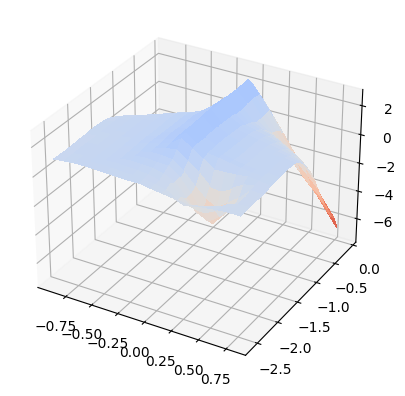

In [6]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# plt.rcParams['font.family'] = 'Times New Roman'

# x = np.arange(-0.9, 0.9, 0.01)
# y = np.arange(-2.6, -0., 0.01)
# x = np.arange(-0.9, 0.9, 0.02)
# y = np.arange(-2.6, -0., 0.02)
# x = np.arange(-0.9, 0.9, 0.05)
# y = np.arange(-2.6, -0., 0.05)
x = np.arange(-0.9, 0.9, 0.1)
y = np.arange(-2.6, -0., 0.1)
X, Y = np.meshgrid(x, y)
size_x = len(x)
size_y = len(y)
V = np.zeros((X.shape))
ego_vx = 0.0
ego_vy = 0.7 # previous 0.8 ##0.2 ebonye/jingqi
ego_z = 0.0
ego_vz = 0.0


ad_x = 0.4
ad_vx = 0.0
ad_y = -2.2
ad_vy = 0.3
ad_z = 0.0
ad_vz = 0.0

# test_array = np.array([-0.69230198, ego_vx, -0.9, ego_vy, ego_z, ego_vz, -ad_x, ad_vx, -0.89, ad_vy, ad_z, ad_vz])

# test_array = np.array([ 0.25685788,  0.02649327, -2.30894741,  0.6951199,   0.05,  0.0,
#  -0.31473293,  0.14431134, -2.17174654,  0.39373078,  0.0,  0.0])

# test_array = np.array([ 0.39257039,  0.06609452, -0.21904182, -0.48617149,  0.01547099,  0.02840657,
  # 0.16452754, -0.09641744, -1.72,        0.3,         0.,          0.        ])
# test_array = np.array([ 0.53599864,  0.11607067, -0.25191225, -0.56366961, -0.12677156, -0.53227077,
#   0.16618932, -0.09328168, -1.72,        0.3,         0.,          0.        ])

# test_array = np.array([
#     -0.66022104,  0.56769637, -2.07759241,  0.89082305, -0.02117593, -0.17434851,
#   0.30126442, -0.17482849, -2.02,        0.3,         0.,          0.        ])

# test_array = np.array([-0.69230198,  0.37234456, -2.14785555,  0.68851169, -0.01525332, -0.06848429,
#   0.31982399, -0.18559575, -2.05,        0.3,         0.,          0.        ])
# # np.array([ 0.97249558,  0.08206725,  0.15634537,  0.19560999, -0.14559874, -0.31301749,
# #   0.23751561, -0.13589741, -1.9,         0.3,         0.,          0.        ])

# test_array = np.array([ 0.28168909,  0.05126452, -1.03617789,  0.88711475, -0.30294119,  0.00639755,
#   0.1400642,  -0.07913508, -1.63,        0.3,         0.,          0.       ])
# ego_vx = test_array[1]
# ego_vy = test_array[3]
# ego_z = test_array[4]
# ego_vz = test_array[5]
# ad_x = test_array[6]
# ad_vx = test_array[7]
# ad_y = test_array[8]
# ad_vy = test_array[9]
# ad_z = test_array[10]
# ad_vz = test_array[11]
X_V = X
Y_V = Y
for ii in tqdm(range(V.shape[0])):
    for jj in range(V.shape[1]):
        tmp_point = torch.tensor([
            X[ii,jj], ego_vx,
            Y[ii,jj], ego_vy,
            ego_z, ego_vz,
            ad_x,  ad_vx,
            ad_y, ad_vy,
            ad_z, ad_vz
        ])
        V[ii,jj] = evaluate_V( tmp_point )
surf = ax.plot_surface(X, Y, V, cmap=cm.coolwarm_r,vmin= V.min(), vmax=-V.min(),
                        linewidth=0, antialiased=False)

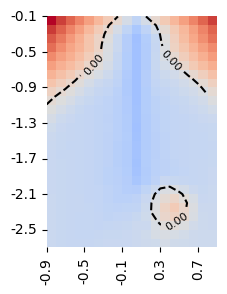

In [7]:
import seaborn as sns

x_interval = 4 #30
y_interval = 4 #60

fig, ax = plt.subplots(figsize=(2.2, 3))
# fig, ax = plt.subplots(figsize=(8, 8))
V_flipped = np.flipud(V)
sns.heatmap(V_flipped, annot=False, cmap=cm.coolwarm_r, ax=ax, vmin= V_flipped.min(), vmax=-V_flipped.min(),
            cbar=False,
            )
x = np.arange(-0.9, 0.9, 0.1)
y = np.arange(-2.6, -0., 0.1)

x_ticks = np.arange(0, len(x), x_interval)
y_ticks = np.arange(0, len(y), y_interval)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.set_xticklabels(np.round(x[::x_interval], 2), rotation=90)
ax.set_yticklabels(np.round(y[::-y_interval]+0.02, 1), rotation=0, ha="right")

# ax.set_xticks(x)
# ax.set_yticks(y)
# contours = ax.contour((X+0.9)*50, (Y+2.6)*50, V_flipped, levels=[0], colors="black", linestyles='dashed')
# contours = ax.contour((X+0.9)*20, (Y+2.6)*20, V_flipped, levels=[0], colors="black", linestyles='dashed')
contours = ax.contour((X+0.9)*10, (Y+2.6)*10, V_flipped, levels=[0], colors="black", linestyles='dashed')

ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
plt.show()


In [249]:
binary_pure_V = np.zeros(V.shape)
binary_pure_V[V > 0] = 1
# print(f"binary_pure_V: {binary_pure_V}")


In [250]:
# Certification method 1: SOCP certification
def get_nominal_traj(state, horizon):
    # env.reset(initial_state = state)
    options = {'initial_state': state}
    env.reset(options=options)
    nominal_traj = np.zeros((12, horizon+1))
    nominal_traj[:,0] = state
    nominal_act = np.zeros((6, horizon))
    constraint_list = np.zeros(horizon+1)
    reach_list = np.zeros(horizon)
    reached = False
    min_constraint = np.Inf
    success = False
    success_time = np.Inf
    for i in range(horizon):
        act = find_a(state)
        act = [act[0], act[1], act[2], 0, 0, 0]
        state, rew, _, _, info = env.step(act)
        nominal_traj[:,i+1] = state
        nominal_act[:,i] = act
        constraint_list[i] = info['constraint']
        reach_list[i] = rew
        min_constraint = min(min_constraint, info['constraint'])
        if rew > 0 and min_constraint > 0:
            success = True
            success_time = i
            break
    ego_traj = nominal_traj[3:7,:]
    return nominal_traj, ego_traj, nominal_act, constraint_list, reach_list, success, success_time


In [251]:
# defining the variables for the optimization problem for SOCP certification
from scipy import sparse
import clarabel

def qp_reach_avoid_variables(T, dt, epsilon_d, nx, nu, nd):
    num_vars = nx * (T+1) + nd * T
    print("number of variables: ", num_vars)
    A = np.eye(nx)
    B = np.zeros((nx, nu))
    D = np.zeros((nx, nd))
    A[0,1] = dt
    A[2,3] = dt
    A[4,5] = dt
    
    A[6,7] = dt    
    A[8,9] = dt
    A[10,11] = dt
    
    control_gain1 = 0.5
    B[1,0] = dt*control_gain1
    B[3,1] = dt*control_gain1
    B[5,2] = dt*control_gain1

    # we embed the feedback control for the adversary drone:
    K1 = np.array([3.1127])
    K2 = np.array([ 9.1704,   16.8205])
    x_star = [0.0, 0.0,
            0.0, 0.3,
            0.0, 0.0
            ]
    A[7,6] = -dt*K2[0]
    A[7,7] = 1 - dt*K2[1]
    
    A[9,9] = 1 - dt*K1[0]

    A[11,10] = -dt*K2[0]
    A[11,11] = 1 - dt*K2[1] # NOTE: we should also fix the offset term in the dynamics!
    
    D[7,0] = dt
    D[9,1] = dt
    D[11,2] = dt
    # now we consider the constraints
    num_eq = nx*T # Mx = N
    M = np.zeros((num_eq, num_vars))
    N = np.zeros((num_eq))
    num_ineq = (nx + nd*T) # double directions, Gx <= H
    # G = [G_x0, G_d]
    
    num_ine_x0 = nx
    G_x0 = np.zeros((num_ine_x0+1, num_vars))
    H_x0 = np.zeros((num_ine_x0+1))

    num_ine_d = nd*T
    G_d = np.zeros((num_ine_d+T, num_vars))
    H_d = np.zeros((num_ine_d+T))
    assert num_ineq == num_ine_x0 + num_ine_d
    cones = [
        clarabel.ZeroConeT(num_eq),     #equality constraints
        clarabel.SecondOrderConeT(num_ine_x0+1)
    ]
    # warm start construction:
    # x0 bound
    G_x0[1:nx+1, 0:nx] = -np.eye(nx) # x0 <= upper
    # compute a sample trajectory and initialize the corresponding SOCP problem variables
    # For later certification, we will substitute different initial conditions and define their corresponding SOCP problems
    # This is just an initialization for the SOCP problem
    x0 = np.array([
    0., -0., # x, vx
    -3.0, 0.2,
    -0.0, 0,
    0.25, 0, # adversary
    -2., 0.2,
    0., 0
    ])
    _, ego_traj, nominal_act, constraint_list, reach_list, success, success_time = get_nominal_traj(x0, T)
    for t in range(T):
        # dynamics:
        # equality constraints
        M[t*nx : (t+1)*nx, t*nx:(t+1)*nx] = -A  # dynamics
        M[t*nx : (t+1)*nx, (t+1)*nx:(t+2)*nx] = np.eye(nx) 
        M[t*nx : (t+1)*nx, (T+1)*nx + t*nd:(T+1)*nx + (t+1)*nd] = -D # -D d_t  #dynamics  x[t+1] - A x[t] + B u[t] - D d_t; B not a variable because comes from the policy
        N[t*nx+1] = dt*nominal_act[0,t]
        N[t*nx+3] = dt*nominal_act[1,t]  #N captures the control input
        N[t*nx+5] = dt*nominal_act[2,t]
        # the adversary state feedback control:
        N[t*nx+7] = dt*(K2[0]*x_star[0]+K2[1]*x_star[1])
        N[t*nx+9] = dt*K1[0]*x_star[3]
        N[t*nx+11] = dt*(K2[0]*x_star[4]+K2[1]*x_star[5])
        G_d[t*(nd+1)+1:(t+1)*(nd+1), (T+1)*nx + t*nd:(T+1)*nx + (t+1)*nd] = -np.eye(nd)
        H_d[t*(nd+1)] = epsilon_d
        cones.append(clarabel.SecondOrderConeT(nd+1))
        
    G = np.concatenate([G_x0, G_d])
    H = np.concatenate([H_x0, H_d])
    zero_sparse_matrix = sparse.csr_matrix((num_vars, num_vars))
    reach_measures = [[np.zeros((num_vars)) for t in range(T)] for i in range(6)] # reachable means: reach_measure * x - reach_offset >0
    reach_offsets = np.zeros(6)
    reach_offsets[2] = -3. # we scale the reach_measure by 10, and therefore the offset should be scaled by 10. The original offset is -0.3
    reach_offsets[3] = -3.
    reach_offsets[4] = -3.
    reach_offsets[5] = -3.
    num_reach_check = len(reach_measures)
    for t in range(T):
        # reach_measures[0] checks whether y1 - y2 > 0
        reach_measures[0][t][t*nx + 2] = 1
        reach_measures[0][t][t*nx + 8] = -1
        
        # reach_measures[1] checks whether v1 - v2 > 0
        reach_measures[1][t][t*nx + 3] = 1
        reach_measures[1][t][t*nx + 9] = -1
        
        # reach_measures[2] checks whether 10 * x1 > 10 * 0.3
        reach_measures[2][t][t*nx + 0] = 10
        reach_measures[3][t][t*nx + 0] = -10
        reach_measures[4][t][t*nx + 4] = 10
        reach_measures[5][t][t*nx + 4] = -10
        
    prox_measures = [[np.zeros((num_vars, num_vars)) if i == 7 else np.zeros(num_vars) for t in range(T)] for i in range(1+1+5+1)] # we removed the speed check! 
    # proximity means: x' * prox_measure * x - prox_offset >0
    # NOTE the above prox_measures[2] represents the quadratic costs for collision avoidance checking!
    
    # they represent the safety cone constraint, speed constraint, and the proximity constraint, and 4 fence constraints
    # when we do certification, we will use the safety cone constraint proximity check to know the maximum flying height difference, and then use it to check proximity
    
    prox_offsets = np.zeros(len(prox_measures))
    prox_offsets[6] = -env.observation_space.high[3] # upper bound on the forward speed
    prox_offsets[7] = 0.2 # collision avoidance, depends on the maximum height difference!
    prox_offsets[0] = -0.1/2 # left fence
    prox_offsets[1] = -0.1/2 # right fence
    prox_offsets[2] = -0.1/2 # top fence
    prox_offsets[3] = -0.1/2 # bottom fence
    for t in range(T):
        prox_measures[0][t][t*nx+0] = 1 # left fence
        prox_measures[0][t][t*nx+2] = -1
        
        prox_measures[1][t][t*nx+0] = -1 # right fence
        prox_measures[1][t][t*nx+2] = -1
        
        prox_measures[2][t][t*nx+2] = -1 # upper fence
        prox_measures[2][t][t*nx+4] = -1
        
        prox_measures[3][t][t*nx+2] = -1 # lower fence
        prox_measures[3][t][t*nx+4] = 1
        
        prox_measures[4][t][t*nx + 10] = -1 # maximize the height difference between the adversary drone and the ego drone
        prox_measures[4][t][t*nx + 4] = 1
        prox_measures[5][t][t*nx + 10] = 1 # maximize the height difference between the adversary drone and the ego drone
        prox_measures[5][t][t*nx + 4] = -1
        
        prox_measures[6][t][t*nx + 3] = -1 # speed constraint, maximize the forward speed and check whether it accelerates too much
        
        prox_measures[7][t][np.ix_(t*nx+np.array([0,2, 6,8]), t*nx+np.array([0,2, 6,8]))] = np.eye(4)
        prox_measures[7][t][np.ix_(t*nx+np.array([0,2]), t*nx+np.array([6,8]))] = -np.eye(2)
        prox_measures[7][t][np.ix_(t*nx+np.array([6,8]), t*nx+np.array([0,2]))] = -np.eye(2)
        prox_measures[7][t] = sparse.csr_matrix(prox_measures[7][t])
        
        
    return G_x0, H_x0, G_d, H_d, M, N, G, H, ego_traj, nominal_act, constraint_list, reach_list, success, success_time, num_vars, num_eq, num_ineq,cones, zero_sparse_matrix, reach_measures, reach_offsets, num_reach_check, prox_measures, prox_offsets


In [252]:
import clarabel
from scipy import sparse
# from time import time
def qp_reach_avoid_checking(delta_x, delta_d, x0, T, dt, M,N,G,H_x0,H_d, num_eq, num_ineq,cones, num_vars,
                            prox_measures, prox_offsets, reach_measures, reach_offsets, zero_sparse_matrix, verbose = False):
    _, ego_traj, nominal_act, constraint_list, reach_list, success, success_time = get_nominal_traj(x0, T)
    if not success:
        print("not success") if verbose else None
        return False, None
    print("x0: ", x0) if verbose else None
    print("success time: ", success_time) if verbose else None
    # we consider dynamics as equality constraints and inequality constraints:
    # x_{t+1} - A x_t + D d_t = B u_t
    # we construct those constraints:
    for t in range(T):
        N[t*nx+1] = dt*nominal_act[0,t]
        N[t*nx+3] = dt*nominal_act[1,t]
        N[t*nx+5] = dt*nominal_act[2,t]
    H_x0[0] = delta_x
    H_x0[1:nx+1] = -x0
    # H_x0[:nx] = x0 + delta_x*np.ones(nx)
    # H_x0[nx:] = -(x0 - delta_x*np.ones(nx))
    H = np.concatenate([H_x0, H_d])

    settings = clarabel.DefaultSettings()
    settings.verbose = False
    A = sparse.vstack([M, G]).tocsc()*10 # equality constraints and inequality constraints
    b = np.concatenate([N, H])*10 # offset of the equality constraints and inequality constraints
    q = np.zeros(num_vars)
    # solver = clarabel.DefaultSolver(P, q, A, b, cones, settings)
    # tmp = solver.solve()
    num_prox_check = len(prox_measures)
    num_reach_check = len(reach_measures)
    proximity_list = np.zeros(num_prox_check*T)
    reach_list = np.zeros(num_reach_check*T)
    solver_status = []
    max_height_diff = 0
    # checking reach avoid
    for t in range(T):
        for i in range(num_prox_check):
            # i = 0: max height difference
            if i == 7:
                # import pdb; pdb.set_trace()
                solver = clarabel.DefaultSolver(prox_measures[i][t], q, A, b, cones, settings)
            else:
                solver = clarabel.DefaultSolver(zero_sparse_matrix, prox_measures[i][t], A, b, cones, settings)
            # print(A.shape)
            # print(b.shape)
            tmp = solver.solve()
            # print(tmp.status) if tmp.status != "Solved" else None
            if i == 7: # max height difference + safety cone constraints!
                proximity_list[t*num_prox_check+i] = tmp.obj_val - 0.5*((1+max_height_diff)*prox_offsets[i])**2 # TODO: double check 2*prox_offsets[i]!
            else:
                proximity_list[t*num_prox_check+i] = tmp.obj_val - prox_offsets[i]
            
            if i == 4:
                max_height_diff = np.abs(tmp.obj_val)
            if i == 5:
                max_height_diff = max(np.abs(tmp.obj_val), max_height_diff)

                
            solver_status.append(tmp.status)
            
            if str(tmp.status) != "Solved":
                print(tmp.status)
                return False, solver_status
            if proximity_list[t*num_prox_check+i] < 0 and i != 4 and i != 5:
                print(tmp.x) if verbose else None
                print("proximity failed at t = {} at i = {} with value = {}".format(t, i, proximity_list[t*num_prox_check+i])) if verbose else None
                return False, solver_status
        
        for i in range(num_reach_check):
            # import pdb; pdb.set_trace()
            solver = clarabel.DefaultSolver(zero_sparse_matrix, reach_measures[i][t], A, b, cones, settings)
            tmp = solver.solve()
            tmp_status = tmp.status
            solver_status.append(tmp_status)
            if str(tmp.status) != "Solved":
                print(tmp.status)
                return False, solver_status
            reach_list[t*num_reach_check+i] = tmp.obj_val - reach_offsets[i]
            solver_status.append(tmp.status)
            if reach_list[t*num_reach_check+i] < 0:
                print("reach failed at t = {} at i = {}".format(t, i)) if verbose else None
                break
            
        if reach_list[t*num_reach_check:(t+1)*num_reach_check].min() > 0:
            return True, solver_status
        
    return False, solver_status



number of variables:  462


  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:27<00:00,  1.07s/it]


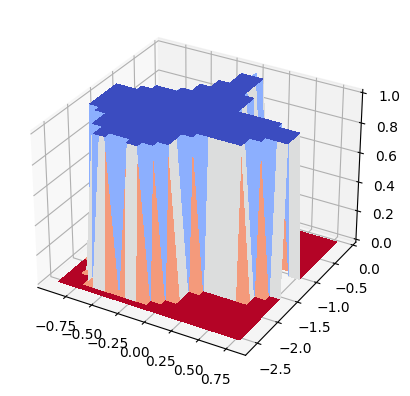

In [253]:
import matplotlib.pyplot as plt
from tqdm import tqdm
from time import time
epsilon_d = 0.1
epsilon_x = 0.1 #0.05 
gamma = args.gamma
T = 30
dt = 0.1
nx = 12
nu = 3
nd = 3
start_time_qp = time()
G_x0, H_x0, G_d, H_d, M, N, G, H, ego_traj, nominal_act, constraint_list, reach_list, success, success_time, num_vars, num_eq, num_ineq,cones, zero_sparse_matrix, reach_measures, reach_offsets, num_reach_check, prox_measures, prox_offsets = qp_reach_avoid_variables(T, dt, epsilon_d, nx, nu, nd)
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
x = np.arange(-0.9, 0.9, epsilon_x)
y = np.arange(-2.6, -0., epsilon_x)
X, Y = np.meshgrid(x, y)
size_x = len(x)
size_y = len(y)
V_qp = np.zeros((X.shape))
status_list = [[[] for i in range(size_x)] for j in range(size_y)]
for ii in tqdm(range(V_qp.shape[0])):
    for jj in range(V_qp.shape[1]):
        tmp_point = np.array([
            X[ii,jj], ego_vx,
            Y[ii,jj], ego_vy,
            ego_z, ego_vz,
            ad_x,  ad_vx,
            ad_y, ad_vy,
            ad_z, ad_vz
        ])
        Done, tmp = qp_reach_avoid_checking(epsilon_x, epsilon_d, tmp_point, T, dt, M,N,G,H_x0,H_d, num_eq, num_ineq,cones, num_vars,
                            prox_measures, prox_offsets, reach_measures, reach_offsets, zero_sparse_matrix, verbose = False)
        status_list[ii][jj] = tmp
        if Done == True:
            V_qp[ii,jj] = 1
        else:
            V_qp[ii,jj] = 0
end_time_qp = time()
total_time_qp = end_time_qp - start_time_qp
surf = ax.plot_surface(X, Y, V_qp, cmap=cm.coolwarm_r,
                        linewidth=0, antialiased=False)


# epsilon x=0.02 takes 30 minutes to certify entire grid

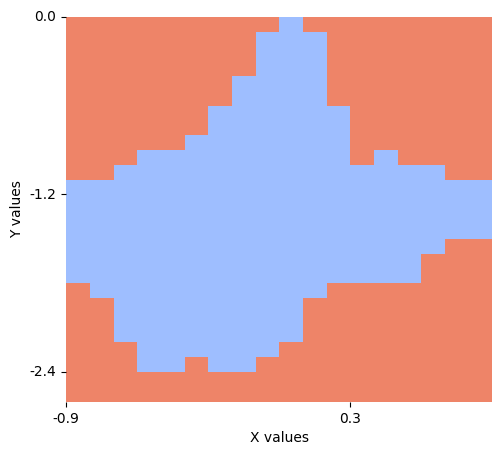

In [255]:
import seaborn as sns

x_interval = 12
y_interval = 12

fig, ax = plt.subplots(figsize=(5.5, 5) )
Vqp_flipped = np.flipud(V_qp)
sns.heatmap(Vqp_flipped, annot=False, cmap=cm.coolwarm_r,alpha = 1,vmin=-0.4,  vmax = 1.6 , ax=ax,cbar=False,
            )
ax.set_xlabel('X values')
ax.set_ylabel('Y values')
x_ticks = np.arange(0, len(x), x_interval)
y_ticks = np.arange(0, len(y), y_interval)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels(np.round(x[::x_interval], 2))
ax.set_yticklabels(np.round(y[::-y_interval]+0.1, 1) )
# contours = ax.contour(X*21, Y*20, V_flipped, levels=[0], colors='black', linestyles='dashed')
ax.clabel(contours, inline=True, fontsize=8, fmt="%.2f")
# change the plot size
plt.show()


In [256]:
confidence = 0.9 # 0.97
delt = 1e-3 #1e-16
# confidence = 0.97
# delt = 1e-16
factor = 1
label = 0


In [257]:
from gymnasium.vector import SyncVectorEnv
from copy import deepcopy
from gymnasium.vector.utils import concatenate

class NoResetSyncVectorEnv(SyncVectorEnv):
    def step_wait(self):
        """Step without automatically resetting environments that are done."""
        observations, infos = [], {}
        for i, (env, action) in enumerate(zip(self.envs, self._actions)):
            obs, reward, terminated, truncated, info = env.step(action)

            # Keep done flags but do NOT reset
            self._rewards[i] = reward
            self._terminateds[i] = terminated
            self._truncateds[i] = truncated

            observations.append(obs)
            infos = self._add_info(infos, info, i)

        self.observations = concatenate(
            self.single_observation_space, observations, self.observations
        )

        return (
            deepcopy(self.observations) if self.copy else self.observations,
            np.copy(self._rewards),
            np.copy(self._terminateds),
            np.copy(self._truncateds),
            infos,
        )



In [258]:
# def compute_min_scenarios_alex(epsilon, delta, d):
#     """
#     Compute the minimum number of scenarios needed to ensure feasibility with given epsilon and delta.
#     """
#     # num = int(np.ceil((math.exp(1) / (epsilon*(math.exp(1)-1)))*(np.log(1/delta) + d*(d+1)/2 + d)))
#     # num = torch.tensor(num, device=device)
#     num = int((2 / epsilon) * (np.log(1 / delta) + (d-1)* np.log(2)))
#     # num = int((2 / epsilon) * (np.log(1 / delta) + 1))
#     return num

# conff = 0.9
# dellt = 1e-3
# dim = 6
# num_scenarios = compute_min_scenarios_alex(1-conff, dellt, dim)
# print("number of scenarios needed for certification: ", num_scenarios)

In [279]:
### Iterative Scenario Optimization Certification Method
# from time import time
import time

env = gym.make(args.task)


def make_new_env(args):
    return gym.make(args.task)

def compute_min_scenarios_alex(epsilon, delta, d):
    """
    Compute the minimum number of scenarios needed to ensure feasibility with given epsilon and delta.
    """
    # num = int(np.ceil((math.exp(1) / (epsilon*(math.exp(1)-1)))*(np.log(1/delta) + d*(d+1)/2 + d)))
    # num = torch.tensor(num, device=device)
    num = int((2 / epsilon) * (np.log(1 / delta) + (d-1)* np.log(2)))
    # num = int((2 / epsilon) * (np.log(1 / delta) + 1))
    return num

def sample_init_cond(N, alpha):
    """
    Sample N initial conditions in state space that satisfy the reach-avoid constraints.
    """
    ego_vx = 0.0
    ego_vy = 0.7 # previous 0.8 ##0.2 ebonye/jingqi
    ego_z = 0.0
    ego_vz = 0.0

    ad_x = 0.4
    ad_vx = 0.0
    ad_y = -2.2
    ad_vy = 0.3
    ad_z = 0.0
    ad_vz = 0.0

    init_cond_final = []
    V_values_final = []
    have_sufficient = False
    try_N = N * 10
    while not have_sufficient:
        # x0 = np.random.uniform(-0.9, 0.9, size=(N, 1))
        # y0 = np.random.uniform(-2.6, -0.0, size=(N, 1))
        # init_cond = np.hstack((x0, np.full((N, 1), ego_vx),
        #                        y0, np.full((N, 1), ego_vy),
        #                        np.full((N, 1), ego_z), np.full((N, 1), ego_vz),
        #                        np.full((N, 1), ad_x), np.full((N, 1), ad_vx),
        #                        np.full((N, 1), ad_y), np.full((N, 1), ad_vy),
        #                        np.full((N, 1), ad_z), np.full((N, 1), ad_vz)))

        x01 = np.random.uniform(-0.9, 0.9, size=(try_N, 1))
        ego_vx1 = np.random.uniform(0, 0.1, size=(try_N, 1))
        y01 = np.random.uniform(-2.6, -0.0, size=(try_N, 1))
        ego_vy1 = np.random.uniform(0.6, 0.8, size=(try_N, 1))
        z01 = np.random.uniform(0, 0.1, size=(try_N, 1))
        ego_vz1 = np.random.uniform(0, 0.1, size=(try_N, 1))
        
        # ad_x1 = np.random.uniform(0.3, 0.5, size=(N, 1))
        # ad_vx1 = np.random.uniform(0, 0.1, size=(N, 1))
        # ad_y1 = np.random.uniform(-2.3, -2.1, size=(N, 1))
        # ad_vy1 = np.random.uniform(0.2, 0.4, size=(N, 1))
        # ad_z1 = np.random.uniform(0, 0.1, size=(N, 1))
        # ad_vz1 = np.random.uniform(0, 0.1, size=(N, 1))
        # z01 = np.full((try_N, 1), ego_z)
        # ego_vz1 = np.full((try_N, 1), ego_vz)
        ad_x1 = np.full((try_N, 1), ad_x)
        ad_vx1 = np.full((try_N, 1), ad_vx)
        ad_y1 = np.full((try_N, 1), ad_y)
        ad_vy1 = np.full((try_N, 1), ad_vy)
        ad_z1 = np.full((try_N, 1), ad_z)
        ad_vz1 = np.full((try_N, 1), ad_vz)

        init_cond = np.hstack((x01, ego_vx1,
                               y01, ego_vy1,
                               z01, ego_vz1,
                               ad_x1, ad_vx1,
                               ad_y1, ad_vy1,
                               ad_z1, ad_vz1))
        
        # Check if the sampled initial conditions satisfy the reach-avoid constraints
        # Use evaluate_V to check the value function
        V_values = evaluate_V_batch(init_cond)
        # Append init cond where V_values > alpha
        valid_indices = np.where(V_values > alpha)[0]
        init_cond_final.append(init_cond[valid_indices])
        V_values_final.append(V_values[valid_indices])
        
        # if len(init_cond_final) >= N:
        total_samps = sum(arr.shape[0] for arr in init_cond_final)
        if total_samps >= N:
            # print(f"len init_cond_final: {len(init_cond_final)}")
            # print(f"type init_cond_final: {type(init_cond_final)}")
            # print(f"N: {N}")
            init_cond_final = np.vstack(init_cond_final)[:N]
            V_values_final = np.hstack(V_values_final)[:N]
            # print(f"init_cond_final shape: {init_cond_final.shape}")
            have_sufficient = True

    return init_cond_final, V_values_final

def sample_noise(N, horizon, epsilon_d):
    """
    Sample N noise vectors in disturbance space.
    """
    # Sample noise vectors uniformly in the disturbance space
    noise = np.random.uniform(-epsilon_d, epsilon_d, size=(N, horizon, 3))
    return noise



def reach_avoid_measure_vectorized(envv, horizon, noise, init_cond_final, V_values):
    """
    Measure the reach-avoid performance of the system given the initial conditions and their corresponding V values.
    This is a vectorized version for efficiency.
    """
    num_samples = init_cond_final.shape[0]
    # print(f"Number of samples for vectorized reach-avoid measure: {num_samples}")
    n_dim = envv.observation_space.shape[0]
    reach_avoid_measures = np.zeros(num_samples)

    # envs = NoResetSyncVectorEnv([make_new_env for _ in range(num_samples)])
    envs = NoResetSyncVectorEnv([lambda: make_new_env(args) for _ in range(num_samples)])
    # print(f"Number of environments created: {envs.num_envs}")
    # options = {'initial_state': init_cond_final}
    # states, _ = envs.reset(initial_states=init_cond_final)
    # states, _ = envs.reset(options=options)
    for i, state in enumerate(init_cond_final):
        envs.envs[i].reset(options={'initial_state': state})

    rewards = np.zeros((num_samples, horizon))
    constraints = np.zeros((num_samples, horizon))
    states = np.array([env.state for env in envs.envs])
    state_trajs = np.zeros((num_samples, n_dim, horizon+1))
    state_trajs[:, :, 0] = states

    for t in range(horizon):
        # acts = find_a_batch(states)
        current_states = np.array([env.state for env in envs.envs])
        acts = find_a_batch(current_states)
        # print(f"acts shape: {acts.shape}")
        actions = np.concatenate((acts[:, :3], np.zeros((num_samples, 3))), axis=1)  # assuming no noise in action for now
        states, rew, done, _, info = envs.step(actions)
        state_trajs[:, :, t+1] = states
        rewards[:, t] = rew
        # import pdb; pdb.set_trace()
        constraints[:, t] = info['constraint']

    min_constraints = np.minimum.accumulate(constraints, axis=1)
    reach_avoid_measures = np.max(np.minimum(rewards, min_constraints), axis=1)
    state_trajs_iterative = state_trajs
    return reach_avoid_measures, state_trajs_iterative
    

def reach_avoid_measure(env, horizon, noise, init_cond_final, V_values):
    """
    Measure the reach-avoid performance of the system given the initial conditions and their corresponding V values.
    """
    num_samples = init_cond_final.shape[0]
    n_dim = env.observation_space.shape[0]
    reach_avoid_measures = np.zeros(num_samples)
    # Lf = 1.05125
    # Lf = 1.06
    # Lc=20
    # Lr=10
    # Ld = 0.1 
    # epsilon_d = 0.1 #### try to make this larger and see what happens
    # epsilon_x = 0.01 # 0.05, 0.01
    # gamma = 0.95
    for i in range(num_samples):
        state = init_cond_final[i]
        V_value = V_values[i]
        
        # Reset the environment with the sampled initial condition
        # env.reset(initial_state=state)
        options = {'initial_state': state}
        env.reset(options=options)
        rewards = np.zeros(horizon)
        constraints = np.zeros(horizon)
        
        # Simulate the environment for the given horizon
        for t in range(horizon):
            act = find_a(state)
            # noise_t = noise[i, t]                         ### different version of somil's work that can handle disturbance
            # action = np.concatenate((act[:3], noise_t))
            action = np.concatenate((act[:3], np.zeros(3)))  # assuming no noise in action for now 9/30/2025

            next_state, rew, _, _, info = env.step(action)
            cstrt = info['constraint']
            # tmp_beta = (Lf**t) * epsilon_x * 0 + (1 - Lf**t)/(1-Lf) * Ld * epsilon_d
            rewards[t] = rew
            # rewards[t] = gamma ** t * (rew - tmp_beta * Lr)  # modified reward to include robustness margin
            constraints[t] = cstrt
            # constraints[t] = gamma ** t * (cstrt - tmp_beta * Lc)  # modified constraint to include robustness margin

            state = next_state

        # Want max (over t){ min(rewards[t], min(over t){ constraints[t] }) }
        reach_avoid_measures[i] = np.max(np.minimum(rewards, np.minimum.accumulate(constraints)))
        # import pdb; pdb.set_trace()
        # reach_avoid_measures[i] = np.min(np.minimum(rewards, np.min(constraints)))

        

    return reach_avoid_measures



    

def get_new_alpha(env, init_cond_final, V_values_final, alpha, horizon, noise):
    """
    Get a new alpha value based on the sampled initial conditions and their corresponding V values
    and reach avoid measures.
    """
    # reach_avoid_measures = reach_avoid_measure(env, horizon, noise, init_cond_final, V_values_final)
    reach_avoid_measures, state_trajs_iterative = reach_avoid_measure_vectorized(env, horizon, noise, init_cond_final, V_values_final)

    # import pdb; pdb.set_trace()

    if np.any(reach_avoid_measures < 0):
        # If any reach-avoid measure is negative, we need to adjust alpha
        new_alpha = np.max(V_values_final[reach_avoid_measures < 0])
    else:
        # If all reach-avoid measures are non-negative, we can keep the current alpha
        new_alpha = alpha

    return new_alpha, state_trajs_iterative

def solve_iterative_method(env, eps, delt, M, horizon, epsilon_d, alpha_init=np.inf):
    """
    Solve the iterative method for reach-avoid certification.
    """
    alpha = alpha_init
    N = compute_min_scenarios_alex(eps, delt, d=12)
    
    start_time = time.time()
    for j in range(M):
        init_cond_final, V_values_final = sample_init_cond(N, alpha)
        # print(f"N: {N}")
        # print(f"init_cond_final shape: {init_cond_final.shape}, V_values_final shape: {V_values_final.shape}")
        noise = sample_noise(N, horizon, epsilon_d)
        new_alpha, state_traj_iterative = get_new_alpha(env, init_cond_final, V_values_final, alpha, horizon, noise)
        if new_alpha == alpha:
            print(f"Converged at iteration {j+1}/{M}, alpha: {alpha:.4f}")
            break
        alpha = new_alpha
        print(f"Iteration {j+1}/{M}, New alpha: {alpha:.4f}")
    
    end_time = time.time()
    total_time = end_time - start_time

    return alpha, total_time, state_traj_iterative


M = 7
horizon = 30 #20
# confidence = 0.97
eps = 1-confidence
# delt = 1e-16
#############
# N = compute_min_scenarios_alex(eps, delt)
# print(f"Number of samples: {N}, Confidence:{confidence}, delta: {delt}")
# alpha = - np.inf
# epsilon_d = 0.1

# start_time = time.time()
# for _ in range(M):
#     # print("Current alpha: ", alpha)
#     init_cond_final, V_values_final = sample_init_cond(N, alpha)
#     noise = sample_noise(N, horizon, epsilon_d)
#     new_alpha = get_new_alpha(init_cond_final, V_values_final, alpha, horizon, noise)
#     alpha = new_alpha
    
#     print("New alpha: ", alpha)

# end_time = time.time()
# print(f"Total time taken: {end_time - start_time:.2f} seconds")
#####
alpha, total_time, state_traj_iterative = solve_iterative_method(env, eps, delt, M, horizon, epsilon_d, alpha_init=-np.inf)
print(f"Final alpha: {alpha:.4f}, Total time taken: {total_time:.2f} seconds")

Iteration 1/7, New alpha: 0.3531
Iteration 2/7, New alpha: 0.6408
Converged at iteration 3/7, alpha: 0.6408
Final alpha: 0.6408, Total time taken: 1.01 seconds


In [260]:
print("Final alpha: ", alpha)

Final alpha:  0.5780848


In [261]:
### Lipschitz Scenario Optimization Certification (suspicious rigor)
import cvxpy as cp
# import time

certification_gamma = args.gamma
# env = gym.make(args.task)
# def compute_min_scenarios_alex(epsilon, delta, d=4):
#     """
#     Compute the minimum number of scenarios needed to ensure feasibility with given epsilon and delta.
#     """
#     # num = int(np.ceil((math.exp(1) / (epsilon*(math.exp(1)-1)))*(np.log(1/delta) + d*(d+1)/2 + d)))
#     # num = torch.tensor(num, device=device)
#     # num = int((2 / epsilon) * (np.log(1 / delta) + (d-1)* np.log(2)))
#     num = int((2 / epsilon) * (np.log(1 / delta) + 1))
#     return num

def sample_noise(num_samples, horizon, noise_level=0.1):
    """
    Sample noise uniformly using NumPy.
    """
    # total_time = int(horizon / dt)
    total_time = horizon  # Assuming horizon is the total time steps
    noise_x = np.random.rand(num_samples, total_time) * 2 * noise_level - noise_level
    noise_y = np.random.rand(num_samples, total_time) * 2 * noise_level - noise_level
    noise_z = np.random.rand(num_samples, total_time) * 2 * noise_level - noise_level
    return np.stack((noise_x, noise_y, noise_z), axis=-1)  # Shape: [num_samples, total_time, 3]

def sample_initial_states(init_cond, num_samples, epsilon=0.01):
    """
    Sample initial states uniformly in epsilon-neighborhood (ball) of the initial condition using NumPy.
    """
    dim = init_cond.shape[0]

    # Sample uniformly in the epsilon-ball
    directions = np.random.randn(num_samples, dim)
    directions /= np.linalg.norm(directions, axis=1, keepdims=True)  # Normalize to unit vectors

    radii = np.random.rand(num_samples) ** (1 / dim)
    radii *= epsilon  # Scale by epsilon to fit in the ball

    samples = init_cond.reshape(1, -1) + radii[:, np.newaxis] * directions
    return samples

def sample_state_trajectories(env, initial_states, noise_trajs, horizon):
    """
    Sample state trajectories from the environment given initial states and noise.
    """
    num_samples = initial_states.shape[0]
    n_dim = env.observation_space.shape[0]
    state_trajs = []

    for i in range(num_samples):
        state_traj = np.zeros((n_dim, horizon + 1))
        state = initial_states[i]
        state_traj[:, 0] = state
        env.reset(initial_state=state)
        for t in range(horizon):
            action = find_a(state_traj[:, t])
            action = [action[0], action[1], action[2], 0, 0, 0]
            # Add noise to the action
            noise = noise_trajs[i, t] if noise_trajs is not None else np.zeros(3)
            noise = np.concatenate((np.zeros(3), noise))  # Add zeros for the control inputs
            action = np.array(action) + noise
            # import pdb; pdb.set_trace()
            next_state, _, _, _, _ = env.step(action)

            state_traj[:, t + 1] = next_state
        state_trajs.append(state_traj)
    return np.array(state_trajs)  # Shape: [num_samples, n_dim, horizon + 1]

def sample_state_trajectories2(env, initial_states, noise_trajs, horizon):
    """
    Sample state trajectories from the environment given initial states and noise.
    """
    num_init_samples = initial_states.shape[0]
    num_total_samples = noise_trajs.shape[0]
    num_noise_samples = num_total_samples // num_init_samples
    n_dim = env.observation_space.shape[0]
    # state_trajs = np.zeros((num_init_samples, n_dim, horizon + 1))
    state_trajs = np.zeros((num_init_samples, num_noise_samples, n_dim, horizon + 1))

    # Loop through each initial state
    for i in range(num_init_samples):
        state_traj = np.zeros((num_noise_samples, n_dim, horizon + 1))
        state = initial_states[i]
        state_traj[:, :, 0] = state
        env.reset(initial_state=state)
        # Loop through each noise sample
        for j in range(num_noise_samples):
            env.reset(initial_state=state)  # Reset the environment for each noise sample
            for t in range(horizon):
                action = find_a(state_traj[j, :, t])
                action = [action[0], action[1], action[2], 0, 0, 0]
                # Add noise to the action
                noise = noise_trajs[i * num_noise_samples + j, t] if noise_trajs is not None else np.zeros(3)
                noise = np.concatenate((np.zeros(3), noise))  # Add zeros for the control inputs
                action = np.array(action) + noise
                next_state, _, _, _, _ = env.step(action)
                state_traj[j, :, t + 1] = next_state
                # import pdb; pdb.set_trace()
        state_trajs[i] = state_traj  # Store the trajectories for this initial state

    # import pdb; pdb.set_trace()
    return state_trajs  # Shape: [num_init_samples, num_noise_samples, n_dim, horizon + 1]

    # for i in range(num_init_samples):
    #     state_traj = np.zeros((n_dim, horizon + 1))
    #     state = initial_states[i]
    #     state_traj[:, 0] = state
    #     env.reset(initial_state=state)
    #     for t in range(horizon):
    #         action = find_a(state_traj[:, t])
    #         action = [action[0], action[1], action[2], 0, 0, 0]
    #         # Add noise to the action
    #         noise = noise_trajs[i * horizon + t]
    #         noise = np.concatenate((np.zeros(3), noise))  # Add zeros for the control inputs
    #         action = np.array(action) + noise
    #         next_state, _, _, _, _ = env.step(action)
    #         state_traj[:, t + 1] = next_state
    #     state_trajs[i] = state_traj
    # return state_trajs  # Shape: [num_init_samples, n_dim, horizon + 1]


# def get_nominal_trajectory(env, initial_state, horizon):
#     """
#     Get the nominal trajectory from the environment given an initial state.
#     """
#     env.reset(initial_state=initial_state)
#     state_traj = np.zeros((env.observation_space.shape[0], horizon + 1))
#     state_traj[:, 0] = initial_state

#     for t in range(horizon):
#         action = find_a(state_traj[:, t])
#         action = [action[0], action[1], action[2], 0, 0, 0]
#         next_state, _, _, _, _ = env.step(action)
#         state_traj[:, t + 1] = next_state

#     return state_traj

def get_nominal_trajectory2(env, initial_states, horizon):
    """
    Get the nominal trajectory from the environment given initial states.
    """
    num_init_samples = initial_states.shape[0]
    n_dim = env.observation_space.shape[0]
    state_trajs = np.zeros((num_init_samples, n_dim, horizon+ 1))
    actions = np.zeros((num_init_samples, 6, horizon))

    for i in range(num_init_samples):
        state_traj = np.zeros((n_dim, horizon + 1))
        state = initial_states[i]
        state_traj[:, 0] = state
        # env.reset(initial_state=state)
        env.reset(options={'initial_state': state})


        for t in range(horizon):
            action = find_a(state_traj[:, t])
            action = [action[0], action[1], action[2], 0, 0, 0]
            next_state, _, _, _, _ = env.step(action)
            state_traj[:, t + 1] = next_state
            actions[i, :, t] = action

        state_trajs[i] = state_traj

    return state_trajs, actions  # Shape: [num_init_samples, n_dim, horizon]

##### 1/13/2026 (Ebonye): Vectorized get_nominal trajectory2
def get_nominal_trajectory2_vectorized(env, initial_states,horizon):
    """
    Get the nominal trajectory from the environment given initial states.
    This is a vectorized version for efficiency.
    """
    num_samples = initial_states.shape[0]
    n_dim = env.observation_space.shape[0]
    state_trajs = np.zeros((num_samples, n_dim, horizon + 1))
    actions = np.zeros((num_samples, 6, horizon))

    # envs = NoResetSyncVectorEnv([make_new_env for _ in range(num_samples)])
    envs = NoResetSyncVectorEnv([lambda: make_new_env(args) for _ in range(num_samples)])
    for i, state in enumerate(initial_states):
        envs.envs[i].reset(options={'initial_state': state})

    states = np.array([env.state for env in envs.envs])
    state_trajs[:, :, 0] = states

    for t in range(horizon):
        acts = find_a_batch(states)
        actions[:, :, t] = np.concatenate((acts[:, :3], np.zeros((num_samples, 3))), axis=1)  # assuming no noise in action for now
        states, _, _, _, _ = envs.step(actions[:, :, t])
        state_trajs[:, :, t + 1] = states

    return state_trajs, actions  # Shape: [num_samples, n_dim, horizon]

def get_state_trajectory2(env, initial_states, actions, horizon):
    """
    Get the state trajectory from the environment given initial states and actions.
    """
    num_init_samples = initial_states.shape[0]
    n_dim = env.observation_space.shape[0]
    state_trajs = np.zeros((num_init_samples, n_dim, horizon + 1))

    for i in range(num_init_samples):
        state_traj = np.zeros((n_dim, horizon + 1))
        state = initial_states[i]
        state_traj[:, 0] = state
        env.reset(options={'initial_state': state})

        for t in range(horizon):
            action = actions[i, :, t]
            next_state, _, _, _, _ = env.step(action)
            state_traj[:, t + 1] = next_state

        state_trajs[i] = state_traj

    return state_trajs  # Shape: [num_init_samples, n_dim, horizon]

def get_state_trajectory2_vectorized(env, initial_states, actions, horizon):
    """
    Get the state trajectory from the environment given initial states and actions.
    This is a vectorized version for efficiency.
    """
    num_samples = initial_states.shape[0]
    n_dim = env.observation_space.shape[0]
    state_trajs = np.zeros((num_samples, n_dim, horizon + 1))

    # envs = NoResetSyncVectorEnv([make_new_env for _ in range(num_samples)])
    envs = NoResetSyncVectorEnv([lambda: make_new_env(args) for _ in range(num_samples)])
    for i, state in enumerate(initial_states):
        envs.envs[i].reset(options={'initial_state': state})

    states = np.array([env.state for env in envs.envs])
    state_trajs[:, :, 0] = states

    for t in range(horizon):
        states, _, _, _, _ = envs.step(actions[:, :, t])
        state_trajs[:, :, t + 1] = states

    return state_trajs  # Shape: [num_samples, n_dim, horizon]

def scenario_opt_prob(state_trajs):
    """
    Solve the scenario optimization problem to find the worst-case scenario and return 
    radius for each time step.
    """
    num_samples, n_dim, horizon = state_trajs.shape
    radius = np.zeros(horizon)
    beta = np.zeros(horizon)
    center = np.zeros((horizon, n_dim))  # Center for each time step
    start_time = time.time()
    # import pdb; pdb.set_trace()
    for t in range(horizon):
        # Solve optimization problem for each time step
        # print(f"Solving optimization for time step {t}...")
        rad = cp.Variable(nonneg=True)
        cent = cp.Variable(n_dim)

        constraints = []
        for i in range(num_samples):
            constraints.append(cp.norm(state_trajs[i, :, t] - cent) <= rad)

        objective = cp.Minimize(rad)
        prob = cp.Problem(objective, constraints)

        prob.solve()
        radius[t] = rad.value
        beta[t] = rad.value * certification_gamma**t
        center[t] = cent.value
        
    end_time = time.time()
    # print(f"Optimization completed in {end_time - start_time:.2f} seconds.")
    return radius, beta, center  # Return the radius for each time step

def scenario_opt_general(state_trajs, nominal_traj):
    """
    Solve the scenario optimization problem to find smallest radii such that the worst-case scenario is within the radius.
    """
    num_inits, num_noise, n_dim, horizon = state_trajs.shape
    # print(f"state_trajs shape: {state_trajs.shape}")
    # print(f"nominal_traj shape: {nominal_traj.shape}")
    # nominal_expanded = nominal_traj[:, None, :, :]
    # deviations = np.linalg.norm(state_trajs - nominal_expanded, axis=2)  # Shape: [num_inits, num_noise, horizon]
    # deviations_flat = deviations.reshape(-1, horizon)
    # radius = np.zeros(horizon)
    # betas = np.zeros(horizon)

    # time optimization start
    start_time = time.time()

    # rad = cp.Variable(horizon, nonneg=True)
    rad = cp.Variable((horizon), nonneg=True)  # Radius for each initial state and time step
    cent = cp.Variable((num_inits, n_dim, horizon))  # Center for each initial state
    constraints = []

    for i in range(num_inits):
        for j in range(num_noise):
            for t in range(horizon):
                # For each initial state, noise sample, and time step, we need to ensure that the deviation is within the radius
                # constraints.append(cp.norm(state_trajs[i, j, :, t] - cent[i, :, t]) <= rad[t])
                constraints.append(cp.norm(state_trajs[i, j, :, t] - nominal_traj[i, :, t]) <= rad[t])


    # for t in range(horizon):
    #     # For each time step, we need to ensure that all deviations are within the radius
    #     for i in range(num_inits):
    #         constraints.append(deviations[i, :, t] <= rad[i, t])
    
    # constraints = [deviations_flat <= rad[None, :]]  

    # Objective is to minimize the maximum radius across all time steps, radius output shape should be (horizon,)
    # objective = cp.Minimize(cp.max(rad))
    objective = cp.Minimize(cp.sum(rad))
    prob = cp.Problem(objective, constraints)
    prob.solve()
    # time optimization end
    end_time = time.time()
    # print(f"Optimization completed in {end_time - start_time:.2f} seconds.")
    total_time = end_time - start_time
    radius = rad.value  # Shape: [num_inits, horizon]
    # betas = radius * certification_gamma ** np.arange(horizon)  # Shape: [num_inits, horizon]

    # import pdb; pdb.set_trace()

    
    
    return radius, total_time



# def get_beta(env, T, epsilon_x, epsilon_d):
# # def get_beta(env, x0, T, epsilon_x, epsilon_d):
#     d = 12
#     eps = 0.9 #0.05
#     delt = 0.01
#     num_scenarios = compute_min_scenarios_alex(eps, delt, d+1)
#     # print("Number of scenarios: ", num_scenarios)
#     x0 = np.array([
#     0., -0., # x, vx
#     -3.0, 0.2,
#     -0.0, 0,
#     0.25, 0, # adversary
#     -2., 0.2,
#     0., 0
#     ])

#     initial_states = sample_initial_states(x0, num_scenarios, epsilon=epsilon_x)

#     # just 1 initial state
#     # initial_states = np.tile(x0, (num_scenarios, 1))
#     noise = sample_noise(num_scenarios, T, noise_level=epsilon_d)
#     # horizon = int(T / dt)

#     state_trajs = sample_state_trajectories(env, initial_states, noise, T)
#     nominal_traj = get_nominal_trajectory(env, x0, T)
#     # import pdb; pdb.set_trace()
#     radius, betas, center = scenario_opt_prob(state_trajs)

#     # import pdb; pdb.set_trace()

#     return  betas

def get_beta2(env, T, epsilon_x, epsilon_d, label=0):
    # label = 0 --> num_noise_scenarios == factor
    # label = 1 --> num_init_scenarios == factor
    d = 12
    # eps = 0.03
    eps = 1 - confidence
    # delt = 1e-16 #0.01
    num_scenarios = compute_min_scenarios_alex(eps, delt, d)
    # factor = 20
    num_scenarios_rounded = factor * np.round(num_scenarios / factor).astype(int)
    print("Number of scenarios: ", num_scenarios_rounded)
    # num_init_scenarios = np.ceil(num_scenarios / 5).astype(int)
    num_init_scenarios = num_scenarios_rounded // factor if label == 0 else factor
    num_noise_scenarios = factor if label == 0 else num_scenarios_rounded // factor

    # # num_init_scenarios = 20
    # # num_noise_scenarios = num_scenarios_rounded // num_init_scenarios
    
    x_bounds = [-0.9, 0.9]
    y_bounds = [-2.6, 0]

    # Sample initial x and y uniformly within the bounds
    init_ego_x = np.random.uniform(x_bounds[0], x_bounds[1], num_init_scenarios)
    init_ego_vx = np.ones(num_init_scenarios)*ego_vx
    init_ego_y = np.random.uniform(y_bounds[0], y_bounds[1], num_init_scenarios)
    init_ego_vy = np.ones(num_init_scenarios)*ego_vy
    init_ego_z = np.ones(num_init_scenarios)*ego_z
    init_ego_vz = np.ones(num_init_scenarios)*ego_vz

    init_ad_x = np.ones(num_init_scenarios)*ad_x
    init_ad_vx = np.ones(num_init_scenarios)*ad_vx
    init_ad_y = np.ones(num_init_scenarios)*ad_y
    init_ad_vy = np.ones(num_init_scenarios)*ad_vy
    init_ad_z = np.ones(num_init_scenarios)*ad_z
    init_ad_vz = np.ones(num_init_scenarios)*ad_vz

    # # sample initial conditions 9/23/2025

    # X_points = X_V
    # Y_points = Y_V

    # x_ego = []
    # y_ego = []

    # x_rand = np.random.uniform(X_points.min(), X_points.max(), num_init_scenarios)
    # y_rand = np.random.uniform(Y_points.min(), Y_points.max(), num_init_scenarios)
    # from scipy.interpolate import RegularGridInterpolator
    # interp_func = RegularGridInterpolator((X_points[0,:], Y_points[:,0]), V.T)
    # vals = interp_func(np.vstack((x_rand, y_rand)).T)

    # inside_certified = vals > 0
    # x_ego.extend(x_rand[inside_certified])
    # y_ego.extend(y_rand[inside_certified])

    # # while np.sum(inside_certified) < num_init_scenarios:
    # while len(x_ego) < num_init_scenarios:
    #     x_rand = np.random.uniform(X_points.min(), X_points.max(), num_init_scenarios)
    #     y_rand = np.random.uniform(Y_points.min(), Y_points.max(), num_init_scenarios)
    #     vals = interp_func(np.vstack((x_rand, y_rand)).T)
    #     inside_certified = vals > 0
    #     x_ego.extend(x_rand[inside_certified])
    #     y_ego.extend(y_rand[inside_certified])

    # x_ego = np.array(x_ego[:num_init_scenarios])
    # y_ego = np.array(y_ego[:num_init_scenarios])

    # init_ego_x = x_ego
    # init_ego_vx = np.ones(num_init_scenarios)*ego_vx
    # init_ego_y = y_ego
    # init_ego_vy = np.ones(num_init_scenarios)*ego_vy
    # init_ego_z = np.ones(num_init_scenarios)*ego_z
    # init_ego_vz = np.ones(num_init_scenarios)*ego_vz
    # init_ad_x = np.ones(num_init_scenarios)*ad_x
    # init_ad_vx = np.ones(num_init_scenarios)*ad_vx
    # init_ad_y = np.ones(num_init_scenarios)*ad_y
    # init_ad_vy = np.ones(num_init_scenarios)*ad_vy
    # init_ad_z = np.ones(num_init_scenarios)*ad_z
    # init_ad_vz = np.ones(num_init_scenarios)*ad_vz


    # Create initial states array
    initial_states = np.column_stack((init_ego_x, init_ego_vx,
                                      init_ego_y, init_ego_vy,
                                      init_ego_z, init_ego_vz,
                                      init_ad_x, init_ad_vx,
                                      init_ad_y, init_ad_vy,
                                      init_ad_z, init_ad_vz))
    
    # Sample noise uniformly using NumPy
    noise = sample_noise(num_init_scenarios*num_noise_scenarios, T, noise_level=epsilon_d)
    
    # Compute state trajectories
    state_trajs = sample_state_trajectories2(env, initial_states, noise, T) # shape [num_init_scenarios, num_noise_scenarios, n_dim, horizon + 1]

    # Get nominal trajectory
    nominal_trajs = get_nominal_trajectory2(env, initial_states, T) # shape [num_init_scenarios, n_dim, horizon + 1]

    # Solve scenario optimization problem
    radius, total_time = scenario_opt_general(state_trajs, nominal_trajs)
    # print(f"Radii: {radius}")

    return radius, total_time, initial_states, nominal_trajs, state_trajs

def calibrate_V_scenario(env, state, horizon, alphaC_list_scenario, alphaR_list_scenario, verbose = False):
    ### sampling requires incorporating noise. how to incorporate noise here?
    n_dim = env.observation_space.shape[0]
    state_traj = np.zeros((n_dim, horizon+1))
    state_traj[:,0] = state
    # env.reset(initial_state = state)
    options = {'initial_state': state}
    env.reset(options=options)
    
    # gamma = args.gamma
    value_list = np.array([])
    constraint_list = np.array([])
    # time_reach_avoid = 0
    # print(f"horizon: {horizon}")
    for t in range(horizon):
        action = find_a(state_traj[:,t])
        # modify action
        action = np.array([action[0], action[1], action[2], 0, 0, 0])
        # noise = np.random.uniform(-epsilon_d, epsilon_d, size=3)  #
        # noise = np.concatenate((np.zeros(3), noise))  # Add zeros for the control inputs
        # action = np.array(action) + noise
        tmp, rew, _, _, info = env.step(action)
        state_traj[:,t+1] = tmp
        
        # import pdb; pdb.set_trace()
        # print(f"t: {t}")
        tmp_constraint = info["constraint"]*certification_gamma**t - alphaC_list_scenario[t]
        # constraint_list = np.append(constraint_list, tmp_constraint)
        # if tmp_constraint < 0:
        #     # time_reach_avoid = horizon + 1
        #     time_reach_avoid = t 
        #     # time_reach_avoid = np.nan
        #     return -1e-3, time_reach_avoid, False
        constraint_list = np.append(constraint_list, tmp_constraint)
        tmp_value = np.min([ certification_gamma**t * rew - alphaR_list_scenario[t], 
                            np.min(constraint_list) ]) # TODO: program the empirical value function
        # if tmp_value > 0:
        #     time_reach_avoid = t
        #     return 1, time_reach_avoid, True
        value_list = np.append(value_list, tmp_value)
        
    empirical_value = max(value_list)
    # empirical_value = 0 if empirical_value < 0 else 1
    # time_reach_avoid = horizon + 1 if empirical_value < 0 else horizon
    # time_reach_avoid = np.nan if empirical_value < 0 else horizon
    time_reach_avoid = np.argmax(value_list) # if empirical_value > 0 else horizon 
    
    # return empirical_value, time_reach_avoid, constraint_list
    return empirical_value, time_reach_avoid, empirical_value > 0
    

def calibrate_V_scenario2(env, state, horizon, alphaC_list_scenario, alphaR_list_scenario, verbose = False):
    ### sampling requires incorporating noise. how to incorporate noise here?
    n_dim = env.observation_space.shape[0]
    state_traj = np.zeros((n_dim, horizon+1))
    state_traj[:,0] = state
    options = {'initial_state': state}
    env.reset(options=options)
    
    # gamma = args.gamma
    value_list = np.array([])
    constraint_list = np.array([])
    # time_reach_avoid = 0
    for t in range(horizon):
        action = find_a(state_traj[:,t])
        # modify action
        action = np.array([action[0], action[1], action[2], 0, 0, 0])
        # noise = np.random.uniform(-epsilon_d, epsilon_d, size=3)  #
        # noise = np.concatenate((np.zeros(3), noise))  # Add zeros for the control inputs
        # action = np.array(action) + noise
        tmp, rew, _, _, info = env.step(action)
        state_traj[:,t+1] = tmp
        
        # import pdb; pdb.set_trace()
        tmp_constraint = info["constraint"]*certification_gamma**t - alphaC_list_scenario[t]
        # constraint_list = np.append(constraint_list, tmp_constraint)
        if tmp_constraint < 0:
            # time_reach_avoid = horizon + 1
            time_reach_avoid = t 
            # time_reach_avoid = np.nan
            return -1e-3, time_reach_avoid, False
        constraint_list = np.append(constraint_list, tmp_constraint)
        tmp_value = np.min([ certification_gamma**t * rew - alphaR_list_scenario[t], 
                            np.min(constraint_list) ]) # TODO: program the empirical value function
        if tmp_value > 0:
            time_reach_avoid = t
            return 1, time_reach_avoid, True
        value_list = np.append(value_list, tmp_value)
        
    empirical_value = max(value_list)
    empirical_value = 0 if empirical_value < 0 else 1
    # time_reach_avoid = horizon + 1 if empirical_value < 0 else horizon
    # time_reach_avoid = np.nan if empirical_value < 0 else horizon
    time_reach_avoid = np.argmax(value_list)  if empirical_value > 0 else horizon 
    
    # return empirical_value, time_reach_avoid, constraint_list
    return empirical_value, time_reach_avoid, empirical_value > 0
    
# def calibrate_V_scenario2(env, state, horizon, epsilon_d, epsilon_x, Lc, Lr, verbose = False):
#     ### sampling requires incorporating noise. how to incorporate noise here?
#     n_dim = env.observation_space.shape[0]
#     state_traj = np.zeros((n_dim, horizon+1))
#     state_traj[:,0] = state
#     env.reset(initial_state = state)

#     # Get beta values for the scenario optimization
#     betas, center = get_beta(env, state, horizon, epsilon_x, epsilon_d)

#     env.reset(initial_state=state)

#     alphaC_list_scenario = Lc * betas
#     alphaR_list_scenario = Lr * betas
    
#     # gamma = args.gamma
#     value_list = np.array([])
#     constraint_list = np.array([])
#     # time_reach_avoid = 0
#     for t in range(horizon):
#         action = find_a(state_traj[:,t])
#         # modify action
#         action = np.array([action[0], action[1], action[2], 0, 0, 0])
#         # Add noise to the action
#         noise = np.random.uniform(-epsilon_d, epsilon_d, size=3)  #
#         noise = np.concatenate((np.zeros(3), noise))  # Add zeros for the control inputs
#         action = np.array(action) + noise
        
#         tmp, rew, _, _, info = env.step(action)
#         state_traj[:,t+1] = tmp
        
#         # import pdb; pdb.set_trace()
#         tmp_constraint = info["constraint"]*certification_gamma**t - alphaC_list_scenario[t]
#         if tmp_constraint < 0:
#             # time_reach_avoid = horizon + 1
#             time_reach_avoid = np.nan
#             return -1e-3, time_reach_avoid
#         constraint_list = np.append(constraint_list, tmp_constraint)
#         tmp_value = np.min([ certification_gamma**t * rew - alphaR_list_scenario[t], 
#                             np.min(constraint_list) ]) # TODO: program the empirical value function
#         if tmp_value > 0:
#             time_reach_avoid = t + 1
#             return 1, time_reach_avoid
#         value_list = np.append(value_list, tmp_value)
        
#     empirical_value = max(value_list)
#     empirical_value = 0 if empirical_value < 0 else 1
#     # time_reach_avoid = horizon + 1 if empirical_value < 0 else horizon
#     time_reach_avoid = np.nan if empirical_value < 0 else horizon
    
#     return empirical_value, time_reach_avoid
    

    




    

In [262]:
## Lipschitz + Scenario Method with iid (one trajectory per initial condition) 8/14/2025


# def get_beta4(env, T, epsilon_x, epsilon_d):
#     d = 12
#     # eps = 0.03
#     eps = 1 - confidence
#     # delt = 1e-16 #0.01
#     num_scenarios = compute_min_scenarios_alex(eps, delt, d)
#     # num_scenarios = 10
    
    
#     x_bounds = [-0.9, 0.9]
#     y_bounds = [-2.6, 0]

#     ## Sample init conds and deviated init conds
#     # Sample init x and y uniformly within 2d box bounds
#     init_ego_x = np.random.uniform(x_bounds[0], x_bounds[1], num_scenarios)
#     init_ego_y = np.random.uniform(y_bounds[0], y_bounds[1], num_scenarios)

#     # Sample deviated init x and y uniformly within epsilon_x ball around each init condition
#     theta = np.random.uniform(0, 2 * np.pi, num_scenarios)
#     r = epsilon_x * np.sqrt(np.random.uniform(0, 1, num_scenarios))
#     # print(f"r: {r}")
#     dev_ego_x = r * np.cos(theta) + init_ego_x
#     dev_ego_y = r * np.sin(theta) + init_ego_y

#     # print(f"init_ego_x: {init_ego_x}")
#     # print(f"dev_ego_x: {dev_ego_x}")
#     # print(f"init_ego_y: {init_ego_y}")
#     # print(f"dev_ego_y: {dev_ego_y}")

#     init_ego_vx = np.ones(num_scenarios)*ego_vx
#     init_ego_vy = np.ones(num_scenarios)*ego_vy
#     init_ego_z = np.ones(num_scenarios)*ego_z
#     init_ego_vz = np.ones(num_scenarios)*ego_vz

#     init_ad_x = np.ones(num_scenarios)*ad_x
#     init_ad_vx = np.ones(num_scenarios)*ad_vx
#     init_ad_y = np.ones(num_scenarios)*ad_y
#     init_ad_vy = np.ones(num_scenarios)*ad_vy
#     init_ad_z = np.ones(num_scenarios)*ad_z
#     init_ad_vz = np.ones(num_scenarios)*ad_vz



#     # # Sample initial x and y uniformly within the bounds
#     # init_ego_x = np.random.uniform(x_bounds[0], x_bounds[1], num_scenarios)
#     # init_ego_vx = np.ones(num_scenarios)*ego_vx
#     # init_ego_y = np.random.uniform(y_bounds[0], y_bounds[1], num_scenarios)
#     # init_ego_vy = np.ones(num_scenarios)*ego_vy
#     # init_ego_z = np.ones(num_scenarios)*ego_z
#     # init_ego_vz = np.ones(num_scenarios)*ego_vz

#     # init_ad_x = np.ones(num_scenarios)*ad_x
#     # init_ad_vx = np.ones(num_scenarios)*ad_vx
#     # init_ad_y = np.ones(num_scenarios)*ad_y
#     # init_ad_vy = np.ones(num_scenarios)*ad_vy
#     # init_ad_z = np.ones(num_scenarios)*ad_z
#     # init_ad_vz = np.ones(num_scenarios)*ad_vz

#     # # sample initial conditions 9/23/2025

#     # X_points = X_V
#     # Y_points = Y_V

#     # x_ego = []
#     # y_ego = []

#     # x_rand = np.random.uniform(X_points.min(), X_points.max(), num_scenarios)
#     # y_rand = np.random.uniform(Y_points.min(), Y_points.max(), num_scenarios)
#     # from scipy.interpolate import RegularGridInterpolator
#     # interp_func = RegularGridInterpolator((X_points[0,:], Y_points[:,0]), V.T)
#     # vals = interp_func(np.vstack((x_rand, y_rand)).T)

#     # inside_certified = vals > 0
#     # x_ego.extend(x_rand[inside_certified])
#     # y_ego.extend(y_rand[inside_certified])

#     # # while np.sum(inside_certified) < num_init_scenarios:
#     # while len(x_ego) < num_scenarios:
#     #     x_rand = np.random.uniform(X_points.min(), X_points.max(), num_scenarios)
#     #     y_rand = np.random.uniform(Y_points.min(), Y_points.max(), num_scenarios)
#     #     vals = interp_func(np.vstack((x_rand, y_rand)).T)
#     #     inside_certified = vals > 0
#     #     x_ego.extend(x_rand[inside_certified])
#     #     y_ego.extend(y_rand[inside_certified])

#     # x_ego = np.array(x_ego[:num_scenarios])
#     # y_ego = np.array(y_ego[:num_scenarios])

#     # init_ego_x = x_ego
#     # init_ego_vx = np.ones(num_scenarios)*ego_vx
#     # init_ego_y = y_ego
#     # init_ego_vy = np.ones(num_scenarios)*ego_vy
#     # init_ego_z = np.ones(num_scenarios)*ego_z
#     # init_ego_vz = np.ones(num_scenarios)*ego_vz
#     # init_ad_x = np.ones(num_scenarios)*ad_x
#     # init_ad_vx = np.ones(num_scenarios)*ad_vx
#     # init_ad_y = np.ones(num_scenarios)*ad_y
#     # init_ad_vy = np.ones(num_scenarios)*ad_vy
#     # init_ad_z = np.ones(num_scenarios)*ad_z
#     # init_ad_vz = np.ones(num_scenarios)*ad_vz

#     # Create initial states array
#     initial_states = np.column_stack((init_ego_x, init_ego_vx,
#                                       init_ego_y, init_ego_vy,
#                                       init_ego_z, init_ego_vz,
#                                       init_ad_x, init_ad_vx,
#                                       init_ad_y, init_ad_vy,
#                                       init_ad_z, init_ad_vz))
    
#     initial_states_dev = np.column_stack((dev_ego_x, init_ego_vx,
#                                       dev_ego_y, init_ego_vy,
#                                       init_ego_z, init_ego_vz,
#                                       init_ad_x, init_ad_vx,
#                                       init_ad_y, init_ad_vy,
#                                       init_ad_z, init_ad_vz))
    
#     # print(f"initial_states shape: {initial_states.shape}")
#     # print(f"initial_states_dev shape: {initial_states_dev.shape}")

#     # print(f"initial_states: {initial_states}")
#     # print(f"initial_states_dev: {initial_states_dev}")
    
#     # Sample noise uniformly using NumPy
#     # noise = sample_noise(num_scenarios, T, noise_level=epsilon_d)

#     # Compute state trajectories
#     # state_trajs = sample_state_trajectories2(env, initial_states, noise, T) # shape [num_scenarios, num_noise_scenarios, n_dim, horizon + 1]

#     # state_trajs = get_nominal_trajectory2(env, initial_states_dev, T) # shape [num_scenarios, n_dim, horizon + 1]
#     # print(f"state_trajs shape: {state_trajs.shape}")
#     # print(f"state_trajs: {state_trajs}")

#     # env = gym.make(args.task)

#     # Get nominal trajectory
#     nominal_trajs, nominal_actions = get_nominal_trajectory2(env, initial_states, T) # shape [num_scenarios, n_dim, horizon + 1]
#     # print(f"nominal_trajs shape: {nominal_trajs.shape}")

#     state_trajs = get_state_trajectory2(env, initial_states_dev, nominal_actions, T) # shape [num_scenarios, n_dim, horizon + 1]
#     # print(f"state_trajs shape: {state_trajs.shape}")
#     # print(f"nominal_trajs: {nominal_trajs}")

#     # print(f"state_trajs shape: {state_trajs.shape}")
#     # print(f"nominal_trajs shape: {nominal_trajs.shape}")

#     # print(f"state_trajs[110, :, 1]: {state_trajs[110, :, 1]}")
#     # print(f"nominal_trajs[110, :, 1]: {nominal_trajs[110, :, 1]}")
    
#     # Solve scenario optimization problem
#     # radius, total_time = scenario_opt_general(state_trajs, nominal_trajs)
#     # diffs = np.linalg.norm(np.squeeze(state_trajs) - nominal_trajs, axis=1)
#     diffs = np.linalg.norm(state_trajs - nominal_trajs, axis=1)  # Shape: [num_scenarios, horizon]
#     # print(f"diffs: {diffs}")
#     # print(f"diffs shape: {diffs.shape}")
#     # print(f"diffs: {diffs}")
#     radius = np.max(diffs, axis=0)  # Take the maximum deviation across all scenarios for each time step
#     # import pdb; pdb.set_trace()
#     # print(f"Radii: {radius}")


#     return radius, initial_states, nominal_trajs, state_trajs

###############################3

# def get_beta3(env, T, epsilon_x, epsilon_d):
#     d = 12
#     eps = 1 - confidence
#     num_scenarios = compute_min_scenarios_alex(eps, delt, d)
#     print("Number of scenarios: ", num_scenarios)

#     # Sample initial states
#     # x0 = np.random.uniform(-0.9, 0.9, size=(num_scenarios, 1))
#     # ego_vx = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # y0 = np.random.uniform(-2.6, 0, size=(num_scenarios, 1))
#     # ego_vy = np.random.uniform(0.6, 0.8, size=(num_scenarios, 1))
#     # z0 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # ego_vz = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # ad_x = np.random.uniform(0.3, 0.5, size=(num_scenarios, 1))
#     # ad_vx = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # ad_y = np.random.uniform(-2.3, -2.1, size=(num_scenarios, 1))
#     # ad_vy = np.random.uniform(0.2, 0.4, size=(num_scenarios, 1))
#     # ad_z = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # ad_vz = np.random.uniform(0, 0.1, size=(num_scenarios, 1))


#     # initial_states = np.hstack((x0, ego_vx,
#     #                             y0, ego_vy,
#     #                             z0, ego_vz,
#     #                             ad_x, ad_vx,
#     #                             ad_y, ad_vy,
#     #                             ad_z, ad_vz))

#     ego_vx = 0.0
#     ego_vy = 0.7 # previous 0.8 ##0.2 ebonye/jingqi
#     ego_z = 0.0
#     ego_vz = 0.0

#     ad_x = 0.4
#     ad_vx = 0.0
#     ad_y = -2.2
#     ad_vy = 0.3
#     ad_z = 0.0
#     ad_vz = 0.0

#     # Sample initial states
#     x01 = np.random.uniform(-0.9, 0.9, size=(num_scenarios, 1))
#     # ego_vx1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     y01 = np.random.uniform(-2.6, 0, size=(num_scenarios, 1))
#     # ego_vy1 = np.random.uniform(0.6, 0.8, size=(num_scenarios, 1))
#     # z01 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # ego_vz1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # ad_x1 = np.random.uniform(0.3, 0.5, size=(num_scenarios, 1))
#     # ad_vx1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # ad_y1 = np.random.uniform(-2.3, -2.1, size=(num_scenarios, 1))
#     # ad_vy1 = np.random.uniform(0.2, 0.4, size=(num_scenarios, 1))
#     # ad_z1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     # ad_vz1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
#     ego_vx1 = np.ones((num_scenarios, 1))*ego_vx
#     ego_vy1 = np.ones((num_scenarios, 1))*ego_vy
#     z01 = np.ones((num_scenarios, 1))*ego_z
#     ego_vz1 = np.ones((num_scenarios, 1))*ego_vz
#     ad_x1 = np.ones((num_scenarios, 1))*ad_x
#     ad_vx1 = np.ones((num_scenarios, 1))*ad_vx
#     ad_y1 = np.ones((num_scenarios, 1))*ad_y
#     ad_vy1 = np.ones((num_scenarios, 1))*ad_vy
#     ad_z1 = np.ones((num_scenarios, 1))*ad_z
#     ad_vz1 = np.ones((num_scenarios, 1))*ad_vz

#     initial_states = np.hstack((x01, ego_vx1,
#                                 y01, ego_vy1,
#                                 z01, ego_vz1,
#                                 ad_x1, ad_vx1,
#                                 ad_y1, ad_vy1,
#                                 ad_z1, ad_vz1))
    
#     # sample deviated initial states within epsilon_x hypercube
#     deviations = np.random.uniform(-epsilon_x, epsilon_x, size=(num_scenarios, 12))
#     initial_states_dev = initial_states + deviations

#     # Get nominal trajectory
#     nominal_trajs, nominal_actions = get_nominal_trajectory2(env, initial_states, T) 

#     # Get deviated trajectory
#     state_trajs = get_state_trajectory2(env, initial_states_dev, nominal_actions, T)

#     # Get radii
#     diffs = np.linalg.norm(state_trajs - nominal_trajs, axis=1)  # Shape: [num_scenarios, horizon]

#     radius = np.max(diffs, axis=0)  # Take the maximum deviation across all scenarios for each time step
#     print(f"radius: {radius}")
#     # import pdb; pdb.set_trace()
#     return radius, initial_states, nominal_trajs, state_trajs



In [263]:
def get_beta5(env, T, epsilon_x, epsilon_d):
    d = 1 #12
    eps = 1 - confidence
    num_scenarios = compute_min_scenarios_alex(eps, delt, d)
    print("Number of scenarios: ", num_scenarios)

    ego_vx = 0.0
    ego_vy = 0.7 # previous 0.8 ##0.2 ebonye/jingqi
    ego_z = 0.0
    ego_vz = 0.0

    ad_x = 0.4
    ad_vx = 0.0
    ad_y = -2.2
    ad_vy = 0.3
    ad_z = 0.0
    ad_vz = 0.0

    # Sample initial states
    # x01 = np.random.uniform(-0.9, 0.9, size=(num_scenarios, 1))
    # ego_vx1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
    # y01 = np.random.uniform(-2.6, 0, size=(num_scenarios, 1))
    # ego_vy1 = np.random.uniform(0.6, 0.8, size=(num_scenarios, 1))
    # z01 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
    # ego_vz1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))

    # ad_x1 = np.random.uniform(-0.9, 0.9, size=(num_scenarios, 1))
    # ad_vx1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
    # ad_y1 = np.random.uniform(-2.6, 0, size=(num_scenarios, 1))
    # ad_vy1 = np.random.uniform(0.6, 0.8, size=(num_scenarios, 1))
    # ad_z1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
    # ad_vz1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))

    #######
    x01 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))
    ego_vx1 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))
    y01 = np.random.uniform(-3.2, 0, size=(num_scenarios, 1))
    ego_vy1 = np.random.uniform(0.1, 1.0, size=(num_scenarios, 1))
    z01 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))
    ego_vz1 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))

    ad_x1 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))
    ad_vx1 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))
    ad_y1 = np.random.uniform(-3.2, 0, size=(num_scenarios, 1))
    ad_vy1 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))
    ad_z1 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))
    ad_vz1 = np.random.uniform(-1.0, 1.0, size=(num_scenarios, 1))
    #########

    # ad_x1 = np.random.uniform(0.3, 0.5, size=(num_scenarios, 1))
    # ad_vx1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
    # ad_y1 = np.random.uniform(-2.3, -2.1, size=(num_scenarios, 1))
    # ad_vy1 = np.random.uniform(0.2, 0.4, size=(num_scenarios, 1))
    # ad_z1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
    # ad_vz1 = np.random.uniform(0, 0.1, size=(num_scenarios, 1))
    # ego_vx1 = np.ones((num_scenarios, 1))*ego_vx
    # ego_vy1 = np.ones((num_scenarios, 1))*ego_vy
    # z01 = np.ones((num_scenarios, 1))*ego_z
    # ego_vz1 = np.ones((num_scenarios, 1))*ego_vz

    # ad_x1 = np.ones((num_scenarios, 1))*ad_x
    # ad_vx1 = np.ones((num_scenarios, 1))*ad_vx
    # ad_y1 = np.ones((num_scenarios, 1))*ad_y
    # ad_vy1 = np.ones((num_scenarios, 1))*ad_vy
    # ad_z1 = np.ones((num_scenarios, 1))*ad_z
    # ad_vz1 = np.ones((num_scenarios, 1))*ad_vz

    initial_states = np.hstack((x01, ego_vx1,
                                y01, ego_vy1,
                                z01, ego_vz1,
                                ad_x1, ad_vx1,
                                ad_y1, ad_vy1,
                                ad_z1, ad_vz1))
    
    # sample deviated initial states within epsilon_x hypercube
    # deviations = np.random.uniform(-epsilon_x, epsilon_x, size=(num_scenarios, 12))

    # #sample deviated inital states within epsilon_x hypersphere
    def sample_ball(num_samples, dim, radius):
        x = np.random.normal(size=(num_samples, dim))
        dirs = x / np.linalg.norm(x, axis=1, keepdims=True)
        u = np.random.rand(num_samples, 1)
        r = radius * u**(1.0/dim)
        return dirs*r
    
    
    deviations = sample_ball(num_scenarios, 12, epsilon_x)
    print(f"deviations shape: {deviations.shape}")
    # deviations_all = [np.expand_dims(deviations[:,0], axis=1), np.expand_dims(deviations[:,1], axis=1),
    #                   np.expand_dims(deviations[:,2], axis=1), np.expand_dims(deviations[:,3], axis=1),
    #                   np.expand_dims(deviations[:,4], axis=1), np.expand_dims(deviations[:,5], axis=1),
    #                   np.zeros((num_scenarios, 1)), np.zeros((num_scenarios, 1)),
    #                   np.zeros((num_scenarios, 1)), np.zeros((num_scenarios, 1)),
    #                   np.zeros((num_scenarios, 1)), np.zeros((num_scenarios, 1))]

    deviations_all = [np.expand_dims(deviations[:,0], axis=1), np.expand_dims(deviations[:,1], axis=1),
                      np.expand_dims(deviations[:,2], axis=1), np.expand_dims(deviations[:,3], axis=1),
                      np.expand_dims(deviations[:,4], axis=1), np.expand_dims(deviations[:,5], axis=1),
                      np.expand_dims(deviations[:,6], axis=1), np.expand_dims(deviations[:,7], axis=1),
                      np.expand_dims(deviations[:,8], axis=1), np.expand_dims(deviations[:,9], axis=1),
                      np.expand_dims(deviations[:,10], axis=1), np.expand_dims(deviations[:,11], axis=1)]
    deviations = np.hstack(deviations_all)
    print(f"deviations shape after hstack: {deviations.shape}")
    initial_states_dev = initial_states + deviations

    # check that deviations are within epsilon_x for a few samples
    # for i in range(5):
    #     dev_norm = np.linalg.norm(initial_states_dev[i] - initial_states[i])
    #     print(f"Sample {i}: Deviation norm = {dev_norm}, Within epsilon_x: {dev_norm <= epsilon_x}")
    
    # import pdb; pdb.set_trace()

    # Get nominal trajectory
    nominal_trajs, nominal_actions = get_nominal_trajectory2_vectorized(env, initial_states, T) 

    # Get deviated trajectory
    state_trajs = get_state_trajectory2_vectorized(env, initial_states_dev, nominal_actions, T)

    # Get radii
    print(f"state_trajs shape: {state_trajs.shape}")
    diffs = np.linalg.norm(state_trajs - nominal_trajs, axis=1) #, ord=2)  # Shape: [num_scenarios, horizon]
    # diffs = np.linalg.norm(state_trajs - nominal_trajs, axis=1, ord=np.inf)  # Shape: [num_scenarios, horizon]

    radius = np.max(diffs, axis=0)  # Take the maximum deviation across all scenarios for each time step
    print(f"radius: {radius}")
    # import pdb; pdb.set_trace()
    return radius, initial_states, nominal_trajs, state_trajs

In [264]:
# Certification method 2: Lipschitz certification
certification_gamma = args.gamma
def beta(T, Lf, Ld, epsilon_x, epsilon_d):
    tmp = 0
    # gamma = args.gamma
    tmp = Lf**T * epsilon_x #+ (1-Lf**(T))/(1-Lf)*Ld * epsilon_d #* Lf
    # print(f"radius at time {T}: {tmp}")
    return tmp * certification_gamma**T
# replace beta function with radius of probabilistic estimation from scenario optimzation


def calibrate_V(env, state, horizon, alphaR_list, alphaC_list, verbose = False):
    ### sampling requires incorporating noise. how to incorporate noise here?
    n_dim = env.observation_space.shape[0]
    state_traj = np.zeros((n_dim, horizon+1))
    state_traj[:,0] = state
    # env.reset(initial_state = state)
    options = {'initial_state': state}
    env.reset(options=options)
    
    # gamma = args.gamma
    value_list = np.array([])
    constraint_list = np.array([])
    for t in range(horizon):
        action = find_a(state_traj[:,t])
        # modify action

        # import pdb; pdb.set_trace()
        action = np.array([action[0], action[1], action[2], 0, 0, 0])
        tmp, rew, _, _, info = env.step(action)
        state_traj[:,t+1] = tmp
        
        tmp_constraint = info["constraint"]*certification_gamma**t - alphaC_list[t]
        # constraint_list = np.append(constraint_list, tmp_constraint)
        # if tmp_constraint < 0:
        #     # time_reach_avoid = horizon + 1
        #     time_reach_avoid = t
        #     # time_reach_avoid = np.nan
        #     # return -1e-3, time_reach_avoid, False
        constraint_list = np.append(constraint_list, tmp_constraint)
        tmp_value = np.min([ certification_gamma**t * rew - alphaR_list[t], 
                            np.min(constraint_list) ]) # TODO: program the empirical value function
        # if tmp_value > 0:
        #     time_reach_avoid = t 
        #     # return 1, time_reach_avoid, True
        value_list = np.append(value_list, tmp_value)
    empirical_value = max(value_list)
    # empirical_value = 0 if empirical_value < 0 else 1
    time_reach_avoid = np.argmax(value_list)  #if empirical_value > 0 else horizon 
    return empirical_value, time_reach_avoid, empirical_value > 0

def calibrate_V2(env, state, horizon,  verbose = False):
    ### sampling requires incorporating noise. how to incorporate noise here?
    n_dim = env.observation_space.shape[0]
    state_traj = np.zeros((n_dim, horizon+1))
    state_traj[:,0] = state
    env.reset(initial_state = state)
    
    # gamma = args.gamma
    value_list = np.array([])
    constraint_list = np.array([])
    for t in range(horizon):
        action = find_a(state_traj[:,t])
        # modify action

        # import pdb; pdb.set_trace()
        action = np.array([action[0], action[1], action[2], 0, 0, 0])
        tmp, rew, _, _, info = env.step(action)
        state_traj[:,t+1] = tmp
        
        tmp_constraint = info["constraint"]*certification_gamma**t - alphaC_list[t]
        # constraint_list = np.append(constraint_list, tmp_constraint)
        if tmp_constraint < 0:
            # time_reach_avoid = horizon + 1
            time_reach_avoid = t
            # time_reach_avoid = np.nan
            return -1e-3, time_reach_avoid, False
        constraint_list = np.append(constraint_list, tmp_constraint)
        tmp_value = np.min([ certification_gamma**t * rew - alphaR_list[t], 
                            np.min(constraint_list) ]) # TODO: program the empirical value function
        if tmp_value > 0:
            time_reach_avoid = t 
            return 1, time_reach_avoid, True
        value_list = np.append(value_list, tmp_value)
    empirical_value = max(value_list)
    empirical_value = 0 if empirical_value < 0 else 1
    # time_reach_avoid = horizon + 1 if empirical_value < 0 else horizon
    # time_reach_avoid = np.nan if empirical_value < 0 else horizon
    time_reach_avoid = np.argmax(value_list)  if empirical_value > 0 else horizon 
    # return empirical_value, time_reach_avoid, constraint_list
    return empirical_value, time_reach_avoid, empirical_value > 0



from time import time

Lf = 1.05125
# Lf = 1.06
Lc=20
Lr=10
Ld = 0.1 
epsilon_d = 0.1 #### try to make this larger and see what happens
epsilon_x = 0.1 # 0.02, 0.05, 0.01, 0.1
gamma = 0.95
horizon = 20
env = gym.make(args.task)

#Lipschitz
alphaC_list = np.zeros(horizon)   
alphaR_list = np.zeros(horizon)

#Lipschitz + Scenario original
# alphaC_list_scenario2 = np.zeros(horizon) 
# alphaR_list_scenario2 = np.zeros(horizon)

#Lipschitz + Scenario new
alphaC_list_scenario3 = np.zeros(horizon) 
alphaR_list_scenario3 = np.zeros(horizon)


# scenario_radii2, total_time_scenario, initial_states_scenario, nominal_trajs, state_trajs = get_beta2(env, horizon, epsilon_x, epsilon_d, label=label)
# print(f"scenario_radii2 before adjustment: {scenario_radii2}")
# scenario_radii2_adjusted = scenario_radii2 + [Lf**t * epsilon_x for t in range(horizon + 1)]
# scenario_radii2_adjusted = scenario_radii2
# scenario_betas2 = scenario_radii2_adjusted * certification_gamma**np.arange(horizon+1)
# print(f"scenario_radii2_adjusted: {scenario_radii2_adjusted}")
# import pdb; pdb.set_trace()
env = gym.make(args.task)
start_time = time()
scenario_radii3, initial_states_scenario3, nominal_trajs3, state_trajs3 = get_beta5(env, horizon, epsilon_x, epsilon_d)
# print(f"scenario_radii3 before adjustment: {scenario_radii3}")
# scenario_radii3_adjusted = scenario_radii3 + [Lf**t * epsilon_x for t in range(horizon + 1)]
scenario_radii3_adjusted = scenario_radii3
scenario_betas3 = scenario_radii3_adjusted * certification_gamma**np.arange(horizon+1)
# print(f"scenario_radii3_adjusted: {scenario_radii3_adjusted}")

# import pdb; pdb.set_trace()
for t in range(horizon):
    # alphaC_list[t] = Lc*beta(t, Lf,Ld, epsilon_x, epsilon_d)
    # alphaR_list[t] = Lr*beta(t, Lf,Ld, epsilon_x, epsilon_d)

    
    # alphaC_list_scenario2[t] = Lc*scenario_betas2[t]
    # alphaR_list_scenario2[t] = Lr*scenario_betas2[t]

    alphaC_list_scenario3[t] = Lc*scenario_betas3[t]
    alphaR_list_scenario3[t] = Lr*scenario_betas3[t]
   
end_time = time()
print(f"Time taken for scenario optimization 3: {end_time - start_time} seconds")
# print(f"alphaC_list: {alphaC_list}")
# print(f"alphaR_list: {alphaR_list}")
# print(f"alphaC_list_scenario2: {alphaC_list_scenario2}")
# print(f"alphaR_list_scenario2: {alphaR_list_scenario2}")
print(f"alphaC_list_scenario3: {alphaC_list_scenario3}")
print(f"alphaR_list_scenario3: {alphaR_list_scenario3}")

    

Number of scenarios:  138
deviations shape: (138, 12)
deviations shape after hstack: (138, 12)


/home/ebonyesmith/miniconda3/envs/local_verify/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:188: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


state_trajs shape: (138, 12, 21)
radius: [0.09994892 0.11975617 0.10335044 0.10815373 0.11108731 0.11599218
 0.12044251 0.12567962 0.13090875 0.13651336 0.14222341 0.14814851
 0.15419019 0.16037345 0.16665789 0.17304398 0.17951223 0.18605723
 0.19266781 0.19933803 0.20606067]
Time taken for scenario optimization 3: 0.22804927825927734 seconds
alphaC_list_scenario3: [1.9989785  2.27536726 1.86547539 1.85456611 1.80962618 1.79505071
 1.77072629 1.75533533 1.73695081 1.72074926 1.7030882  1.68533772
 1.66636449 1.64652882 1.62549764 1.60339517 1.58016242 1.55588623
 1.53060825 1.5044185 ]
alphaR_list_scenario3: [0.99948925 1.13768363 0.93273769 0.92728306 0.90481309 0.89752536
 0.88536314 0.87766766 0.8684754  0.86037463 0.8515441  0.84266886
 0.83318224 0.82326441 0.81274882 0.80169758 0.79008121 0.77794312
 0.76530412 0.75220925]


In [265]:
# A = np.eye(12)
# A[0,1] = 0.1
# A[2,3] = 0.1
# A[4,5] = 0.1
# A[6,7] = 0.1
# A[8,9] = 0.1
# A[10,11] = 0.1

# U, S, Vh = np.linalg.svd(A)
# print("Singular values of A:", S)
# print(f"max singular value of A: {np.max(S)}")

# B = np.zeros((12, 6))
# B[1,0] = 0.1
# B[3,1] = 0.1
# B[5,2] = 0.1
# B[7,3] = 0.1
# B[9,4] = 0.1
# B[11,5] = 0.1
# UB, SB, VhB = np.linalg.svd(B)
# print("Singular values of B:", SB)
# print(f"max singular value of B: {np.max(SB)}")

# AB = np.hstack((A, B))
# UAB, SAB, VhAB = np.linalg.svd(AB)
# print("Singular values of [A B]:", SAB)
# print(f"max singular value of [A B]: {np.max(SAB)}")

In [266]:
# Lipschitz
from time import time
start_time = time()
for t in range(horizon):
    alphaC_list[t] = Lc*beta(t, Lf,Ld, epsilon_x, epsilon_d)
    alphaR_list[t] = Lr*beta(t, Lf,Ld, epsilon_x, epsilon_d)

    # print(f"beta at time {t}: {beta(t, Lf,Ld, epsilon_x, epsilon_d)}")
    
    # alphaC_list_scenario2[t] = Lc*scenario_betas2[t]
    # alphaR_list_scenario2[t] = Lr*scenario_betas2[t]

    # alphaC_list_scenario3[t] = Lc*scenario_betas3[t]
    # alphaR_list_scenario3[t] = Lr*scenario_betas3[t]
   
end_time = time()
print(f"Lipschitz calibration time: {end_time - start_time} seconds")
print(f"alphaC_list: {alphaC_list}")
print(f"alphaR_list: {alphaR_list}")

Lipschitz calibration time: 7.605552673339844e-05 seconds
alphaC_list: [2.         1.997375   1.99475345 1.99213533 1.98952065 1.98690941
 1.98430159 1.98169719 1.97909622 1.97649865 1.9739045  1.97131375
 1.9687264  1.96614245 1.96356188 1.96098471 1.95841092 1.9558405
 1.95327346 1.95070979]
alphaR_list: [1.         0.9986875  0.99737672 0.99606767 0.99476033 0.9934547
 0.99215079 0.9908486  0.98954811 0.98824933 0.98695225 0.98565687
 0.9843632  0.98307122 0.98178094 0.98049235 0.97920546 0.97792025
 0.97663673 0.97535489]


In [267]:
# diffs1 = np.linalg.norm(np.squeeze(state_trajs) - nominal_trajs, axis=1)
# radius1 = np.max(diffs1, axis=0)
# radius1_args = np.argmax(diffs1, axis=0)
# print(f"radius1_args: {radius1_args}")
# mode_of_radius1_args = np.bincount(radius1_args).argmax()
# print(f"mode_of_radius1_args: {mode_of_radius1_args}")

# diffs2 = np.linalg.norm(np.squeeze(state_trajs3) - nominal_trajs3, axis=1)
# radius2 = np.max(diffs2, axis=0)
# radius2_args = np.argmax(diffs2, axis=0)
# radius2_value_args = np.max(diffs2, axis=0)
# print(f"radius2_value_args: {radius2_value_args}")
# print(f"radius2_args: {radius2_args}")
# mode_of_radius2_args = np.bincount(radius2_args).argmax()
# print(f"mode_of_radius2_args: {mode_of_radius2_args}")

# # print(f"state_trajs shape: {state_trajs3.shape}")
# # print(f"state_trajs[1277, 0, :4, :]: {state_trajs3[1277, 0, :4, :]}")
# # print(f"nominal_trajs[1277, :4, :]: {nominal_trajs3[1277, :4, :]}")
# # remove index 1277 from state_trajs3 and nominal_trajs3 and recompute radius2
# initial_states_scenario3_new = np.delete(initial_states_scenario3, mode_of_radius2_args, axis=0)
# state_trajs3_new = np.delete(state_trajs3, mode_of_radius2_args, axis=0)
# nominal_trajs3_new = np.delete(nominal_trajs3, mode_of_radius2_args, axis=0)
# diffs2_new = np.linalg.norm(np.squeeze(state_trajs3_new) - nominal_trajs3_new, axis=1)
# radius2_new = np.max(diffs2_new, axis=0)
# radius2_new_args = np.argmax(diffs2_new, axis=0)
# print(f"radius2_new_args: {radius2_new_args}")
# mode_of_radius2_new_args = np.bincount(radius2_new_args).argmax()
# print(f"mode_of_radius2_new_args: {mode_of_radius2_new_args}")
# initial_states_scenario3_new = np.delete(initial_states_scenario3_new, mode_of_radius2_new_args, axis=0)
# state_trajs3_new = np.delete(state_trajs3_new, mode_of_radius2_new_args, axis=0)
# nominal_trajs3_new = np.delete(nominal_trajs3_new, mode_of_radius2_new_args, axis=0)
# diffs2_new = np.linalg.norm(np.squeeze(state_trajs3_new) - nominal_trajs3_new, axis=1)
# radius2_new = np.max(diffs2_new, axis=0)
# scenario_radii3_new = radius2_new + [Lf**t * epsilon_x for t in range(horizon + 1)]
# scenario_betas3_new = scenario_radii3_new * certification_gamma**np.arange(horizon+1)
# alphaC_list_scenario3_new = np.zeros(horizon) 
# alphaR_list_scenario3_new = np.zeros(horizon)
# # print(f"radius1 before removing index {mode_of_radius1_args}: {radius1}")

# initial_states_scenario_new = np.delete(initial_states_scenario, mode_of_radius1_args, axis=0)
# state_trajs_new = np.delete(state_trajs, mode_of_radius1_args, axis=0)
# nominal_trajs_new = np.delete(nominal_trajs, mode_of_radius1_args, axis=0)
# diffs1_new = np.linalg.norm(np.squeeze(state_trajs_new) - nominal_trajs_new, axis=1)
# radius1_new = np.max(diffs1_new, axis=0)
# radius1_new_args = np.argmax(diffs1_new, axis=0)
# print(f"radius1_new_args: {radius1_new_args}")
# mode_of_radius1_new_args = np.bincount(radius1_new_args).argmax()
# print(f"mode_of_radius1_new_args: {mode_of_radius1_new_args}")
# initial_states_scenario_new = np.delete(initial_states_scenario_new, mode_of_radius1_new_args, axis=0)
# state_trajs_new = np.delete(state_trajs_new, mode_of_radius1_new_args, axis=0)
# nominal_trajs_new = np.delete(nominal_trajs_new, mode_of_radius1_new_args, axis=0)
# diffs1_new = np.linalg.norm(np.squeeze(state_trajs_new) - nominal_trajs_new, axis=1)
# radius1_new = np.max(diffs1_new, axis=0)
# scenario_radii2_new = radius1_new + [Lf**t * epsilon_x for t in range(horizon + 1)]
# scenario_betas2_new = scenario_radii2_new * certification_gamma**np.arange(horizon+1)
# alphaC_list_scenario2_new = np.zeros(horizon) 
# alphaR_list_scenario2_new = np.zeros(horizon)
# # print(f"radius1_new after removing index {mode_of_radius1_args}: {radius1_new}")
# # print(f"radius2 before removing index {mode_of_radius2_args}: {radius2}")
# # print(f"radius2_new after removing index {mode_of_radius2_args}: {radius2_new}")

# for t in range(horizon):
#     alphaC_list_scenario2_new[t] = Lc*scenario_betas2_new[t]
#     alphaR_list_scenario2_new[t] = Lr*scenario_betas2_new[t]

#     alphaC_list_scenario3_new[t] = Lc*scenario_betas3_new[t]
#     alphaR_list_scenario3_new[t] = Lr*scenario_betas3_new[t]

# print(f"alphaC_list_scenario2_new: {alphaC_list_scenario2_new}")
# print(f"alphaR_list_scenario2_new: {alphaR_list_scenario2_new}")
# print(f"alphaC_list_scenario3_new: {alphaC_list_scenario3_new}")
# print(f"alphaR_list_scenario3_new: {alphaR_list_scenario3_new}")
# print(f"initial_states_scenario shape: {initial_states_scenario.shape}")
# print(f"initial_states_scenario_new shape: {initial_states_scenario_new.shape}")
# print(f"initial_states_scenario3 shape: {initial_states_scenario3.shape}")
# print(f"initial_states_scenario3_new shape: {initial_states_scenario3_new.shape}")
# # print(f"diffs1 shape: {diffs1.shape}")
# # print(f"radius1: {radius1}")
# # print(f"diffs2 shape: {diffs2.shape}")
# # print(f"radius2: {radius2}")
# # print(f"radius2 args: {radius2_args}")



In [268]:
# # scenarios_to_remove1 = 5
# scenarios_to_remove2 = 500
# # print(f"Removing {scenarios_to_remove1} scenarios from scenario 2 and {scenarios_to_remove2} scenarios from scenario 3 based on maximum deviation.")
# print(f"Removing {scenarios_to_remove2} scenarios from scenario 3 based on maximum deviation.")

# # initial_states_scenario_new = initial_states_scenario
# # state_trajs_new = state_trajs
# # nominal_trajs_new = nominal_trajs

# # diffs1 = np.linalg.norm(np.squeeze(state_trajs_new) - nominal_trajs_new, axis=1)
# # radius1 = np.max(diffs1, axis=0)
# # radius1_args = np.argmax(diffs1, axis=0)
# # print(f"radius1_args: {radius1_args}")
# # mode_of_radius1_args = np.bincount(radius1_args).argmax()
# # print(f"mode_of_radius1_args: {mode_of_radius1_args}")


# initial_states_scenario3_new = initial_states_scenario3
# state_trajs3_new = state_trajs3
# nominal_trajs3_new = nominal_trajs3

# # diffs2 = np.linalg.norm(np.squeeze(state_trajs3_new) - nominal_trajs3_new, axis=1)
# # radius2 = np.max(diffs2, axis=0)
# # radius2_args = np.argmax(diffs2, axis=0)
# # print(f"radius2_args: {radius2_args}")
# # mode_of_radius2_args = np.bincount(radius2_args).argmax()
# # print(f"mode_of_radius2_args: {mode_of_radius2_args}")



# # for _ in range(scenarios_to_remove1):
# #     diffs1 = np.linalg.norm(np.squeeze(state_trajs_new) - nominal_trajs_new, axis=1)
# #     radius1 = np.max(diffs1, axis=0)
# #     radius1_args = np.argmax(diffs1, axis=0)
# #     # print(f"radius1_args: {radius1_args}")
# #     mode_of_radius1_args = np.bincount(radius1_args).argmax()
# #     # print(f"mode_of_radius1_args: {mode_of_radius1_args}")
# #     initial_states_scenario_new = np.delete(initial_states_scenario_new, mode_of_radius1_args, axis=0)
# #     state_trajs_new = np.delete(state_trajs_new, mode_of_radius1_args, axis=0)
# #     nominal_trajs_new = np.delete(nominal_trajs_new, mode_of_radius1_args, axis=0)
        
# for _ in range(scenarios_to_remove2):
#     diffs2 = np.linalg.norm(np.squeeze(state_trajs3_new) - nominal_trajs3_new, axis=1)
#     radius2 = np.max(diffs2, axis=0)
#     radius2_args = np.argmax(diffs2, axis=0)
#     # print(f"radius2_args: {radius2_args}")
#     mode_of_radius2_args = np.bincount(radius2_args).argmax()
#     # print(f"mode_of_radius2_args: {mode_of_radius2_args}")
#     initial_states_scenario3_new = np.delete(initial_states_scenario3_new, mode_of_radius2_args, axis=0)
#     state_trajs3_new = np.delete(state_trajs3_new, mode_of_radius2_args, axis=0)
#     nominal_trajs3_new = np.delete(nominal_trajs3_new, mode_of_radius2_args, axis=0)

# # diffs1_new = np.linalg.norm(np.squeeze(state_trajs_new) - nominal_trajs_new, axis=1)
# # radius1_new = np.max(diffs1_new, axis=0)
# # radius1_new_args = np.argmax(diffs1_new, axis=0)
# # scenario_radii2_new = radius1_new + [Lf**t * epsilon_x for t in range(horizon + 1)]
# # scenario_betas2_new = scenario_radii2_new * certification_gamma**np.arange(horizon+1)
# # alphaC_list_scenario2_new = np.zeros(horizon) 
# # alphaR_list_scenario2_new = np.zeros(horizon)

# diffs2_new = np.linalg.norm(np.squeeze(state_trajs3_new) - nominal_trajs3_new, axis=1)
# # print(f"diffs2_new: {diffs2_new}")
# radius2_new = np.max(diffs2_new, axis=0)
# radius2_new_args = np.argmax(diffs2_new, axis=0)
# scenario_radii3_new = radius2_new #+ [Lf**t * epsilon_x for t in range(horizon + 1)]
# # print(f"scenario_radii3_new before adjustment: {scenario_radii3_new}")
# scenario_betas3_new = scenario_radii3_new * certification_gamma**np.arange(horizon+1)
# alphaC_list_scenario3_new = np.zeros(horizon) 
# alphaR_list_scenario3_new = np.zeros(horizon)

# for t in range(horizon):
#     # alphaC_list_scenario2_new[t] = Lc*scenario_betas2_new[t]
#     # alphaR_list_scenario2_new[t] = Lr*scenario_betas2_new[t]

#     alphaC_list_scenario3_new[t] = Lc*scenario_betas3_new[t]
#     alphaR_list_scenario3_new[t] = Lr*scenario_betas3_new[t]


# print(f"alphaC_list_scenario3_new: {alphaC_list_scenario3_new}")
# print(f"alphaR_list_scenario3_new: {alphaR_list_scenario3_new}")


In [269]:
# # # plot the calibrated value function (updated) 08/14/2025

# import matplotlib.pyplot as plt
# from matplotlib.patches import Circle
# import matplotlib.cm as cm
# import matplotlib.colors as colors

# V_lp_scenario_new = []
# V_lp_scenario_time_new = []
# V_lp_scenario_success_new = []

# V_lp_scenario_newnew = []
# V_lp_scenario_time_newnew = []
# V_lp_scenario_success_newnew = []


# V_lp_scenario_new2 = []    # one trajectory per initial condition
# V_lp_scenario_time_new2 = []
# V_lp_scenario_success_new2 = []

# V_lp_scenario_new2new2 = []    # one trajectory per initial condition
# V_lp_scenario_time_new2new2 = []
# V_lp_scenario_success_new2new2 = []

# # for i, init_cond in enumerate(initial_states_scenario):
# #     # init_cond = torch.tensor(init_cond)
# #     vlp, vlptime, vlpsuccess = calibrate_V_scenario(env, init_cond, horizon, alphaC_list_scenario2, alphaR_list_scenario2, verbose=False)
# #     V_lp_scenario_new.append(vlp)
# #     V_lp_scenario_time_new.append(vlptime)
# #     V_lp_scenario_success_new.append(vlpsuccess)

# # for i, init_cond in enumerate(initial_states_scenario_new):
# #     # init_cond = torch.tensor(init_cond)
# #     vlp, vlptime, vlpsuccess = calibrate_V_scenario(env, init_cond, horizon, alphaC_list_scenario2_new, alphaR_list_scenario2_new, verbose=False)
# #     V_lp_scenario_newnew.append(vlp)
# #     V_lp_scenario_time_newnew.append(vlptime)
# #     V_lp_scenario_success_newnew.append(vlpsuccess)
        

# for i, init_cond in enumerate(initial_states_scenario3):
#     vlp2, vlptime2, vlpsuccess2 = calibrate_V_scenario(env, init_cond, horizon, alphaC_list_scenario3, alphaR_list_scenario3, verbose=False)
#     V_lp_scenario_new2.append(vlp2)
#     V_lp_scenario_time_new2.append(vlptime2)
#     V_lp_scenario_success_new2.append(vlpsuccess2)

# for i, init_cond in enumerate(initial_states_scenario3_new):
#     vlp2, vlptime2, vlpsuccess2 = calibrate_V_scenario(env, init_cond, horizon, alphaC_list_scenario3_new, alphaR_list_scenario3_new, verbose=False)
#     V_lp_scenario_new2new2.append(vlp2)
#     V_lp_scenario_time_new2new2.append(vlptime2)
#     V_lp_scenario_success_new2new2.append(vlpsuccess2)

# # for init_cond in initial_states_scenario_new:
# #     # init_cond = torch.tensor(init_cond)
# #     vlp, vlptime, vlpsuccess = calibrate_V_scenario(env, init_cond, horizon, alphaC_list_scenario2_new, alphaR_list_scenario2_new, verbose=False)
# #     V_lp_scenario_newnew.append(vlp)
# #     V_lp_scenario_time_newnew.append(vlptime)
# #     V_lp_scenario_success_newnew.append(vlpsuccess)

# # for init_cond in initial_states_scenario3_new:
# #     vlp2, vlptime2, vlpsuccess2 = calibrate_V_scenario(env, init_cond, horizon, alphaC_list_scenario3_new, alphaR_list_scenario3_new, verbose=False)
# #     V_lp_scenario_new2new2.append(vlp2)
# #     V_lp_scenario_time_new2new2.append(vlptime2)
# #     V_lp_scenario_success_new2new2.append(vlpsuccess2)

# # V_lp_scenario_new = np.array(V_lp_scenario_new)
# # V_lp_scenario_time_new = np.array(V_lp_scenario_time_new)

# # print(f"V_lp_scenario_new: {V_lp_scenario_new}")
# # fig, ax = plt.subplots(figsize=(5.5, 5))

# # norm = colors.Normalize(vmin=min(V_lp_scenario_new), vmax=max(V_lp_scenario_new))
# # cmap = cm.coolwarm_r
# # for x, y, vlp, vlptime in zip(initial_states_scenario[:, 0], initial_states_scenario[:, 2], V_lp_scenario_new, V_lp_scenario_time_new):
# #     circle = Circle((x, y), radius=epsilon_x, color=cmap(norm(vlp)), alpha=0.7)
# #     # print(f"norm(vlp): {norm(vlp)}")
# #     # circle = Circle((x, y), radius=0.001, color=cmap(norm(vlp)), alpha=0.99)
# #     ax.add_patch(circle)

# # ax.set_xlim(-0.9, 0.9)
# # ax.set_ylim(-2.6, 0)

# # fig3, ax3 = plt.subplots(figsize=(5.5, 5))

# # norm3 = colors.Normalize(vmin=min(V_lp_scenario_newnew), vmax=max(V_lp_scenario_newnew))
# # cmap3 = cm.coolwarm_r
# # for x, y, vlp, vlptime in zip(initial_states_scenario_new[:, 0], initial_states_scenario_new[:, 2], V_lp_scenario_newnew, V_lp_scenario_time_newnew):
# #     circle = Circle((x, y), radius=epsilon_x, color=cmap3(norm3(vlp)), alpha=0.7)
# #     # circle = Circle((x, y), radius=0.001, color=cmap3(norm3(vlp)), alpha=0.99)
# #     ax3.add_patch(circle)

# # ax3.set_xlim(-0.9, 0.9)
# # ax3.set_ylim(-2.6, 0)


# fig2, ax2 = plt.subplots(figsize=(5.5, 5))
# norm2 = colors.Normalize(vmin=min(V_lp_scenario_new2), vmax=max(V_lp_scenario_new2))
# cmap2 = cm.coolwarm_r
# print(f"initial_states_scenario3 shape: {initial_states_scenario3.shape}")
# for x, y, vlp, vlptime in zip(initial_states_scenario3[:, 0], initial_states_scenario3[:, 2], V_lp_scenario_new2, V_lp_scenario_time_new2):
#     circle = Circle((x, y), radius=epsilon_x, color=cmap2(norm2(vlp)), alpha=0.7)
#     # circle = Circle((x, y), radius=0.001, color=cmap2(norm2(vlp)), alpha=0.99)
#     ax2.add_patch(circle)

# ax2.set_xlim(-0.9, 0.9)
# ax2.set_ylim(-2.6, 0)

# fig4, ax4 = plt.subplots(figsize=(5.5, 5))
# norm4 = colors.Normalize(vmin=min(V_lp_scenario_new2new2), vmax=max(V_lp_scenario_new2new2))
# cmap4 = cm.coolwarm_r
# print(f"initial_states_scenario3 shape: {initial_states_scenario3.shape}")
# for x, y, vlp, vlptime in zip(initial_states_scenario3_new[:, 0], initial_states_scenario3_new[:, 2], V_lp_scenario_new2new2, V_lp_scenario_time_new2new2):
#     circle = Circle((x, y), radius=epsilon_x, color=cmap4(norm4(vlp)), alpha=0.7)
#     # circle = Circle((x, y), radius=0.001, color=cmap2(norm2(vlp)), alpha=0.99)
#     ax4.add_patch(circle)

# ax4.set_xlim(-0.9, 0.9)
# ax4.set_ylim(-2.6, 0)

# plt.show()




In [270]:
# ### adjust level set based on empirical results after removing outliers
# V_lp_scenario_new2new2_neg = np.array(V_lp_scenario_new2new2)
# V_lp_scenario_new2new2_neg = V_lp_scenario_new2new2_neg[V_lp_scenario_new2new2_neg < 0]
# # print(f"V_lp_scenario_new2new2_neg: {V_lp_scenario_new2new2_neg}")

# print(np.min(V))




In [271]:
# # plot the calibrated value function
# from tqdm import tqdm

# fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# # fig2, ax2 = plt.subplots(subplot_kw={"projection": "3d"})
# fig5, ax5 = plt.subplots(subplot_kw={"projection": "3d"})

# # fig3, ax3 = plt.subplots(figsize=(5.5, 5) )
# # # fig4, ax4 = plt.subplots(figsize=(5.5, 5) )
# # fig6, ax6 = plt.subplots(figsize=(5.5, 5) )
# # x = np.arange(-0.9, 0.9, 0.05)
# # y = np.arange(-2.6, 0, 0.05)
# x = np.arange(-0.9, 0.9, epsilon_x)
# y = np.arange(-2.6, 0, epsilon_x)
# X, Y = np.meshgrid(x, y)
# size_x = len(x)
# size_y = len(y)
# V_lp = np.zeros((X.shape))
# V_lp_time = np.zeros((X.shape))
# V_lp_success = np.zeros((X.shape))
# # V_lp_scenario = np.zeros((X.shape))
# # V_lp_scenario_time = np.zeros((X.shape))
# V_lp_scenario_updated = np.zeros((X.shape))
# V_lp_scenario_updated_time = np.zeros((X.shape))
# V_lp_scenario_updated_success = np.zeros((X.shape))
# x2 = 0.4
# y2 = -1.5
# z2 = 0.2
# velocity = 0.5
# distance = math.sqrt(x2**2 + y2**2 + z2**2)
# vx2 = -x2/(distance)*velocity
# vy2 = -y2/(distance)*velocity
# vz2 = -z2/(distance)*velocity
# start = time()
# for ii in tqdm(range(V_lp.shape[0])):
#     for jj in range(V_lp.shape[1]):
#         tmp_point = torch.tensor([
#             X[ii,jj], ego_vx,
#             Y[ii,jj], ego_vy,
#             ego_z, ego_vz,
#             ad_x, ad_vx,
#             ad_y, ad_vy,
#             ad_z, ad_vz
#         ])
#         # V_lp[ii,jj] = calibrate_V(env, tmp_point.numpy(), horizon, )
#         # V_lp_scenario[ii,jj] = calibrate_V_scenario(env, tmp_point.numpy(), horizon, alphaC_list_scenario, alphaR_list_scenario, verbose = False)
#         V_lp[ii,jj], V_lp_time[ii,jj], V_lp_success[ii,jj] = calibrate_V(env, tmp_point.numpy(), horizon, alphaR_list, alphaC_list, verbose = False)
#         # V_lp_scenario[ii,jj], V_lp_scenario_time[ii,jj] = calibrate_V_scenario(env, tmp_point.numpy(), horizon, alphaC_list_scenario, alphaR_list_scenario, verbose = False)
#         # V_lp_scenario[ii,jj], V_lp_scenario_time[ii,jj] = calibrate_V_scenario2(env, tmp_point.numpy(), horizon, epsilon_d, epsilon_x, Lc, Lr, verbose = False)
#         # V_lp_scenario_updated[ii,jj], V_lp_scenario_updated_time[ii,jj], V_lp_scenario_updated_success[ii,jj] = calibrate_V_scenario(env, tmp_point.numpy(), horizon, alphaC_list_scenario2, alphaR_list_scenario2, verbose = False)
#         # V_lp_scenario_updated[ii,jj], V_lp_scenario_updated_time[ii,jj], V_lp_scenario_updated_success[ii,jj] = calibrate_V_scenario(env, tmp_point.numpy(), horizon, alphaC_list_scenario3_new, alphaR_list_scenario3_new, verbose = False)
#         V_lp_scenario_updated[ii,jj], V_lp_scenario_updated_time[ii,jj], V_lp_scenario_updated_success[ii,jj] = calibrate_V_scenario(env, tmp_point.numpy(), horizon, alphaC_list_scenario3, alphaR_list_scenario3, verbose = False)
# end = time()
# print(f"Time taken for calibration over grid: {end - start} seconds")
# surf = ax.plot_surface(X, Y, V_lp, cmap=cm.coolwarm_r,
#                         linewidth=0, antialiased=False)
# # surf2 = ax2.plot_surface(X, Y, V_lp_scenario, cmap=cm.coolwarm,
#                         # linewidth=0, antialiased=False)
# surf3 = ax5.plot_surface(X, Y, V_lp_scenario_updated, cmap=cm.coolwarm_r,
#                         linewidth=0, antialiased=False)

# # levels = np.arange(1, 32)
# # time_contours = ax3.contourf(X, Y, V_lp_time, levels=levels, cmap=cm.plasma, alpha=0.8)
# # ax3.set_xlabel('X values')
# # ax3.set_ylabel('Y values')
# # ax3.set_title('Time to Reach Avoidance (LP)')
# # cbar = fig3.colorbar(time_contours, ax=ax3, orientation='vertical')
# # # time_contours_scenario = ax4.contourf(X, Y, V_lp_scenario_time, levels=levels, cmap=cm.plasma, alpha=0.8)
# # # ax4.set_xlabel('X values')
# # # ax4.set_ylabel('Y values')
# # # ax4.set_title('Time to Reach Avoidance (Scenario)')
# # # cbar_scenario = fig4.colorbar(time_contours_scenario, ax=ax4, orientation='vertical')
# # time_contours_scenario_updated = ax6.contourf(X, Y, V_lp_scenario_updated_time, levels=levels, cmap=cm.plasma, alpha=0.8)
# # ax6.set_xlabel('X values')
# # ax6.set_ylabel('Y values')
# # ax6.set_title('Time to Reach Avoidance (Scenario Updated)')
# # cbar_scenario_updated = fig6.colorbar(time_contours_scenario_updated, ax=ax6, orientation='vertical')



In [272]:
print(f"ego_vx: {ego_vx}, ego_vy: {ego_vy}, ego_z: {ego_z}, ego_vz: {ego_vz}")

ego_vx: 0.0, ego_vy: 0.7, ego_z: 0.0, ego_vz: 0.0


Time taken for vectorized calibration of V_lp: 0.40641069412231445 seconds
V_lp_vectorized_flat shape: (468,)
Time taken for vectorized calibration of V_lp_scenario_updated: 0.3955576419830322 seconds
V_lp_scenario_updated_vectorized_flat shape: (468,)


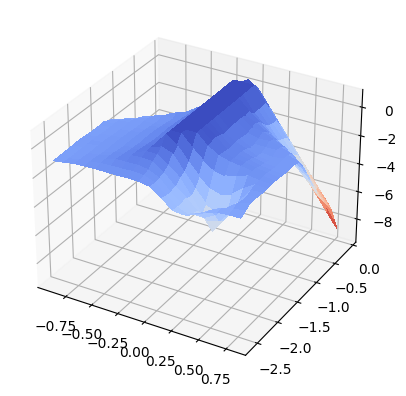

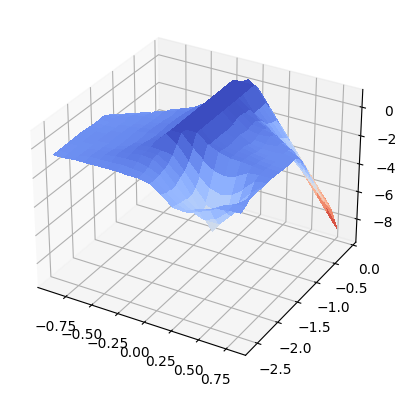

In [273]:
# plot the calibrated value function parallelized version
def calibrate_V_vectorized(env, state, horizon, alphaC_list, alphaR_list, verbose = False):
    n_dim = env.observation_space.shape[0]
    n_init_conds = state.shape[0]
    state_traj = np.zeros((n_init_conds, n_dim, horizon+1))
    state_traj[:,:,0] = state

    # envs = NoResetSyncVectorEnv([make_new_env for _ in range(n_init_conds)])
    envs = NoResetSyncVectorEnv([lambda: make_new_env(args) for _ in range(n_init_conds)])

    for i, init_cond in enumerate(state):
        envs.envs[i].reset(options={"initial_state": init_cond})

    value_list = np.zeros((n_init_conds, horizon))
    constraint_list = np.zeros((n_init_conds, horizon))

    for t in range(horizon):
        current_states = np.array([env.state for env in envs.envs])
        acts = find_a_batch(current_states)
        # modify actions
        actions = np.concatenate((acts[:, :3], np.zeros((n_init_conds, 3))), axis=1)
        states, rew, done, _, info = envs.step(actions)
        state_traj[:, :, t+1] = states
        tmp_constraint = info["constraint"] * (certification_gamma ** t) - alphaC_list[t]
        constraint_list[:, t] = tmp_constraint
        tmp_value = np.minimum(certification_gamma ** t * rew - alphaR_list[t],
                             np.min(constraint_list[:, :t+1], axis=1))
        value_list[:, t] = tmp_value
    empirical_values = np.max(value_list, axis=1)
    time_reach_avoid = np.argmax(value_list, axis=1)
    success_flags = empirical_values > 0
    return empirical_values, time_reach_avoid, success_flags

def calibrate_V_scenario2_vectorized(env, states, horizon, alphaC_list_scenario, alphaR_list_scenario, verbose = False):
    n_dim = env.observation_space.shape[0]
    n_samples = states.shape[0]
    state_traj = np.zeros((n_samples, n_dim, horizon+1))
    state_traj[:,:,0] = states

    # envs = NoResetSyncVectorEnv([make_new_env for _ in range(n_samples)])
    envs = NoResetSyncVectorEnv([lambda: make_new_env(args) for _ in range(n_samples)])

    for i, state in enumerate(states):
        envs.envs[i].reset(options={"initial_state": state})

    value_list = np.zeros((n_samples, horizon))
    constraint_list = np.zeros((n_samples, horizon))

    for t in range(horizon):
        current_states = np.array([env.state for env in envs.envs])
        acts = find_a_batch(current_states)
        # print(f"acts at time {t}: {acts}")
        # modify actions
        actions = np.concatenate((acts[:, :3], np.zeros((n_samples, 3))), axis=1)
        states, rew, done, _, info = envs.step(actions)
        state_traj[:,:,t+1] = states
        tmp_constraint = info["constraint"] * (certification_gamma ** t) - alphaC_list_scenario[t]
        constraint_list[:, t] = tmp_constraint
        tmp_value = np.minimum(certification_gamma ** t * rew - alphaR_list_scenario[t],
                             np.min(constraint_list[:, :t+1], axis=1))
        value_list[:, t] = tmp_value
    empirical_values = np.max(value_list, axis=1)
    time_reach_avoid = np.argmax(value_list, axis=1)
    success_flags = empirical_values > 0
    # print(f"empirical_values: {empirical_values}")
    return empirical_values, time_reach_avoid, success_flags


x = np.arange(-0.9, 0.9, epsilon_x)
y = np.arange(-2.6, 0, epsilon_x)
X, Y = np.meshgrid(x, y)
size_x = len(x)
size_y = len(y)
V_lp_vectorized = np.zeros((X.shape))
V_lp_vectorized_time = np.zeros((X.shape))
V_lp_vectorized_success = np.zeros((X.shape))
V_lp_scenario_updated_vectorized = np.zeros((X.shape))
V_lp_scenario_updated_vectorized_time = np.zeros((X.shape))
V_lp_scenario_updated_vectorized_success = np.zeros((X.shape))

x2 = 0.4
y2 = -1.5
z2 = 0.2
velocity = 0.5
distance = math.sqrt(x2**2 + y2**2 + z2**2)
vx2 = -x2/(distance)*velocity
vy2 = -y2/(distance)*velocity
vz2 = -z2/(distance)*velocity

# start = time()
H, W = X.shape

# tmp_states = np.stack([
#     X,
#     np.full((H, W), ego_vx),
#     Y,
#     np.full((H, W), ego_vy),
#     np.full((H, W), ego_z),
#     np.full((H, W), ego_vz),
#     np.full((H, W), ad_x),
#     np.full((H, W), ad_vx),
#     np.full((H, W), ad_y),
#     np.full((H, W), ad_vy),
#     np.full((H, W), ad_z),
#     np.full((H, W), ad_vz),
# ], axis=-1).reshape(-1, 12)
tmp_states = np.empty((H, W, 12))
tmp_states[:, :, 0] = X
tmp_states[:, :, 1] = ego_vx
tmp_states[:, :, 2] = Y
tmp_states[:, :, 3] = ego_vy
tmp_states[:, :, 4] = ego_z
tmp_states[:, :, 5] = ego_vz
tmp_states[:, :, 6] = ad_x
tmp_states[:, :, 7] = ad_vx
tmp_states[:, :, 8] = ad_y
tmp_states[:, :, 9] = ad_vy
tmp_states[:, :, 10] = ad_z
tmp_states[:, :, 11] = ad_vz
tmp_states = tmp_states.reshape(-1, 12)

# print(f"tmp_states shape: {tmp_states.shape}")

# calibrate V_lp_vectorized
start = time()
V_lp_vectorized_flat, V_lp_vectorized_time_flat, V_lp_vectorized_success_flat = calibrate_V_vectorized(
    env, 
    tmp_states, 
    horizon, 
    alphaC_list, 
    alphaR_list, 
    verbose=False
)
end = time()
print(f"Time taken for vectorized calibration of V_lp: {end - start} seconds")
print(f"V_lp_vectorized_flat shape: {V_lp_vectorized_flat.shape}")

V_lp_vectorized = V_lp_vectorized_flat.reshape(H, W)
V_lp_vectorized_time = V_lp_vectorized_time_flat.reshape(H, W)
V_lp_vectorized_success = V_lp_vectorized_success_flat.reshape(H, W)

# calibrate V_lp_scenario_updated_vectorized
start = time()
V_lp_scenario_updated_vectorized_flat, V_lp_scenario_updated_vectorized_time_flat, V_lp_scenario_updated_vectorized_success_flat = calibrate_V_scenario2_vectorized(
    env, 
    tmp_states, 
    horizon, 
    alphaC_list_scenario3, 
    alphaR_list_scenario3, 
    verbose=False
)
end = time()
print(f"Time taken for vectorized calibration of V_lp_scenario_updated: {end - start} seconds")
print(f"V_lp_scenario_updated_vectorized_flat shape: {V_lp_scenario_updated_vectorized_flat.shape}")

V_lp_scenario_updated_vectorized = V_lp_scenario_updated_vectorized_flat.reshape(H, W)
V_lp_scenario_updated_vectorized_time = V_lp_scenario_updated_vectorized_time_flat.reshape(H, W)
V_lp_scenario_updated_vectorized_success = V_lp_scenario_updated_vectorized_success_flat.reshape(H, W)

# Visualization
fig_vec, ax_vec = plt.subplots(subplot_kw={"projection": "3d"})
fig5_vec, ax5_vec = plt.subplots(subplot_kw={"projection": "3d"})

surf_vec = ax_vec.plot_surface(X, Y, V_lp_vectorized, cmap=cm.coolwarm_r,
                        linewidth=0, antialiased=False)
surf5_vec = ax5_vec.plot_surface(X, Y, V_lp_scenario_updated_vectorized, cmap=cm.coolwarm_r,
                        linewidth=0, antialiased=False)


In [274]:
V_lp = V_lp_vectorized
V_lp_time = V_lp_vectorized_time
V_lp_success = V_lp_vectorized_success

V_lp_scenario_updated = V_lp_scenario_updated_vectorized
V_lp_scenario_updated_time = V_lp_scenario_updated_vectorized_time
V_lp_scenario_updated_success = V_lp_scenario_updated_vectorized_success

Vlp_flipped min: -9.49999974668026, max: 1.0000001192092896


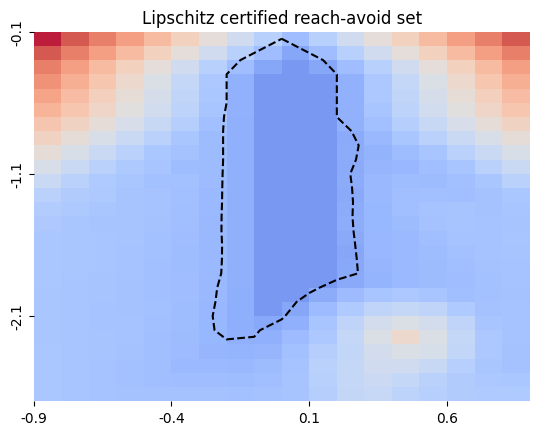

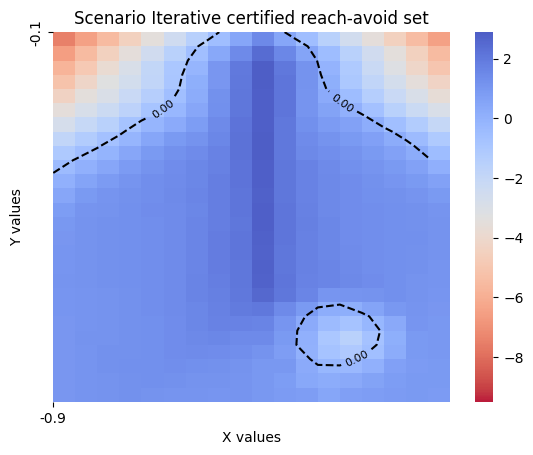

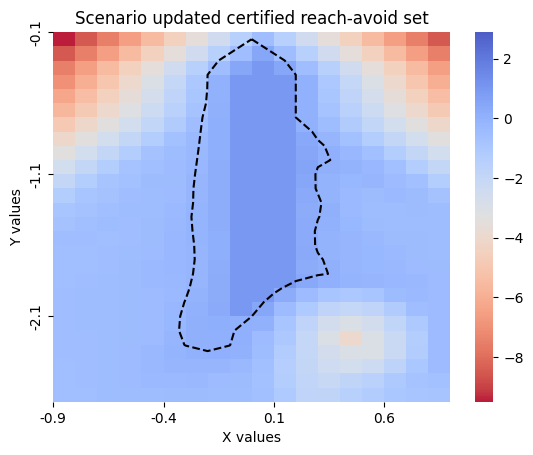

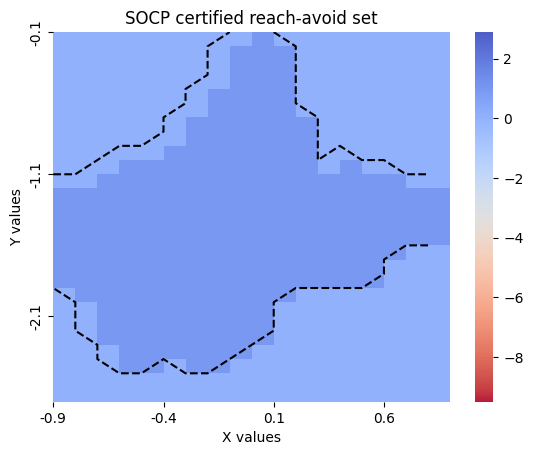

In [275]:
import seaborn as sns

x_interval = 5
y_interval = 10
# x_interval = 30
# y_interval = 60

fig, ax = plt.subplots() #(figsize=(8, 8))
fig2, ax2 = plt.subplots()
fig5, ax5 = plt.subplots()
fig3, ax3 = plt.subplots()
# fig4, ax4 = plt.subplots()

global_min = min(V_lp.min(), V_lp_scenario_updated.min(), V_flipped.min())
global_max = max(V_lp.max(), V_lp_scenario_updated.max(), V_flipped.max())

### 
Vlp_flipped = np.flipud(V_lp)
# Vlp_flipped = V_lp

sns.heatmap(Vlp_flipped, annot=False, cmap=cm.coolwarm_r,alpha = 0.9, ax=ax,cbar=False,
            vmin=global_min,
            vmax=global_max,
            # xticklabels=np.round(x[::x_interval], 2),
            # yticklabels=np.round(y[::-y_interval], 1)
            )
# add colorbar for heatmap 
# cbar = fig.colorbar(cm.ScalarMappable(cmap=cm.coolwarm_r), ax=ax, orientation='vertical')

ax.set_title('Lipschitz certified reach-avoid set')
# ax.set_xlabel('X values')
# ax.set_ylabel('Y values')

x_ticks = np.arange(0, len(x), x_interval)
y_ticks = np.arange(0, len(y), y_interval)
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

ax.set_xticklabels(np.round(x[::x_interval], 2))
ax.set_yticklabels(np.round(y[::-y_interval], 1))
# print(f"X shape: {X.shape}, Y shape: {Y.shape}, V shape: {Vlp_flipped.shape} ")
# contours1 = ax.contour((X+0.9)*50, (Y+2.6)*50, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')
# contours1 = ax.contour((X+0.9)*20, (Y+2.6)*20, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')
contours1 = ax.contour((X+0.9)*10, (Y+2.6)*10, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')
# contours1 = ax.contour((X+0.9)*(1/epsilon_x), (Y+2.6)*(1/epsilon_x), Vlp_flipped, levels=[0], colors='black', linestyles='dashed')
print(f"Vlp_flipped min: {Vlp_flipped.min()}, max: {Vlp_flipped.max()}")
# add colorbar to the plot
# cbar = fig.colorbar(contours1, ax=ax, orientation='vertical')

# change the plot size
# ax.clabel(contours1, inline=True, fontsize=8, fmt="%.2f")
# change the plot size

###
# Vlp_scenario_flipped = np.flipud(V_lp_scenario)
sns.heatmap(V_flipped, annot=False, cmap=cm.coolwarm_r,alpha = 0.9, ax=ax2,cbar=True,
            # xticklabels=np.round(x[::x_interval], 2),
            vmin=global_min,
            vmax=global_max,
            # yticklabels=np.round(y[::-y_interval], 1)
            )
# ax2.set_title('Somil Scenario certified reach-avoid set')
ax2.set_title('Scenario Iterative certified reach-avoid set')
ax2.set_xlabel('X values')
ax2.set_ylabel('Y values')
# x_V = np.arange(-0.9, 0.9, epsilon_x)
# y_V = np.arange(-2.6, 0, epsilon_x)
x_V = np.arange(-0.9, 0.9, 0.1)
y_V = np.arange(-2.6, 0, 0.1)
X_V, Y_V = np.meshgrid(x_V, y_V)
x_V_interval = 30
y_V_interval = 60

x_ticks = np.arange(0, len(x_V), x_V_interval)
y_ticks = np.arange(0, len(y_V), y_V_interval)

ax2.set_xticks(x_ticks)
ax2.set_yticks(y_ticks)
ax2.set_xticklabels(np.round(x_V[::x_V_interval], 2))
ax2.set_yticklabels(np.round(y_V[::-y_V_interval]+0.02, 1))
# contours2 = ax2.contour((X_V+0.9)*50, (Y_V+2.6)*50, V_flipped, levels=[alpha], colors='black', linestyles='dashed')
# contours2 = ax2.contour((X_V+0.9)*20, (Y_V+2.6)*20, V_flipped, levels=[alpha], colors='black', linestyles='dashed')
# contours2 = ax2.contour((X_V+0.9)*10, (Y_V+2.6)*10, V_flipped, levels=[alpha], colors='black', linestyles='dashed')
contours2 = ax2.contour((X_V+0.9)*(1/epsilon_x), (Y_V+2.6)*(1/epsilon_x), V_flipped, levels=[0], colors='black', linestyles='dashed')

ax2.clabel(contours2, inline=True, fontsize=8, fmt="%.2f")

###
Vlp_scenario_updated_flipped = np.flipud(V_lp_scenario_updated)
sns.heatmap(Vlp_scenario_updated_flipped, annot=False, cmap=cm.coolwarm_r,alpha = 0.9, ax=ax5,cbar=True,
            vmin=global_min,
            vmax=global_max,
            # xticklabels=np.round(x[::x_interval], 2),
            # yticklabels=np.round(y[::-y_interval], 1)
            )
ax5.set_title('Scenario updated certified reach-avoid set')
ax5.set_xlabel('X values')
ax5.set_ylabel('Y values')
x_ticks = np.arange(0, len(x), x_interval)
y_ticks = np.arange(0, len(y), y_interval)
ax5.set_xticks(x_ticks)
ax5.set_yticks(y_ticks)
ax5.set_xticklabels(np.round(x[::x_interval], 2))
ax5.set_yticklabels(np.round(y[::-y_interval]+0.02, 1))

# contours5 = ax5.contour((X+0.9)*50, (Y+2.6)*50, Vlp_scenario_updated_flipped, levels=[0], colors='black', linestyles='dashed')
# contours5 = ax5.contour((X+0.9)*20, (Y+2.6)*20, Vlp_scenario_updated_flipped, levels=[0], colors='black', linestyles='dashed')
# contours5 = ax5.contour((X+0.9)*10, (Y+2.6)*10, Vlp_scenario_updated_flipped, levels=[0], colors='black', linestyles='dashed')
contours5 = ax5.contour((X+0.9)*(1/epsilon_x), (Y+2.6)*(1/epsilon_x), Vlp_scenario_updated_flipped, levels=[0], colors='black', linestyles='dashed')

# ax5.clabel(contours5, inline=True, fontsize=8, fmt="%.2f")


###
Vqp_flipped = np.flipud(V_qp)
sns.heatmap(Vqp_flipped, annot=False, cmap=cm.coolwarm_r,alpha = 0.9, ax=ax3,cbar=True,
            vmin=global_min,
            vmax=global_max,
            )
ax3.set_title('SOCP certified reach-avoid set')
ax3.set_xlabel('X values')
ax3.set_ylabel('Y values')
x_qp = np.arange(-0.9, 0.9, 0.1)
y_qp = np.arange(-2.6, 0, 0.1)
# x_qp = np.arange(-0.9, 0.9, epsilon_x)
# y_qp = np.arange(-2.6, 0, epsilon_x)
# x_ticks = np.arange(0, len(x), x_interval)
# y_ticks = np.arange(0, len(y), y_interval)
x_ticks = np.arange(0, len(x_qp), x_interval)
y_ticks = np.arange(0, len(y_qp), y_interval)
ax3.set_xticks(x_ticks)
ax3.set_yticks(y_ticks)
# ax3.set_xticklabels(np.round(x[::x_interval], 2))
# ax3.set_yticklabels(np.round(y[::-y_interval], 1))
ax3.set_xticklabels(np.round(x_qp[::x_interval], 2))
ax3.set_yticklabels(np.round(y_qp[::-y_interval]+0.02, 1))
# print(f"X shape: {X.shape}, Y shape: {Y.shape}, V shape: {Vqp_flipped.shape} ")

X_qp, Y_qp = np.meshgrid(x_qp, y_qp)
# contours3 = ax3.contour((X+0.9)*20, (Y+2.6)*20, Vqp_flipped, levels=[0], colors='black', linestyles='dashed')
# contours3 = ax3.contour((X_qp+0.9)*20, (Y_qp+2.6)*20, Vqp_flipped, levels=[0], colors='black', linestyles='dashed')
contours3 = ax3.contour((X_qp+0.9)*10, (Y_qp+2.6)*10, Vqp_flipped, levels=[0], colors='black', linestyles='dashed')

# ax3.clabel(contours3, inline=True, fontsize=8, fmt="%.2f")

# ###
# # Vlp_scenario_flipped = np.flipud(V_lp_scenario)
# # sns.heatmap(Vlp_scenario_flipped, annot=False, cmap=cm.Greens,alpha = 0.5, ax=ax4,cbar=False,
# #             # xticklabels=np.round(x[::x_interval], 2),
# #             # yticklabels=np.round(y[::-y_interval], 1)
# #             )
# sns.heatmap(Vlp_scenario_updated_flipped, annot=False, cmap=cm.Greens,alpha = 0.5, ax=ax4,cbar=False,
#             # xticklabels=np.round(x[::x_interval], 2),
#             # yticklabels=np.round(y[::-y_interval], 1)
#             )
# sns.heatmap(Vqp_flipped, annot=False, cmap=cm.Reds, alpha = 0.5, ax=ax4,cbar=False,
#             )
# ax4.set_title('SOCP and Scenario certified reach-avoid set')
# ax4.set_xlabel('X values')
# ax4.set_ylabel('Y values')
# x_ticks = np.arange(0, len(x), x_interval)
# y_ticks = np.arange(0, len(y), y_interval)
# ax4.set_xticks(x_ticks)
# ax4.set_yticks(y_ticks)
# ax4.set_xticklabels(np.round(x[::x_interval], 2))
# ax4.set_yticklabels(np.round(y[::-y_interval], 1))
# contours4 = ax4.contour((X+0.9)*100, (Y+2.6)*100, Vqp_flipped, levels=[0], colors='black', linestyles='dashed')
# ax4.clabel(contours4, inline=True, fontsize=8, fmt="%.2f")

plt.show()


Number of contour paths in Lipschitz: 1
Number of contour paths in Lipschitz Scenario: 1
boundary_samples shape: (50, 2)
boundary_samples2 shape: (50, 2)


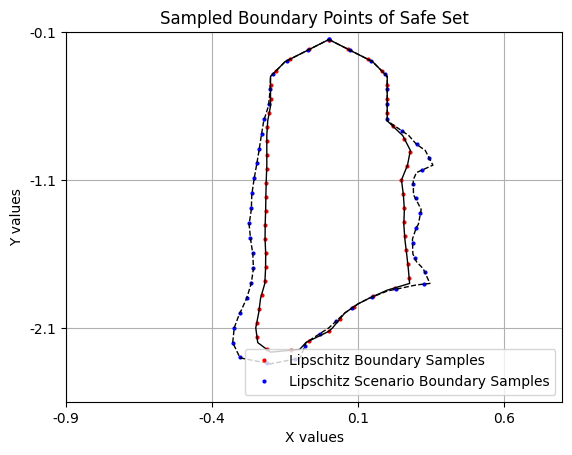

In [276]:
# Sampling on the boundary of the safe set (contour)
def sample_contour(vertices, num_samples):
    diffs = np.diff(vertices, axis=0)
    segment_lengths = np.linalg.norm(diffs, axis=1)
    arc = np.concatenate(([0], np.cumsum(segment_lengths)))
    arc /= arc[-1]

    s = np.linspace(0, 1, num_samples)
    sampled = np.vstack([
        np.interp(s, arc, vertices[:, 0]),
        np.interp(s, arc, vertices[:, 1])
    ]).T
    return sampled




paths = contours1.collections[0].get_paths()
paths2 = contours5.collections[0].get_paths()
print(f"Number of contour paths in Lipschitz: {len(paths)}")
print(f"Number of contour paths in Lipschitz Scenario: {len(paths2)}")
contour_points = [p.vertices for p in paths]
contour_points2 = [p.vertices for p in paths2]

boundary_samples = []
for contour in contour_points:
    samples = sample_contour(contour, num_samples=50)
    boundary_samples.append(samples)

boundary_samples2 = []
for contour in contour_points2:
    samples2 = sample_contour(contour, num_samples=50)
    boundary_samples2.append(samples2)

boundary_samples = np.vstack(boundary_samples)
print(f"boundary_samples shape: {boundary_samples.shape}")

boundary_samples2 = np.vstack(boundary_samples2)
print(f"boundary_samples2 shape: {boundary_samples2.shape}")

# x_boundary = boundary_samples[:, 0] / 10 - 0.9
# y_boundary = boundary_samples[:, 1] / 10 - 2.6
# boundary_samples = np.vstack((x_boundary, y_boundary)).T

# Visualize sampled boundary points
fig_boundary, ax_boundary = plt.subplots()
ax_boundary.invert_yaxis()
ax_boundary.plot(boundary_samples[:, 0], boundary_samples[:, 1], 'ro', markersize=2, label='Lipschitz Boundary Samples')
ax_boundary.plot(boundary_samples2[:, 0], boundary_samples2[:, 1], 'bo', markersize=2, label='Lipschitz Scenario Boundary Samples')
ax_boundary.set_title('Sampled Boundary Points of Safe Set')
ax_boundary.set_xlabel('X values')
ax_boundary.set_ylabel('Y values')
x_ticks = np.arange(0, len(x), x_interval)
y_ticks = np.arange(0, len(y), y_interval)
ax_boundary.set_xticks(x_ticks)
ax_boundary.set_yticks(y_ticks)
ax_boundary.set_xticklabels(np.round(x[::x_interval], 2))
ax_boundary.set_yticklabels(np.round(y[::-y_interval], 1))
# ax_boundary.contourf(
#     (X+0.9)*10, 
#     (Y+2.6)*10, 
#     Vlp_flipped, 
#     levels=[0, V_lp.max()],
#     colors=['tab:blue',],
#     alpha=0.3
# )
ax_boundary.contour(
    (X+0.9)*10, 
    (Y+2.6)*10, 
    Vlp_flipped, 
    levels=[0],
    colors='black',
    linewidths=1
)
ax_boundary.contour(
    (X+0.9)*10, 
    (Y+2.6)*10, 
    Vlp_scenario_updated_flipped, 
    levels=[0],
    colors='black',
    linewidths=1,
    linestyles='dashed'
)

ax_boundary.legend()
#grid on
ax_boundary.grid(True)
plt.show()

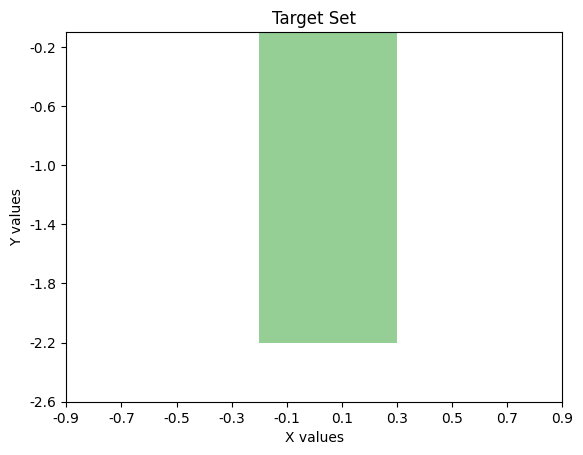

Number of target contour paths: 1


In [277]:
def target_set(X, Y, tmp_point):
    reward = np.zeros(X.shape)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            tmp_point[0], tmp_point[2] = X[i,j], Y[i,j]
            func_scale = 10.0
            reward[i,j] = 1 if (func_scale*min([
                tmp_point[2] - tmp_point[8],
                tmp_point[3] - tmp_point[9],
                (tmp_point[0] - -0.3),
                (0.3 - tmp_point[0]),
                (tmp_point[4] - -0.3),
                (0.3 - tmp_point[4])])) >= 0 else 0
    return reward

x = np.arange(-0.9, 0.9, 0.1)
y = np.arange(-2.6, 0, 0.1)
X, Y = np.meshgrid(x, y)
Z = target_set(X, Y, tmp_point=np.array([0, ego_vx, 0, ego_vy, ego_z, ego_vz,
                                        ad_x, ad_vx, ad_y, ad_vy, ad_z, ad_vz]))
fig_target, ax_target = plt.subplots()
target_contours = ax_target.contourf(X, Y, Z, levels=[1-1e-6, 1], colors=['tab:green'], alpha=0.5)
ax_target.set_title('Target Set')
ax_target.set_xlabel('X values')
ax_target.set_ylabel('Y values')
x_ticks = np.arange(-0.9, 0.91, 0.2)
y_ticks = np.arange(-2.6, 0.1, 0.4)
ax_target.set_xticks(x_ticks)
ax_target.set_yticks(y_ticks)
ax_target.set_xticklabels(np.round(x_ticks, 2))
ax_target.set_yticklabels(np.round(y_ticks, 1))
plt.show()

paths_target = target_contours.collections[0].get_paths()
print(f"Number of target contour paths: {len(paths_target)}")
contour_points_target = [p.vertices for p in paths_target]
target_boundary_samples = []
for contour in contour_points_target:
    samples = sample_contour(contour, num_samples=50)
    target_boundary_samples.append(samples)

# target_boundary_samples = np.vstack(target_boundary_samples)
# print(f"target_boundary_samples shape: {target_boundary_samples.shape}")
# # Visualize sampled target boundary points
# fig_target_boundary, ax_target_boundary = plt.subplots()
# ax_target_boundary.invert_yaxis()
# ax_target_boundary.plot(target_boundary_samples[:, 0], target_boundary_samples[:, 1], 'ro', markersize=2)
# ax_target_boundary.set_title('Sampled Boundary Points of Target Set')
# ax_target_boundary.set_xlabel('X values')
# ax_target_boundary.set_ylabel('Y values')
# x_ticks = np.arange(-0.9, 0.91, 0.2)
# y_ticks = np.arange(-2.6, 0.1, 0.4)
# ax_target_boundary.set_xticks(x_ticks)
# ax_target_boundary.set_yticks(y_ticks)
# ax_target_boundary.set_xticklabels(np.round(x_ticks, 2))
# ax_target_boundary.set_yticklabels(np.round(y_ticks, 1))
plt.show()

In [148]:
# ## observing points safe in one formulation and unsafe in another
# old_method_safe = []
# # old_method_unsafe = []
# new_method_safe = []
# # new_method_unsafe = []


# # x_range = [0.8, 0.9]
# # y_range = [-2.3, -2.0]

# x_range = [-0.7, -0.5]
# y_range = [-2.6, -2.3]

# # old_method_safe = initial_states_scenario[(initial_states_scenario[:, 0] >= x_range[0]) & (initial_states_scenario[:, 0] <= x_range[1]) & (initial_states_scenario[:, 2] >= y_range[0]) & (initial_states_scenario[:, 2] <= y_range[1])]
# # new_method_safe = initial_states_scenario3[(initial_states_scenario3[:, 0] >= x_range[0]) & (initial_states_scenario3[:, 0] <= x_range[1]) & (initial_states_scenario3[:, 2] >= y_range[0]) & (initial_states_scenario3[:, 2] <= y_range[1])]
# # print(f"state_trajs shape: {state_trajs.shape}")
# # print(f"state_trajs3 shape: {state_trajs3.shape}")
# mask_old_method_safe = (state_trajs.squeeze()[:,0,0] >= x_range[0]) & (state_trajs.squeeze()[:,0,0] <= x_range[1]) & (state_trajs.squeeze()[:,2,0] >= y_range[0]) & (state_trajs.squeeze()[:,2,0] <= y_range[1])
# mask_new_method_safe = (state_trajs3.squeeze()[:,0,0] >= x_range[0]) & (state_trajs3.squeeze()[:,0,0] <= x_range[1]) & (state_trajs3.squeeze()[:,2,0] >= y_range[0]) & (state_trajs3.squeeze()[:,2,0] <= y_range[1])
# # old_method_safe = state_trajs[(state_trajs.squeeze()[:,0,0] >= x_range[0]) & (state_trajs.squeeze()[:,0,0] <= x_range[1]) & (state_trajs.squeeze()[:,2,0] >= y_range[0]) & (state_trajs.squeeze()[:,2,0] <= y_range[1]),0,:]
# old_method_safe = state_trajs[mask_old_method_safe,0,:]
# V_lp_scenario_new_safe = np.array(V_lp_scenario_new)[mask_old_method_safe]
# V_lp_scenario_time_new_safe = np.array(V_lp_scenario_time_new)[mask_old_method_safe]
# V_lp_scenario_success_new_safe = np.array(V_lp_scenario_success_new)[mask_old_method_safe]
# # new_method_safe = state_trajs3[(state_trajs3.squeeze()[:,0,0] >= x_range[0]) & (state_trajs3.squeeze()[:,0,0] <= x_range[1]) & (state_trajs3.squeeze()[:,2,0] >= y_range[0]) & (state_trajs3.squeeze()[:,2,0] <= y_range[1]),0,:]
# new_method_safe = state_trajs3[mask_new_method_safe,0,:]
# V_lp_scenario_new2_safe = np.array(V_lp_scenario_new2)[mask_new_method_safe]
# V_lp_scenario_time_new2_safe = np.array(V_lp_scenario_time_new2)[mask_new_method_safe]
# V_lp_scenario_success_new2_safe = np.array(V_lp_scenario_success_new2)[mask_new_method_safe]
# # print(f"old_method_safe shape: {old_method_safe.shape}")
# # print(f"new_method_safe shape: {new_method_safe.shape}")

# # import pdb; pdb.set_trace()








In [130]:
# # note that we need to load epoch = 1600!!!!!!!!
# # plot the target set too!
# import matplotlib.pyplot as plt
# import matplotlib.animation as manimation
# import matplotlib
# from tqdm import tqdm
# FFMpegWriter = manimation.writers['ffmpeg']
# writer = FFMpegWriter(fps=15, metadata=dict(artist='Me'))
# # initial_state = np.array([
# #     0.9, ego_vx, # x, vx
# #     -2.3, ego_vy,
# #     ego_z, ego_vz,
# #     ad_x, ad_vx,
# #     ad_y, ad_vy,
# #     ad_z, ad_vz
# # ])

# # initial_state = np.array([
# #     -0.1, ego_vx, # x, vx
# #     -0.3, ego_vy,
# #     ego_z, ego_vz,
# #     ad_x, ad_vx,
# #     ad_y, ad_vy,
# #     ad_z, ad_vz
# # ])
# # horizon = 300
# # traj,_,rand_disturbance = roll_out_traj(envs, initial_state, horizon, verbose=True)
# num = 0
# traj = old_method_safe[num,:,:]
# traj_time = V_lp_scenario_time_new_safe[num] 
# traj_success = V_lp_scenario_success_new_safe[num]
# print(f"num: {num}")
# print(f"traj shape: {traj.shape}")
# print(f"traj_time: {traj_time}, traj_success: {traj_success}")
# print(f"scenario_radii2 before adjustment: {scenario_radii2}")
# print(f"scenario_radii2_adjusted: {scenario_radii2_adjusted}")
# traj2 = new_method_safe[num,:,:]
# traj2_time = V_lp_scenario_time_new2_safe[num] 
# traj2_success = V_lp_scenario_success_new2_safe[num]
# print(f"traj2 shape: {traj2.shape}")
# print(f"traj2_time: {traj2_time}, traj2_success: {traj2_success}")
# print(f"scenario_radii3 before adjustment: {scenario_radii3}")
# print(f"scenario_radii3_adjusted: {scenario_radii3_adjusted}")
# # traj2,_,rand_disturbance2 = roll_out_traj(envs,
# print(f"traj shape: {traj.shape}")
# print(f"traj2 shape: {traj2.shape}")

# fig, ax = plt.subplots(figsize=(2.2,3))
# fig2, ax2 = plt.subplots(figsize=(2.2,3))
# min_x = -0.6
# max_x = 0.6
# min_y = -2.8
# max_y = -1.4
# alphas = np.linspace(0.1, 1.0, len(traj[0,:]))
# ax.scatter(traj[0,:traj_time+1], traj[2,:traj_time+1],  color = color_list[0], alpha = alphas ) #"o", color="#314cd4",  label = "ego")
# ax.scatter(traj[6,:traj_time+1], traj[8,:traj_time+1],  color = color_list[4], alpha = alphas) #'o', color="#EA3323",label = "adversary"

# for i, (x_rad, y_rad) in enumerate(zip(traj[0,:], traj[2,:])):
#     if i == traj_time - 0:
#         color = 'g'
#     else:
#         color = 'r'
#     circle = Circle((x_rad, y_rad), radius=scenario_radii2_adjusted[i], color=color, fill=True, alpha=0.3)
#     ax.add_patch(circle)
#     if color == 'g':
#         break

# ax2.scatter(traj2[0,:traj2_time+1], traj2[2,:traj2_time+1],  color = color_list[0], alpha = alphas ) #"o", color="#314cd4",  label = "ego")
# ax2.scatter(traj2[6,:traj2_time+1], traj2[8,:traj2_time+1],  color = color_list[4], alpha = alphas) #'o', color="#EA3323",label = "adversary"

# for i, (x_rad, y_rad) in enumerate(zip(traj2[0,:], traj2[2,:])):
#     if i == traj2_time - 0:
#         color1 = 'g'
#     else:
#         color1 = 'r'
#     circle = Circle((x_rad, y_rad), radius=scenario_radii3_adjusted[i], color=color1, fill=True, alpha=0.3)
#     ax2.add_patch(circle)
#     if color1 == 'g':
#         break

# def target_set(env, X, Y, tmp_point = np.array([
#     0, 0.,-1, 0.8,-0.0, 0,0.3,  0,-2.2, 0.3,0., 0
# ])):
#     reward = np.zeros((X.shape))
#     for ii in tqdm(range(reward.shape[0])):
#         for jj in range(reward.shape[1]):
#             tmp_point[0], tmp_point[2] = X[ii,jj], Y[ii,jj]
#             env.reset(initial_state = tmp_point)
#             reward[ii,jj] = 1 if env.step([0,0,0,0,0,0])[1]>=0 else 0
#     return reward

# plt.rcParams["contour.linewidth"]=1.5

# for j in tqdm(range(traj.shape[1])):    
#     # plot the target set
#     # if j == traj.shape[1]-1:
#     # print(f"j: {j}")
#     if j == traj_time - 0:
#         x = np.arange(-0.9, 0.9, 0.005)
#         y = np.arange(-2.6, 0, 0.005)
#         X, Y = np.meshgrid(x, y)
#         reward = target_set(envs, X, Y, traj[:,j])
#         print(f"traj[:,{j}]: {traj[:,j]}")
#         # reward2 = target_set(envs, X, Y, traj2[:,j])
#         ax.contourf(X,Y,reward, levels=[1 - 1e-6, 1],  colors = "#80A8D6", alpha = 0.5, 
#                     label = "target set"
#                     # hatches=['//']
#                     )
#         ax.contour(X,Y,reward, levels=[1 - 1e-6], colors = "#80A8D6", alpha=1, label = "target set")
#         # ax2.contourf(X,Y,reward2, levels=[1 - 1e-6, 1],  colors = "#80A8D6", alpha = 0.5, 
#         #             label = "target set"
#         #             # hatches=['//']
#         #             )
#         # ax2.contour(X,Y,reward2, levels=[1 - 1e-6], colors = "#80A8D6", alpha=1, label = "target set")

#     if j == traj2_time - 0:
#         x = np.arange(-0.9, 0.9, 0.005)
#         y = np.arange(-2.6, 0, 0.005)
#         X, Y = np.meshgrid(x, y)
#         # reward = target_set(envs, X, Y, traj[:,j])
#         reward2 = target_set(envs, X, Y, traj2[:,j])
#         print(f"traj2[:,{j}]: {traj2[:,j]}")
#         # ax.contourf(X,Y,reward, levels=[1 - 1e-6, 1],  colors = "#80A8D6", alpha = 0.5, 
#         #             label = "target set"
#         #             # hatches=['//']
#         #             )
#         # ax.contour(X,Y,reward, levels=[1 - 1e-6], colors = "#80A8D6", alpha=1, label = "target set")
#         ax2.contourf(X,Y,reward2, levels=[1 - 1e-6, 1],  colors = "#80A8D6", alpha = 0.5, 
#                     label = "target set"
#                     # hatches=['//']
#                     )
#         ax2.contour(X,Y,reward2, levels=[1 - 1e-6], colors = "#80A8D6", alpha=1, label = "target set")

#     if j < traj_time+1:
#         ax.add_patch(matplotlib.patches.Circle((traj[6,j], traj[8,j]), 0.2, color='r', fill=True, alpha=0.05))
#     if j < traj2_time+1:
#         ax2.add_patch(matplotlib.patches.Circle((traj2[6,j], traj2[8,j]), 0.2, color='r', fill=True, alpha=0.05))
#     # if j == max(traj_time - 1, traj2_time - 1):
#     #     break
# ax.set_ylim([-2.6, 0])
# ax.set_xlim([-0.95, 0.95])
# ax2.set_ylim([-2.6, 0])
# ax2.set_xlim([-0.95, 0.95])


In [131]:
# gate_width = 0.1

# print(f"traj shape: {traj.shape}, traj_time: {traj_time}")
# print(f"traj2 shape: {traj2.shape}, traj2_time: {traj2_time}")



# traj_end = traj[:, traj_time - 0]
# # traj_end = traj[:, 0]
# traj2_end = traj2[:, traj2_time - 0]
# # traj2_end = traj2[:, 0]
# print(f"traj_end: {traj_end}")
# print(f"traj2_end: {traj2_end}")


# cone1 = np.sqrt((traj_end[0]-traj_end[6])**2 + (traj_end[2]-traj_end[8])**2) - 0.2*(1+max(0, (traj_end[10]-traj_end[4])))
# cstrt2_1 = 1.0 - traj_end[3]
# stay_with_in_left_fence1 = (traj_end[0]+gate_width/2) - traj_end[2]
# stay_with_in_right_fence1 = (-traj_end[0]+gate_width/2) - traj_end[2]
# stay_with_in_upper_fence1 = (-traj_end[2]+gate_width/2) - traj_end[4]
# stay_with_in_lower_fence1 = traj_end[4] - (traj_end[2]-gate_width/2)

# print(f"cone1: {cone1}, cstrt2_1: {cstrt2_1}, stay_with_in_left_fence1: {stay_with_in_left_fence1}, stay_with_in_right_fence1: {stay_with_in_right_fence1}, stay_with_in_upper_fence1: {stay_with_in_upper_fence1}, stay_with_in_lower_fence1: {stay_with_in_lower_fence1}")
# const1_full = 10*min(cone1, cstrt2_1, stay_with_in_left_fence1, stay_with_in_right_fence1, stay_with_in_upper_fence1, stay_with_in_lower_fence1)
# print(f"const1_full: {const1_full}")
# tmp_cstrt1 = const1_full * certification_gamma**(traj_time) - alphaC_list_scenario2[traj_time] 
# print(f"tmp_cstrt1: {tmp_cstrt1}")


# cone2 = np.sqrt((traj2_end[0]-traj2_end[6])**2 + (traj2_end[2]-traj2_end[8])**2) - 0.2*(1+max(0, (traj2_end[10]-traj2_end[4])))
# cstrt2_2 = 1.0 - traj2_end[3]
# stay_with_in_left_fence2 = (traj2_end[0]+gate_width/2) - traj2_end[2]
# stay_with_in_right_fence2 = (-traj2_end[0]+gate_width/2) - traj2_end[2]
# stay_with_in_upper_fence2 = (-traj2_end[2]+gate_width/2) - traj2_end[4]
# stay_with_in_lower_fence2 = traj2_end[4] - (traj2_end[2]-gate_width/2)  
# print(f"cone2: {cone2}, cstrt2_2: {cstrt2_2}, stay_with_in_left_fence2: {stay_with_in_left_fence2}, stay_with_in_right_fence2: {stay_with_in_right_fence2}, stay_with_in_upper_fence2: {stay_with_in_upper_fence2}, stay_with_in_lower_fence2: {stay_with_in_lower_fence2}")
# const2_full = 10*min(cone2, cstrt2_2, stay_with_in_left_fence2, stay_with_in_right_fence2, stay_with_in_upper_fence2, stay_with_in_lower_fence2)
# print(f"const2_full: {const2_full}")
# tmp_cstrt2 = const2_full * certification_gamma**(traj2_time) - alphaC_list_scenario3[traj2_time] 
# print(f"tmp_cstrt2: {tmp_cstrt2}")

# # plt.scatter(traj[0,:traj_time], traj[2,:traj_time], color = color_list[0], label = "ego", s=10)
# # plt.show()
# print(f"x's: {traj[0,:]}")
# print(f"y's: {traj[2,:]}")

# # print(f"traj[:, {traj_time - 3}]: {traj[:,traj_time - 3]}")

# print("-----")
# print(f"x2's: {traj2[0,:]}")
# print(f"y2's: {traj2[2,:]}")

In [132]:
# ## sampling from somil's sets

# # mask = V_flipped > alpha
# mask = V > alpha
# mask2 = V > 0
# # print(f"mask shape: {mask.shape}, V_flipped shape: {V_flipped.shape}")

# # X_points = (X_V + 0.9)*100
# # Y_points = (Y_V + 2.6)*100
# X_points = X_V
# Y_points = Y_V



# # print(f"X_points: {X_points}")
# # print(f"Y_points: {Y_points}")

# # print(f"X_points shape: {X_points.shape}, Y_points shape: {Y_points.shape}, V_flipped shape: {V_flipped.shape}")
# # print(f"X_V: {X_V}")


# inside_x = X_points[mask]
# inside_y = Y_points[mask]

# inside_x2 = X_points[mask2]
# inside_y2 = Y_points[mask2]

# # print(f"Number of points inside certified set: {len(inside_x)}")

# fig10, ax10 = plt.subplots()
# ax10.scatter(inside_x, inside_y, color='blue', s=1, label=f'Inside Certified Set V>alpha={alpha}')
# ax10.set_title(f'Points Inside Certified Reach-Avoid Set V>alpha={alpha}')
# ax10.set_xlabel('X values')
# ax10.set_ylabel('Y values')
# # x_ticks = np.arange(0, len(x), x_interval)
# # y_ticks = np.arange(0, len(y), y_interval)
# # ax10.set_xticks(x_ticks)
# # ax10.set_yticks(y_ticks)
# # ax10.set_xticklabels(np.round(x[::x_interval], 2))
# # ax10.set_yticklabels(np.round(y[::-y_interval], 1))

# # x_V_interval = 30
# # y_V_interval = 60

# # x_ticks = np.arange(0, len(x_V), x_V_interval)
# # y_ticks = np.arange(0, len(y_V), y_V_interval)

# # ax10.set_xticks(x_ticks)
# # ax10.set_yticks(y_ticks)
# # ax10.set_xticklabels(np.round(x_V[::x_V_interval], 2))
# # ax10.set_yticklabels(np.round(y_V[::-y_V_interval]+0.02, 1))

# # ax10.legend()
# plt.show()

# fig11, ax11 = plt.subplots()
# ax11.scatter(inside_x2, inside_y2, color='green', s=1, label='Inside Certified Set V>0')
# ax11.set_title('Points Inside Certified Reach-Avoid Set V>0')
# ax11.set_xlabel('X values')
# ax11.set_ylabel('Y values')

# plt.show()


# ################# Random sampling
# def roll_out_traj(env, state, horizon, verbose = False):
#     n_dim = env.observation_space.shape[0]
#     state_traj = np.zeros((n_dim, horizon+1))
    
#     state_traj[:,0] = state
#     env.reset(initial_state = state)
#     safe_reaching_time = np.inf
#     for t in range(horizon):
#         action = find_a(state_traj[:,t])
#         # rand_disturbance = np.random.uniform(low = -1, high = 1, size = (3,))
#         # action = np.array([action[0], action[1], action[2], rand_disturbance[0], rand_disturbance[1], rand_disturbance[1]])
#         action = np.array([action[0], action[1], action[2], 0, 0, 0])
#         tmp, rew, _, _, info = env.step(action)
        
#         state_traj[:,t+1] = tmp
#         if rew > 0 and t<=horizon-2 and info["constraint"] > 0:
#             if t>1 and verbose:
#                 print("success at time = {}!".format(t))
#             return state_traj[:,:t+1], True #, rand_disturbance

#         if info["constraint"] < 0:
#             print("constraint violated!") if verbose else None
#             return state_traj[:,:t+1], False #, rand_disturbance
#             break
        
#         if state_traj[2,t+1] > 0 or state_traj[8,t+1] > 0:
#             print("A Drone passed frame!") if verbose else None
#             return state_traj[:,:t+1], False #, rand_disturbance
#             break
#     return state_traj, False #, rand_disturbance

# num_random_samples = 10000
# envs2 = gym.make(args.task)

# x_rand = np.random.uniform(X_points.min(), X_points.max(), num_random_samples)
# y_rand = np.random.uniform(Y_points.min(), Y_points.max(), num_random_samples)

# # print(f"x_rand: {x_rand}")
# # print(f"y_rand: {y_rand}")
# from scipy.interpolate import RegularGridInterpolator
# interp = RegularGridInterpolator((X_points[0,:], Y_points[:,0]), V.T)
# vals = interp(np.vstack((x_rand, y_rand)).T)
# # print(f"X_points shape: {X_points.shape}, Y_points shape: {Y_points.shape}, vals shape: {vals.shape}, V shape: {V.shape}")

# # inside_certified = vals > alpha
# inside_certified = vals > 0

# num_actual_samples = np.sum(inside_certified)
# print(f"Number of random samples inside certified set: {num_actual_samples}")

# inside_certified_full_initial = np.zeros((num_actual_samples, 12))
# inside_certified_full_initial[:,0] = x_rand[inside_certified]
# inside_certified_full_initial[:,1] = ego_vx
# inside_certified_full_initial[:,2] = y_rand[inside_certified]
# inside_certified_full_initial[:,3] = ego_vy
# inside_certified_full_initial[:,4] = ego_z
# inside_certified_full_initial[:,5] = ego_vz
# inside_certified_full_initial[:,6] = ad_x
# inside_certified_full_initial[:,7] = ad_vx
# inside_certified_full_initial[:,8] = ad_y
# inside_certified_full_initial[:,9] = ad_vy
# inside_certified_full_initial[:,10] = ad_z
# inside_certified_full_initial[:,11] = ad_vz

# list_of_failed_states = []
# list_of_succeeded_states = []
# num_success = 0

# for init_cond in inside_certified_full_initial:
#     tmp = envs2.reset(initial_state=init_cond)
#     # traj, success, _ = roll_out_traj(envs2, init_cond, horizon, verbose=False)
#     traj, success = roll_out_traj(envs2, init_cond, horizon, verbose=False)
#     if success==True:
#         list_of_succeeded_states.append(init_cond)
#         num_success += 1
#     else:
#         list_of_failed_states.append(init_cond)
#         continue

# empirical_safety_prob = num_success / num_actual_samples
# print(f"Empirical safety probability over {num_actual_samples} samples: {empirical_safety_prob}")







# fig12, ax12 = plt.subplots()
# x_ticks = np.arange(0, len(x_V), x_V_interval)
# y_ticks = np.arange(0, len(y_V), y_V_interval)
# ax12.scatter(x_rand[inside_certified], y_rand[inside_certified], color='red', s=1, label='Inside Certified Set')
# ax12.set_title('Random Samples Inside Certified Reach-Avoid Set')
# ax12.set_xlabel('X values')
# ax12.set_ylabel('Y values')
# # ax12.set_xticks(x_ticks)
# # ax12.set_yticks(y_ticks)
# # ax12.set_xticklabels(np.round(x_V[::x_V_interval], 2))
# # ax12.set_yticklabels(np.round(y_V[::-y_V_interval]+0.02, 1))


# plt.show()

# # plot success states blue and failed states red
# fig13, ax13 = plt.subplots(figsize=(2.2,3))
# ax13.set_ylim([-2.6, 0])
# ax13.set_xlim([-0.95, 0.95])
# for state in list_of_succeeded_states:
#     ax13.scatter(state[0], state[2], color='blue', s=10, alpha=0.6)
# for state in list_of_failed_states:
#     ax13.scatter(state[0], state[2], color='red', s=10, alpha=0.6)

# ax13.set_title('Random Samples: Blue-Success, Red-Fail')
# ax13.set_xlabel('X values')
# ax13.set_ylabel('Y values')
# # ax13.set_xticks(x_ticks)
# # ax13.set_yticks(y_ticks)
# # ax13.set_xticklabels(np.round(x_V[::x_V_interval], 2))
# # ax13.set_yticklabels(np.round(y_V[::-y_V_interval]+0.02, 1))
# plt.show()


/tmp/ipykernel_1738056/2330682604.py:22: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X,Y,binary_Vlp, levels=[1 - 1e-6], colors = color_list[2], label='Lipschitz')


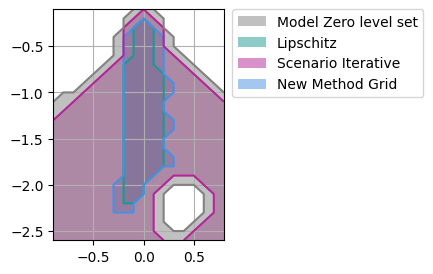

In [144]:
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib.patches import Patch

x = np.arange(-0.9, 0.9, epsilon_x)
y = np.arange(-2.6, 0, epsilon_x)
X, Y = np.meshgrid(x, y)
plt.figure(figsize=(2.2, 3)
        )
binary_V_iterative = np.zeros(V.shape)
binary_V_iterative[V > alpha] = 1
binary_V_model = np.zeros(V.shape)
binary_V_model[V > 0] = 1
binary_Vlp = np.zeros(V_lp.shape)
binary_Vlp[V_lp > 0] = 1
binary_Vqp = np.zeros(V_qp.shape)
binary_Vqp[V_qp > 0] = 1
# binary_Vscenario = np.zeros(V_lp_scenario.shape)
# binary_Vscenario[V_lp_scenario > 0] = 1
binary_Vscenario_updated = np.zeros(V_lp_scenario_updated.shape)
binary_Vscenario_updated[V_lp_scenario_updated > 0] = 1
plt.contour(X,Y,binary_Vlp, levels=[1 - 1e-6], colors = color_list[2], label='Lipschitz')
# plt.contour(X,Y,binary_Vqp, levels=[1 - 1e-6], colors = color_list[0], label='SOCP')
plt.contourf(X,Y,binary_Vlp, levels=[1 - 1e-6, 1], colors = color_list[2], alpha = 0.5, 
        )# colors='red'
# plt.contourf(X,Y,binary_Vqp,levels=[1 - 1e-6, 1], colors = color_list[0],alpha = 0.5, 
        # )

# plt.contour(X,Y,binary_Vscenario, levels=[1 - 1e-6], colors = color_list[3])
# plt.contourf(X,Y,binary_Vscenario, levels=[1 - 1e-6, 1], colors = color_list[3], alpha = 0.5, 
        # )
plt.contour(X,Y,binary_Vscenario_updated, levels=[1 - 1e-6], colors = color_list[8])
plt.contourf(X,Y,binary_Vscenario_updated, levels=[1 - 1e-6, 1], colors = color_list[8], alpha = 0.5, 
        )

plt.contour(X_V,Y_V,binary_V_iterative, levels=[1 - 1e-6], colors = color_list[3])
plt.contourf(X_V,Y_V,binary_V_iterative, levels=[1 - 1e-6, 1], colors = color_list[3], alpha = 0.5,
        )# colors='red'

plt.contour(X_V,Y_V,binary_V_model, levels=[1 - 1e-6], colors = color_list[1])
plt.contourf(X_V,Y_V,binary_V_model, levels=[1 - 1e-6, 1], colors = color_list[1], alpha = 0.5,
        )# colors='red'

# norm = colors.Normalize(vmin=min(V_lp_scenario_new), vmax=max(V_lp_scenario_new))
# cmap = cm.Blues
# for xcoor, ycoor, vlp, vlptime in zip(initial_states_scenario[:, 0], initial_states_scenario[:, 2], V_lp_scenario_new, V_lp_scenario_time_new):
#     if vlp > 0:
#         circle = Circle((xcoor, ycoor), radius=epsilon_x, color=cmap(norm(vlp)), alpha=0.4)
#         # circle = Circle((x, y), radius=0.001, color=cmap(norm(vlp)), alpha=0.99)
#         plt.gca().add_patch(circle)


# norm2 = colors.Normalize(vmin=min(V_lp_scenario_new2), vmax=max(V_lp_scenario_new2))
# cmap2 = cm.Reds
# print(f"initial_states_scenario3 shape: {initial_states_scenario3.shape}")
# for xcoor, ycoor, vlp, vlptime in zip(initial_states_scenario3_new[:, 0], initial_states_scenario3_new[:, 2], V_lp_scenario_new2new2, V_lp_scenario_time_new2new2):
#     if vlp > 0:
#         circle = Circle((xcoor, ycoor), radius=epsilon_x, color=cmap2(norm2(vlp)), alpha=0.7)
#         # circle = Circle((x, y), radius=0.001, color=cmap2(norm2(vlp)), alpha=0.99)
#         plt.gca().add_patch(circle)

legend_elements = [
                Patch(facecolor=color_list[1], alpha=0.5, label="Model Zero level set"),
                Patch(facecolor=color_list[2], alpha=0.5, label="Lipschitz"),
                # Patch(facecolor=color_list[0], alpha=0.5, label="SOCP"),
                Patch(facecolor=color_list[3], alpha=0.5, label="Scenario Iterative"),
                # Patch(facecolor="blue", alpha=0.4, label="Old Method Circles"),
                # Patch(facecolor="red", alpha=0.4, label="New Method Circles"),
                Patch(facecolor=color_list[8], alpha=0.5, label="New Method Grid")      
            ]
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)


plt.grid()


In [45]:
### Monte Carlo of Scenario Iterative Method


In [46]:
#### Local Certification for Boundary Expansion 
import numpy as np
from tqdm import tqdm

def get_boundary_cells(V):
    size_x, size_y = V.shape
    boundary_cells = []
    for ii in range(1, size_x-1):
        for jj in range(1, size_y-1):
            if V[ii, jj] > 0:
                # Check 4-neighbors
                if (V[ii+1, jj] <= 0 or V[ii-1, jj] <= 0 or
                    V[ii, jj+1] <= 0 or V[ii, jj-1] <= 0):
                    boundary_cells.append((ii, jj))
    return boundary_cells

def sample_points_in_ball(center, radius, num_samples=10):
    angles = np.random.uniform(0, 2 * np.pi, num_samples)
    radii = radius * np.sqrt(np.random.uniform(0, 1, num_samples))
    x_samples = center[0] + radii * np.cos(angles)
    y_samples = center[1] + radii * np.sin(angles)
    return list(zip(x_samples, y_samples))

###### 01/13/2026 (Ebonye): Vectorization of calibrate_V_scenario2
def calibrate_V_scenario2_vectorized(env, states, horizon, alphaC_list_scenario, alphaR_list_scenario, verbose = False):
    n_dim = env.observation_space.shape[0]
    n_samples = states.shape[0]
    state_traj = np.zeros((n_samples, n_dim, horizon+1))
    state_traj[:,:,0] = states

    # envs = NoResetSyncVectorEnv([make_new_env for _ in range(n_samples)])
    envs = NoResetSyncVectorEnv([lambda: make_new_env(args) for _ in range(n_samples)])

    for i, state in enumerate(states):
        envs.envs[i].reset(options={"initial_state": state})

    value_list = np.zeros((n_samples, horizon))
    constraint_list = np.zeros((n_samples, horizon))

    for t in range(horizon):
        current_states = np.array([env.state for env in envs.envs])
        acts = find_a_batch(current_states)
        # modify actions
        actions = np.concatenate((acts[:, :3], np.zeros((n_samples, 3))), axis=1)
        states, rew, done, _, info = envs.step(actions)
        state_traj[:,:,t+1] = states
        tmp_constraint = info["constraint"] * (certification_gamma ** t)
        constraint_list[:, t] = tmp_constraint
        tmp_value = np.minimum(certification_gamma ** t * rew,
                             np.min(constraint_list[:, :t+1], axis=1))
        value_list[:, t] = tmp_value
    empirical_values = np.max(value_list, axis=1)
    time_reach_avoid = np.argmax(value_list, axis=1)
    success_flags = empirical_values > 0
    return empirical_values, time_reach_avoid, success_flags

def calibrate_V_scenario2(env, state, horizon, alphaC_list_scenario, alphaR_list_scenario, verbose = False):
    ### sampling requires incorporating noise. how to incorporate noise here?
    n_dim = env.observation_space.shape[0]
    state_traj = np.zeros((n_dim, horizon+1))
    state_traj[:,0] = state
    env.reset(initial_state = state)
    
    # gamma = args.gamma
    value_list = np.array([])
    constraint_list = np.array([])
    # time_reach_avoid = 0
    # print(f"horizon: {horizon}")
    for t in range(horizon):
        action = find_a(state_traj[:,t])
        # modify action
        action = np.array([action[0], action[1], action[2], 0, 0, 0])
        # noise = np.random.uniform(-epsilon_d, epsilon_d, size=3)  #
        # noise = np.concatenate((np.zeros(3), noise))  # Add zeros for the control inputs
        # action = np.array(action) + noise
        tmp, rew, _, _, info = env.step(action)
        state_traj[:,t+1] = tmp
        
        # import pdb; pdb.set_trace()
        # print(f"t: {t}")
        tmp_constraint = info["constraint"]*certification_gamma**t #- alphaC_list_scenario[t]
        # constraint_list = np.append(constraint_list, tmp_constraint)
        # if tmp_constraint < 0:
        #     # time_reach_avoid = horizon + 1
        #     time_reach_avoid = t 
        #     # time_reach_avoid = np.nan
        #     return -1e-3, time_reach_avoid, False
        constraint_list = np.append(constraint_list, tmp_constraint)
        tmp_value = np.min([ certification_gamma**t * rew, #- alphaR_list_scenario[t], 
                            np.min(constraint_list) ]) # TODO: program the empirical value function
        # if tmp_value > 0:
        #     time_reach_avoid = t
        #     return 1, time_reach_avoid, True
        value_list = np.append(value_list, tmp_value)
        
    empirical_value = max(value_list)
    # empirical_value = 0 if empirical_value < 0 else 1
    # time_reach_avoid = horizon + 1 if empirical_value < 0 else horizon
    # time_reach_avoid = np.nan if empirical_value < 0 else horizon
    time_reach_avoid = np.argmax(value_list) # if empirical_value > 0 else horizon 
    
    # return empirical_value, time_reach_avoid, constraint_list
    return empirical_value, time_reach_avoid, empirical_value > 0


def max_radius_growth_vectorized_worst(seed_ii, seed_jj, X, Y, env, horizon, alphaC_list, alphaR_list,
                      V_lp_scenario_updated, max_attept_radius = 0.5, N_samples = 20, tol=1e-2, max_iters = 10, verbose=False):
    
    # center_x = X[seed_ii, seed_jj]
    # center_y = Y[seed_ii, seed_jj]

    center_x = seed_ii
    center_y = seed_jj

    # r_min = 0.0
    # r_max = max_attept_radius
    rad = max_attept_radius
    rad_prev = 0.0
    iters = 0
    # while r_max - r_min > tol:
    points_dict = {}
    while iters < max_iters:
        iters += 1
        if verbose:
            print(f"Iteration {iters}")
        # r_candidate = (r_min + r_max) / 2.0
        points = sample_points_in_ball((center_x, center_y), rad, num_samples=N_samples)
        points_dict[iters] = points
        points_array = np.array(points)
        initial_states = np.zeros((N_samples, 12))
        initial_states[:, 0] = points_array[:, 0]
        initial_states[:, 1] = ego_vx
        initial_states[:, 2] = points_array[:, 1]
        initial_states[:, 3] = ego_vy
        initial_states[:, 4] = ego_z
        initial_states[:, 5] = ego_vz
        initial_states[:, 6] = ad_x
        initial_states[:, 7] = ad_vx
        initial_states[:, 8] = ad_y
        initial_states[:, 9] = ad_vy
        initial_states[:, 10] = ad_z
        initial_states[:, 11] = ad_vz

        V_vals, _, _ = calibrate_V_scenario2_vectorized(env, initial_states, horizon, alphaC_list, alphaR_list)

        violations = V_vals <= 0
        if not np.any(violations):
            if verbose:
                print(f"Iteration {iters}: radius={rad}, all points safe.")
                return rad, points_dict
        else:
            # # Shrink radius to the largest distance of non-violating points
            # safe_points = points_array[~violations]
            # if safe_points.shape[0] == 0:
            #     if verbose:
            #         print(f"Iteration {iters}: radius={rad}, no safe points found.")
            #     return 0.0
            
            # dists = np.linalg.norm(safe_points - np.array([center_x, center_y]), axis=1)
            # rad_new = dists.max()
            # if verbose:
            #     print(f"Iteration {iters}: radius={rad}, reducing to {rad_new} based on safe points.")
            # rad = rad_new
            
            # Shrink radius to the maximum distance of violating points
            violating_points = points_array[violations]
            if violating_points.shape[0] == 0:
                if verbose:
                    print(f"Iteration {iters}: radius={rad}, no violating points found.")
                if rad - rad_prev < tol:
                    return rad, points_dict
                rad_prev = rad

            dists = np.linalg.norm(violating_points - np.array([center_x, center_y]), axis=1)
            rad_new = dists.min()
            if verbose:
                print(f"Iteration {iters}: radius={rad}, reducing to {rad_new} based on violating points.")
            if abs(rad - rad_new) < tol:
                return rad_new, points_dict
            rad = rad_new
            
    return rad, points_dict




def max_radius_growth_vectorized(seed_ii, seed_jj, X, Y, env, horizon, alphaC_list, alphaR_list,
                      V_lp_scenario_updated, max_attept_radius = 0.5, N_samples = 20, tol=1e-2, verbose=False):
    
    # center_x = X[seed_ii, seed_jj]
    # center_y = Y[seed_ii, seed_jj]

    center_x = seed_ii
    center_y = seed_jj

    r_min = 0.0
    r_max = max_attept_radius

    iters = 0
    while r_max - r_min > tol:
        iters += 1
        if verbose:
            print(f"Iteration {iters}")
        r_candidate = (r_min + r_max) / 2.0
        points = sample_points_in_ball((center_x, center_y), r_candidate, num_samples=N_samples)
        points_array = np.array(points)
        initial_states = np.zeros((N_samples, 12))
        initial_states[:, 0] = points_array[:, 0]
        initial_states[:, 1] = ego_vx
        initial_states[:, 2] = points_array[:, 1]
        initial_states[:, 3] = ego_vy
        initial_states[:, 4] = ego_z
        initial_states[:, 5] = ego_vz
        initial_states[:, 6] = ad_x
        initial_states[:, 7] = ad_vx
        initial_states[:, 8] = ad_y
        initial_states[:, 9] = ad_vy
        initial_states[:, 10] = ad_z
        initial_states[:, 11] = ad_vz

        V_vals, _, _ = calibrate_V_scenario2_vectorized(env, initial_states, horizon, alphaC_list, alphaR_list)

        if np.all(V_vals > 0):
            r_min = r_candidate
        else:
            r_max = r_candidate
    return r_min


def max_radius_growth(seed_ii, seed_jj, X, Y, env, horizon, alphaC_list, alphaR_list,
                      V_lp_scenario_updated, max_attept_radius = 0.5, N_samples = 20, tol=1e-2):
    center_x = X[seed_ii, seed_jj]
    center_y = Y[seed_ii, seed_jj]

    r_min = 0.0
    r_max = max_attept_radius

    while r_max - r_min > tol:
        r_candidate = (r_min + r_max) / 2.0
        points = sample_points_in_ball((center_x, center_y), r_candidate, num_samples=N_samples)
        safe = True
        for (x_pt, y_pt) in points:
            initial_state = np.array([
                x_pt, ego_vx,  # x, vx
                y_pt, ego_vy,
                ego_z, ego_vz,
                ad_x, ad_vx,
                ad_y, ad_vy,
                ad_z, ad_vz
            ])
            V_val, _, _ = calibrate_V_scenario2(env, initial_state, horizon, alphaC_list, alphaR_list)

            if V_val <= 0:
                safe = False
                break
        if safe:
            r_min = r_candidate
        else:
            r_max = r_candidate
    return r_min

def grow_regions(V_lp_scenario_updated, X, Y, env, horizon, alphaC_list, alphaR_list,
                 max_attept_radius = 0.5, N_samples = 20, tol=1e-2):
    safe_regions = []
    # boundary_cells = get_boundary_cells(V_lp_scenario_updated)

    ### use contours1 to get boundary cells
    # contours1 = plt.contour((X+0.9)*10, (Y+2.6)*10, Vlp_flipped, levels=[0], linewidths=1)
    # contours1 = plt.contour((X), (Y), V_lp, levels=[0], linewidths=1)
    contours1 = plt.contour(X, Y, V_lp_scenario_updated, levels=[0], linewidths=1)
    
    paths = contours1.collections[0].get_paths()
    contour_points = [p.vertices for p in paths]

    boundary_cells = []
    for contour in contour_points:
        samples = sample_contour(contour, num_samples=50)
        boundary_cells.extend(samples)

    # print(f"Number of boundary cells to process: {len(boundary_cells)}")
    boundary_cells = np.vstack(boundary_cells)
    # print(f"X shape: {X.shape}, Y shape: {Y.shape}, boundary_cells shape: {boundary_cells.shape}")
    # print(f"shape of boundary_cells: {boundary_cells.shape}")

    # import pdb; pdb.set_trace()

    # boundary_cells = boundary_cells[::1]
    # print(f"Number of boundary cells to process: {len(boundary_cells)}")
    # print(f"length of alphaC_list: {len(alphaC_list)}, length of alphaR_list: {len(alphaR_list)}")
    for seed_ii, seed_jj in tqdm(boundary_cells):
        # print(f"Processing boundary cell: ({seed_ii}, {seed_jj})")
        # if i % 6 == 0:
        # r_safe = max_radius_growth(seed_ii, seed_jj, X, Y, env, horizon, 
        #                            alphaC_list, alphaR_list,
        #                           V_lp_scenario_updated,
        #                            max_attept_radius, N_samples, tol)
        r_safe, points_dict = max_radius_growth_vectorized_worst(seed_ii, seed_jj, X, Y, env, horizon,
                                   alphaC_list, alphaR_list,
                                  V_lp_scenario_updated,
                                   max_attept_radius, N_samples, tol)
        # safe_regions.append((X[seed_ii, seed_jj], Y[seed_ii, seed_jj], r_safe))
        safe_regions.append((seed_ii, seed_jj, r_safe))
    return safe_regions, boundary_cells


# def grow_regions_binary_grid(V_lp_scenario_updated, X, Y, env, horizon, alphaC_list, alphaR_list,
#                              max_attept_radius = 0.5, N_samples = 20, tol=1e-2):
#     binary_grid = np.zeros_like(V_lp_scenario_updated)
#     binary_grid[V_lp_scenario_updated > 0] = 1

#     boundary_cells = get_boundary_cells(V_lp_scenario_updated)
#     print(f"Number of boundary cells to process: {len(boundary_cells)}")

#     for (seed_ii, seed_jj) in tqdm(boundary_cells):
#         r_safe = max_radius_growth(seed_ii, seed_jj, X, Y, env, horizon, 
#                                    alphaC_list, alphaR_list,
#                                   V_lp_scenario_updated,
#                                    max_attept_radius, N_samples, tol)
#         # print(f"Expanding at cell ({seed_ii}, {seed_jj}) with radius {r_safe}")
#         # print(f"X[1, 0] - X[0,0]: {X[1,0] - X[0,0]}, Y[0,1] - Y[0,0]: {Y[0,1] - Y[0,0]}")
#         # print(f"r_safe: {r_safe}")
#         if r_safe <= 0:
#             continue
        
#         # print(f"Expanding at cell ({seed_ii}, {seed_jj}) with radius {r_safe}")
#         i_min = max(seed_ii - int(r_safe / (X[0,1] - X[0,0])) - 1, 0)
#         i_max = min(seed_ii + int(r_safe / (X[0,1] - X[0,0])) + 1, binary_grid.shape[0])
#         j_min = max(seed_jj - int(r_safe / (Y[1,0] - Y[0,0])) - 1, 0)
#         j_max = min(seed_jj + int(r_safe / (Y[1,0] - Y[0,0])) + 1, binary_grid.shape[1])

#         for ii in range(i_min, i_max):
#             for jj in range(j_min, j_max):
#                 dist = np.sqrt((X[ii, jj] - X[seed_ii, seed_jj])**2 + (Y[ii, jj] - Y[seed_ii, seed_jj])**2)
#                 if dist <= r_safe:
#                     binary_grid[ii, jj] = 1
#     return binary_grid
        
# def plot_safe_regions(X, Y, V_lp_scenario_updated, safe_regions):
#     fig, ax = plt.subplots(figsize=(8, 6))

def plot_binary_contour(X, Y, binary_grid):
    plt.figure(figsize=(8, 6))
    x = np.arange(-0.9, 0.9, epsilon_x)
    y = np.arange(-2.6, 0, epsilon_x)
    X_coarse, Y_coarse = np.meshgrid(x, y)
    original_grid = np.zeros_like(V_lp_scenario_updated)
    original_grid[V_lp_scenario_updated>0] = 1
    plt.contourf(X_coarse, Y_coarse, binary_grid, levels=[1-1e-6, 1], colors=color_list[5], alpha=0.5)
    plt.contourf(X_coarse, Y_coarse, original_grid, levels=[1-1e-6, 1], colors=color_list[6], alpha=0.5)
    plt.contour(X_coarse, Y_coarse, binary_grid, levels=[1-1e-6], colors=color_list[5])
    plt.contour(X_coarse, Y_coarse, original_grid, levels=[1-1e-6], colors=color_list[6])
    plt.title('Expanded Safe Regions')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid()
    plt.show()

# def visualize_with_circles(safe_regions):
#     plt.figure(figsize=(8,6))
#     x = np.arange(-0.9, 0.9, epsilon_x)
#     y = np.arange(-2.6, 0, epsilon_x)
#     X_coarse, Y_coarse = np.meshgrid(x, y)
#     binary_grid = np.zeros_like(V_lp_scenario_updated)
#     binary_grid[V_lp_scenario_updated>0]=1
#     plt.contourf(X_coarse, Y_coarse, binary_grid, levels=[1-1e-6, 1], colors=color_list[5], alpha=0.5)
#     plt.contour(X_coarse, Y_coarse, binary_grid, levels=[1-1e-6], colors=color_list[5])
    
#     ax = plt.gca()
#     for x_center, y_center, r in safe_regions:
#         circle = plt.Circle((x_center, y_center), r, color=color_list[6], alpha=alpha)
#         ax.add_patch(circle)
    
#     plt.xlabel('x')
#     plt.ylabel('y')
#     plt.title('Coarse set + grown circles')
#     plt.gca().set_aspect('equal')
#     plt.xticks(np.arange(-0.9, 0.9, epsilon_x))
#     plt.yticks(np.arange(-2.6, 0, epsilon_x))
#     plt.grid()
#     plt.show()

# def plot_original_contour():
#     original_grid = np.zeros_like(V_lp_scenario_updated)
#     original_grid[V_lp_scenario_updated>0] = 1
#     x = np.arange(-0.9, 0.9, epsilon_x)
#     y = np.arange(-2.6, 0, epsilon_x)
#     X_coarse, Y_coarse = np.meshgrid(x, y)
#     plt.contourf(X_coarse, Y_coarse, original_grid)


    
# boundary_cells = get_boundary_cells(V_lp_scenario_updated)
# print(f"Number of boundary cells: {len(boundary_cells)}")

# example usage
# print(f"length of alphaC_list_scenario3: {len(alphaC_list_scenario3)}, length of alphaR_list_scenario3: {len(alphaR_list_scenario3)}")
# print(f"length of alphaC_list: {len(alphaC_list)}, length of alphaR_list: {len(alphaR_list)}")



# binary_grid = grow_regions_binary_grid(V_lp_scenario_updated, X, Y, envs, horizon, 
#                                         alphaC_list_scenario3, alphaR_list_scenario3,
#                                         max_attept_radius = 1.0, N_samples = 50, tol=1e-2)

# boundary_cells = get_boundary_cells(V_lp_scenario_updated)
# binary_grid_initial = np.zeros_like(V_lp_scenario_updated)
# for (ii, jj) in boundary_cells:
#     binary_grid_initial[ii, jj] = 1

# plt.figure(figsize=(8, 6))
# x = np.arange(-0.9, 0.9, epsilon_x)
# y = np.arange(-2.6, 0, epsilon_x)
# X, Y = np.meshgrid(x, y)
# plt.contourf(X, Y, binary_grid_initial, levels=[1 - 1e-6, 1], colors=color_list[7], alpha=0.5)
# plt.contour(X, Y, binary_grid_initial, levels=[1 - 1e-6], colors=color_list[7])
# plt.title('Initial Boundary Cells')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.gca().set_aspect('equal', adjustable='box')
# plt.grid()
# plt.show()



# plot_binary_contour(X, Y, binary_grid)
# visualize_with_circles(safe_regions)


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:05<00:00,  1.32s/it]


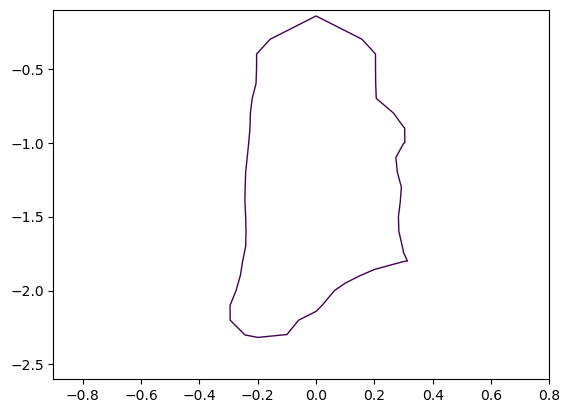

In [47]:
horizon = 30
x = np.arange(-0.9, 0.9, epsilon_x)
y = np.arange(-2.6, 0, epsilon_x)
X, Y = np.meshgrid(x, y)
safe_regions, boundary_cells = grow_regions(V_lp_scenario_updated, X, Y, envs, horizon, 
                            alphaC_list_scenario3, alphaR_list_scenario3,
                            max_attept_radius = 1.0, N_samples = 20, tol=1e-3)



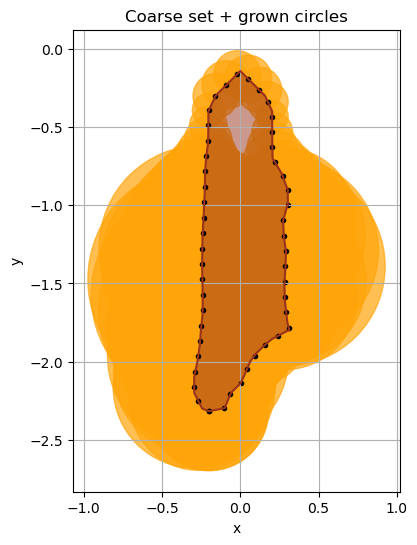

In [48]:
def visualize_with_circles(safe_regions, boundary_cells, point=None):
    plt.figure(figsize=(8,6))
    x = np.arange(-0.9, 0.9, epsilon_x)
    y = np.arange(-2.6, 0, epsilon_x)
    X_coarse, Y_coarse = np.meshgrid(x, y)
    # binary_grid = np.zeros_like(V_lp_scenario_updated)
    # binary_grid[V_lp_scenario_updated>0]=1
    # plt.contourf(X_coarse, Y_coarse, binary_grid, levels=[1-1e-6, 1], colors=color_list[5], alpha=0.5)
    # plt.contour(X_coarse, Y_coarse, binary_grid, levels=[1-1e-6], colors=color_list[5])
    
    ax = plt.gca()
    for x_center, y_center, r in safe_regions:
        circle = plt.Circle((x_center, y_center), r, color=color_list[6], alpha=alpha)
        ax.add_patch(circle)
    ax.contourf(
        (X_coarse)*1,
        (Y_coarse)*1,
        # V_lp,
        # levels=[0, V_lp.max()],
        V_lp_scenario_updated,
        levels=[0, V_lp_scenario_updated.max()],
        colors=color_list[5],
        alpha=0.5,
    )
    ax.contour(
        (X_coarse)*1,
        (Y_coarse)*1,
        # V_lp,
        V_lp_scenario_updated,
        levels=[0],
        colors=color_list[5],
    )
    # boundary_cells = get_boundary_cells(V_lp_scenario_updated)
    for i, (ii, jj) in enumerate(boundary_cells):
        # if i % 6 == 0:
        # plt.scatter(X_coarse[ii, jj], Y_coarse[ii, jj], color='black', s=9)
        plt.scatter(ii, jj, color='black', s=9)
    if point is not None:
        plt.scatter(point[0], point[1], color='red', s=50, marker='x', label='Test Point')
        plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Coarse set + grown circles')
    plt.gca().set_aspect('equal')
    # plt.xticks(np.arange(-0.9, 0.9, epsilon_x), rotation=90)
    # plt.yticks(np.arange(-2.6, 0, epsilon_x))
    x_ticks = np.arange(0, len(x), x_interval)
    y_ticks = np.arange(0, len(y), y_interval)
    # plt.xticks(x_ticks, np.round(x[::x_interval], 2), rotation=90)
    # plt.yticks(y_ticks, np.round(y[::-y_interval], 1))
    plt.grid()
    plt.show()


# boundary_cells = get_boundary_cells(V_lp_scenario_updated)
# binary_grid_initial = np.zeros_like(V_lp_scenario_updated)
# for (ii, jj) in boundary_cells:
#     binary_grid_initial[ii, jj] = 1

# plt.figure(figsize=(8, 6))
# x = np.arange(-0.9, 0.9, epsilon_x)
# y = np.arange(-2.6, 0, epsilon_x)
# X, Y = np.meshgrid(x, y)
# # plt.contourf(X, Y, binary_grid_initial, levels=[1 - 1e-6, 1], colors=color_list[7], alpha=0.5)
# # plt.contour(X, Y, binary_grid_initial, levels=[1 - 1e-6], colors=color_list[7])
# # binary_grid = np.zeros_like(V_lp_scenario_updated)
# # binary_grid[V_lp_scenario_updated>0]=1
# # plt.contourf(X, Y, binary_grid, levels=[1-1e-6, 1], colors=color_list[5], alpha=0.5)
# # plt.contour(X, Y, binary_grid, levels=[1-1e-6], colors=color_list[5])

# plt.contourf(
#     (X+0.9)*10,
#     (Y+2.6)*10,
#     Vlp_flipped,
#     levels=[0, V_lp.max()],
#     colors=color_list[5],
#     alpha=0.3,
# )
# plt.contour(
#     (X+0.9)*10,
#     (Y+2.6)*10,
#     Vlp_flipped,
#     levels=[0],
#     colors=color_list[5],
# )
# for i, (ii, jj) in enumerate(boundary_cells):
#     # if i % 6 == 0:
#     # plt.scatter(X[ii, jj], Y[ii, jj], color='black', s=9)
#     plt.scatter(ii, jj, color='black', s=9)

# plt.title('Initial Boundary Cells')
# plt.xlabel('X')
# plt.xticks(np.arange(-0.9, 0.9, epsilon_x), rotation=90)
# plt.ylabel('Y')
# plt.yticks(np.arange(-2.6, 0, epsilon_x))
# plt.gca().set_aspect('equal', adjustable='box')
# plt.grid()
# plt.show()



visualize_with_circles(safe_regions, boundary_cells)

In [49]:
# # fig_overlay, ax_overlay = plt.subplots()
# # Vqp_flipped = np.flipud(V_qp)
# # sns.heatmap(Vqp_flipped, annot=False, cmap=cm.coolwarm_r,alpha = 0.9, ax=ax_overlay,cbar=True,
# #             vmin=V_qp.min(),
# #             vmax=V_qp.max(),
# #             )
# # ax_overlay.set_title('SOCP certified reach-avoid set')
# # ax_overlay.set_xlabel('X values')
# # ax_overlay.set_ylabel('Y values')
# # x_qp = np.arange(-0.9, 0.9, 0.05)
# # y_qp = np.arange(-2.6, 0, 0.05)
# # # x_ticks = np.arange(0, len(x), x_interval)
# # # y_ticks = np.arange(0, len(y), y_interval)
# # x_ticks = np.arange(0, len(x_qp), x_interval)
# # y_ticks = np.arange(0, len(y_qp), y_interval)
# # ax_overlay.set_xticks(x_ticks)
# # ax_overlay.set_yticks(y_ticks)
# # # ax_overlay.set_xticklabels(np.round(x[::x_interval], 2))
# # # ax_overlay.set_yticklabels(np.round(y[::-y_interval], 1))
# # ax_overlay.set_xticklabels(np.round(x_qp[::x_interval], 2))
# # ax_overlay.set_yticklabels(np.round(y_qp[::-y_interval]+0.02, 1))
# # plt.show()




# def visualize_all_in_one(
#         V_lp_scenario_updated,
#         V_qp,
#         safe_regions,
#         boundary_cells,
#         epsilon_x,
#         alpha=0.3,
#         point=None,
#     ):
#     fig, ax = plt.subplots(figsize=(8, 6))
#     x = np.arange(-0.9, 0.9, epsilon_x)
#     y = np.arange(-2.6, 0, epsilon_x)
#     X_coarse, Y_coarse = np.meshgrid(x, y)

#     # Plot SOCP heatmap
#     # Vqp_flipped = np.flipud(V_qp)
#     Vqp_flipped = V_qp
#     im = ax.imshow(
#         Vqp_flipped,
#         extent=[x.min(), x.max(), y.min(), y.max()],
#         origin='lower',
#         cmap=cm.coolwarm_r,
#         alpha=0.9,
#         vmin=V_qp.min(),
#         vmax=V_qp.max(),
#         aspect='auto'
#     )
#     cbar = plt.colorbar(im, ax=ax)
#     cbar.set_label('SOCP Value Function')

#     # LP Scenario safe set
#     # binary_grid = np.zeros_like(V_lp_scenario_updated)
#     # binary_grid[V_lp_scenario_updated > 0] = 1

#     # ax.contourf(
#     #     X_coarse,
#     #     Y_coarse,
#     #     binary_grid,
#     #     levels=[1 - 1e-6, 1],
#     #     colors=color_list[5],
#     #     alpha=0.5
#     # )
#     # ax.contour(
#     #     X_coarse,
#     #     Y_coarse,
#     #     binary_grid,
#     #     levels=[1 - 1e-6],
#     #     colors=color_list[5]
#     # )
#     ax.contourf(
#         (X_coarse)*1,
#         (Y_coarse)*1,
#         # V_lp,
#         # levels=[0, V_lp.max()],
#         V_lp_scenario_updated,
#         levels=[0, V_lp_scenario_updated.max()],
#         colors=color_list[5],
#         alpha=0.5,
#     )
#     ax.contour(
#         (X_coarse)*1,
#         (Y_coarse)*1,
#         # V_lp,
#         V_lp_scenario_updated,
#         levels=[0],
#         colors=color_list[5],
#     )

#     # Boundary cells
#     for ii, jj in boundary_cells:
#         # ax.scatter(X_coarse[ii, jj], Y_coarse[ii, jj], color='black', s=9)
#         ax.scatter(ii, jj, color='black', s=9)
    
#     # Grown safe regions
#     for x_center, y_center, r in safe_regions:
#         circle = plt.Circle((x_center, y_center), r, color=color_list[6], alpha=alpha)
#         ax.add_patch(circle)

#     if point is not None:
#         ax.scatter(point[0], point[1], color='red', s=50, marker='x', label='Test Point')
#         ax.legend()
    
#     # Formatting
#     ax.set_xlabel('X')
#     ax.set_ylabel('Y')
#     ax.set_title('Combined Visualization')
#     ax.set_aspect('equal', adjustable='box')
#     ax.set_xticks(np.arange(-0.9, 0.9, epsilon_x))
#     ax.tick_params(axis='x', rotation=90)
#     ax.set_yticks(np.arange(-2.6, 0, epsilon_x))
#     ax.grid()

#     plt.tight_layout()
#     plt.show()


# visualize_all_in_one(
#     V_lp_scenario_updated,
#     V_qp,
#     safe_regions,
#     boundary_cells,
#     epsilon_x,
#     alpha=0.1
#     )





In [50]:
# # Monte Carlo Study of Growth Circles
# def sample_union_of_circles(safe_regions, num_samples):
#     centers = np.array([[x, y] for x, y, r in safe_regions])
#     radii = np.array([r for x, y, r in safe_regions])

#     # Bounding box for sampling
#     xmin = np.min(centers[:, 0] - radii)
#     xmax = np.max(centers[:, 0] + radii)
#     ymin = np.min(centers[:, 1] - radii)
#     ymax = np.max(centers[:, 1] + radii)
#     # print(f"Sampling bounding box: x[{xmin}, {xmax}], y[{ymin}, {ymax}]")

#     samples = []
#     # all_pts = []
#     batch = max(1000, num_samples)

#     while len(samples) < num_samples:
#         pts = np.random.uniform(
#             low=[xmin, ymin],
#             high=[xmax, ymax],
#             size=(batch, 2)
#         )

#         # check membership in union
#         inside = np.zeros(batch, dtype=bool)
#         for (cx, cy, r) in safe_regions:
#             dists = np.sqrt((pts[:, 0] - cx) ** 2 + (pts[:, 1] - cy) ** 2)
#             inside |= (dists <= r)

#         samples.extend(pts[inside])
#         # all_pts.extend(pts)

#     return np.array(samples[:num_samples])#, np.array(all_pts)




# mc_samples = sample_union_of_circles(safe_regions, 5000)

# # # Visualize sampled points
# # plt.figure(figsize=(8, 6))
# # x = np.arange(-0.9, 0.9, epsilon_x)
# # y = np.arange(-2.6, 0, epsilon_x)

# # plt.scatter(mc_samples[:, 0], mc_samples[:, 1], color='green', s=5, alpha=0.5)
# # plt.title('Monte Carlo Samples from Grown Safe Regions')
# # plt.xlabel('X')
# # plt.ylabel('Y')
# # plt.xticks(np.arange(-0.9, 0.9, epsilon_x), rotation=90)
# # plt.yticks(np.arange(-2.6, 0, epsilon_x))
# # plt.gca().set_aspect('equal', adjustable='box')
# # plt.grid()
# # plt.show()
            
# ### Verify sampled points
# initial_states_mc = np.zeros((mc_samples.shape[0], 12))
# initial_states_mc[:, 0] = mc_samples[:, 0]
# initial_states_mc[:, 1] = ego_vx
# initial_states_mc[:, 2] = mc_samples[:, 1]
# initial_states_mc[:, 3] = ego_vy
# initial_states_mc[:, 4] = ego_z
# initial_states_mc[:, 5] = ego_vz
# initial_states_mc[:, 6] = ad_x
# initial_states_mc[:, 7] = ad_vx
# initial_states_mc[:, 8] = ad_y
# initial_states_mc[:, 9] = ad_vy
# initial_states_mc[:, 10] = ad_z
# initial_states_mc[:, 11] = ad_vz

# V_mc, _, _ = calibrate_V_scenario2_vectorized(env, initial_states_mc, horizon, 
#                                              alphaC_list_scenario3, alphaR_list_scenario3)
# print(f"Number of safe samples from Monte Carlo: {np.sum(V_mc > 0)} out of {len(V_mc)}")
# print(f"Empirical safety rate: {np.sum(V_mc > 0) / len(V_mc) * 100:.2f}%")





In [51]:
# # plot safe states as blue dots and unsafe states as dots
# safe_states = mc_samples[V_mc > 0]
# unsafe_states = mc_samples[V_mc <= 0]
# plt.figure(figsize=(8, 7))
# plt.scatter(safe_states[:, 0], safe_states[:, 1], color='blue', s=5, label='Safe States')
# plt.scatter(unsafe_states[:, 0], unsafe_states[:, 1], color='red', s=5, label='Unsafe States')
# plt.title('Verification of Monte Carlo Samples')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.xticks(np.arange(-0.9, 0.9, epsilon_x), rotation=90)
# plt.yticks(np.arange(-2.6, 0, epsilon_x))
# plt.gca().set_aspect('equal', adjustable='box')
# plt.legend()
# plt.grid()
# plt.show()





In [105]:
def grow_regions_closest_point(V_lp_scenario_updated, X, Y, env, horizon, alphaC_list, alphaR_list,
                               point, max_attept_radius = 0.5, N_samples = 20, tol=1e-2):
    # boundary_cells = get_boundary_cells(V_lp_scenario_updated)
    # print(f"Number of boundary: {len(boundary_cells)}")

    ### use contours1 to get boundary cells
    # contours1 = plt.contour((X), (Y), V_lp, levels=[0], linewidths=0)
    fig = plt.figure()
    contours1 = plt.contour((X), (Y), V_lp_scenario_updated, levels=[0], linewidths=0)
    plt.close(fig)

    paths = contours1.collections[0].get_paths()
    contour_points = [p.vertices for p in paths]
    boundary_cells = []
    for contour in contour_points:
        samples = sample_contour(contour, num_samples=50)
        boundary_cells.extend(samples)
    boundary_cells = np.vstack(boundary_cells)

    # Find the closest boundary cell to the given point
    # closest_cell = min(boundary_cells, key=lambda cell: np.sqrt((X[cell] - point[0])**2 + (Y[cell] - point[1])**2))
    dist = np.linalg.norm(boundary_cells - np.array(point), axis=1)
    closest_index = np.argmin(dist)
    closest_cell = boundary_cells[closest_index]
    seed_ii, seed_jj = closest_cell
    print(f"Closest boundary cell to point {point} is at point ({seed_ii}), ({seed_jj})")
    # r_safe = max_radius_growth(seed_ii, seed_jj, X, Y, env, horizon, 
    #                            alphaC_list, alphaR_list,
    #                           V_lp_scenario_updated,
    #                            max_attept_radius, N_samples, tol)
    r_safe, points_dict = max_radius_growth_vectorized_worst(seed_ii, seed_jj, X, Y, env, horizon,
                               alphaC_list, alphaR_list,
                              V_lp_scenario_updated,
                               max_attept_radius, N_samples, tol, verbose=True)
    # return (X[seed_ii, seed_jj], Y[seed_ii, seed_jj], r_safe), seed_ii, seed_jj
    return (seed_ii, seed_jj, r_safe), seed_ii, seed_jj, points_dict

def compute_min_scenarios_alex2(epsilon, delta, d):
    """
    Compute the minimum number of scenarios needed to ensure feasibility with given epsilon and delta.
    """
    # num = int(np.ceil((math.exp(1) / (epsilon*(math.exp(1)-1)))*(np.log(1/delta) + d*(d+1)/2 + d)))
    # num = torch.tensor(num, device=device)
    # num = int((2 / epsilon) * (np.log(1 / delta) + (d-1)* np.log(2)))
    num = int((2 / epsilon) * (np.log(1 / delta) + 1))
    return num

# d = 12
# d = 6
d2 = 2
# eps = 1 - confidence
# num_scenarios = compute_min_scenarios_alex(eps, delt, d)
confidence = 0.9
delt = .05 # 1e-3
epss = 1 - confidence
num_scenarios = compute_min_scenarios_alex2(epss, delt, d)
num_scenarios2 = compute_min_scenarios_alex(epss, delt, d2)
# num_scenarios = 1000
print("Number of scenarios: ", num_scenarios)
print("Number of scenarios (Alex's original): ", num_scenarios2)

# point = (-0.7, -1.8)
# point = (-0.76, -2.5)
# point = (0.8, -2.0)
# point = (-0.6923, -2.1478)
point = (-0.9, -0.9)

start_time = time()
expanded_region, ii, jj, points_dict = grow_regions_closest_point(
    V_lp_scenario_updated, X, Y, envs, horizon,
    alphaC_list_scenario3, alphaR_list_scenario3,
    point,
    max_attept_radius=1.0, N_samples=num_scenarios, tol=1e-4
)
end_time = time()
print(f"Time: {end_time - start_time}")
print(f"Expanded region around point {point}: Center=({expanded_region[0]}, {expanded_region[1]}), Radius={expanded_region[2]} at grid cell ({ii}, {jj})")

Number of scenarios:  79
Number of scenarios (Alex's original):  73
Closest boundary cell to point (-0.9, -0.9) is at point (-0.23633964814858635), (-0.9942615356889345)
Iteration 1


/home/ebonyesmith/anaconda3/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:188: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/home/ebonyesmith/anaconda3/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:188: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


Iteration 1: radius=1.0, reducing to 0.0788297237165138 based on violating points.
Iteration 2
Iteration 2: radius=0.0788297237165138, reducing to 0.00912541389894589 based on violating points.
Iteration 3
Iteration 3: radius=0.00912541389894589, reducing to 0.0006009041575479596 based on violating points.
Iteration 4
Iteration 4: radius=0.0006009041575479596, reducing to 0.00011486205917138841 based on violating points.
Iteration 5
Iteration 5: radius=0.00011486205917138841, reducing to 8.05541698180391e-06 based on violating points.
Iteration 6
Iteration 6: radius=8.05541698180391e-06, reducing to 5.564342928974988e-07 based on violating points.
Time: 1.840165138244629
Expanded region around point (-0.9, -0.9): Center=(-0.23633964814858635, -0.9942615356889345), Radius=5.564342928974988e-07 at grid cell (-0.23633964814858635, -0.9942615356889345)


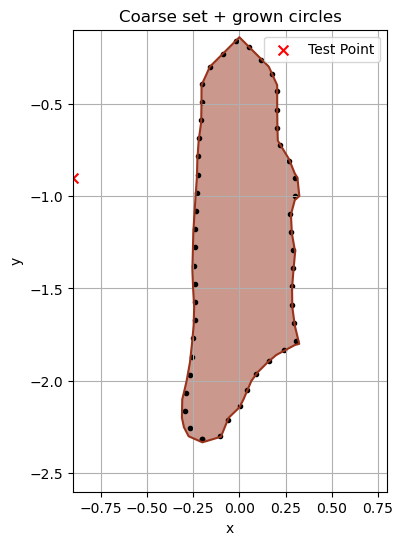

In [104]:
visualize_with_circles([expanded_region], boundary_cells, point=point)

In [54]:
# # visualize points in points dict
# iteration = 2
# plt.figure(figsize=(8, 7))
# points_array = np.array(points_dict[iteration])
# plt.scatter(points_array[:, 0], points_array[:, 1], color='green', s=5, label='Sampled Points')
# plt.title(f'Sampled Points at Iteration {iteration}')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.xticks(np.arange(-0.9, 0.9, epsilon_x), rotation=90)
# plt.yticks(np.arange(-2.6, 0, epsilon_x))
# plt.gca().set_aspect('equal', adjustable='box')
# plt.legend()
# plt.grid()
# plt.show()

In [55]:
# Monte Carlo verification
mc_samples2 = sample_union_of_circles([expanded_region], 1000)

# # Visualize sampled points
# plt.figure(figsize=(8, 6))
# x = np.arange(-0.9, 0.9, epsilon_x)
# y = np.arange(-2.6, 0, epsilon_x)

# plt.scatter(mc_samples2[:, 0], mc_samples2[:, 1], color='green', s=5, alpha=0.5)
# plt.title('Monte Carlo Samples from Grown Safe Regions')
# plt.xlabel('X')
# plt.ylabel('Y')
# plt.xticks(np.arange(-0.9, 0.9, epsilon_x), rotation=90)
# plt.yticks(np.arange(-2.6, 0, epsilon_x))
# plt.gca().set_aspect('equal', adjustable='box')
# plt.grid()
# plt.show()
            
### Verify sampled points
initial_states_mc2 = np.zeros((mc_samples2.shape[0], 12))
initial_states_mc2[:, 0] = mc_samples2[:, 0]
initial_states_mc2[:, 1] = ego_vx
initial_states_mc2[:, 2] = mc_samples2[:, 1]
initial_states_mc2[:, 3] = ego_vy
initial_states_mc2[:, 4] = ego_z
initial_states_mc2[:, 5] = ego_vz
initial_states_mc2[:, 6] = ad_x
initial_states_mc2[:, 7] = ad_vx
initial_states_mc2[:, 8] = ad_y
initial_states_mc2[:, 9] = ad_vy
initial_states_mc2[:, 10] = ad_z
initial_states_mc2[:, 11] = ad_vz

V_mc2, _, _ = calibrate_V_scenario2_vectorized(env, initial_states_mc2, horizon, 
                                             alphaC_list_scenario3, alphaR_list_scenario3)
print(f"Number of safe samples from Monte Carlo: {np.sum(V_mc2 > 0)} out of {len(V_mc2)}")
print(f"Empirical safety rate: {np.sum(V_mc2 > 0) / len(V_mc2) * 100:.2f}%")




NameError: name 'sample_union_of_circles' is not defined

In [56]:
# plot safe states as blue dots and unsafe states as dots
safe_states2 = mc_samples2[V_mc2 > 0]
unsafe_states2 = mc_samples2[V_mc2 <= 0]
plt.figure(figsize=(8, 7))
plt.scatter(safe_states2[:, 0], safe_states2[:, 1], color='blue', s=5, label='Safe States')
plt.scatter(unsafe_states2[:, 0], unsafe_states2[:, 1], color='red', s=5, label='Unsafe States')
plt.title('Verification of Monte Carlo Samples for Expanded Region')
plt.xlabel('X')
plt.ylabel('Y')
plt.xticks(np.arange(-0.9, 0.9, epsilon_x), rotation=90)
plt.yticks(np.arange(-2.6, 0, epsilon_x))
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid()
plt.show()

NameError: name 'mc_samples2' is not defined

shape of V_flipped: (26, 18)
shape of Vlp_flipped: (26, 18)


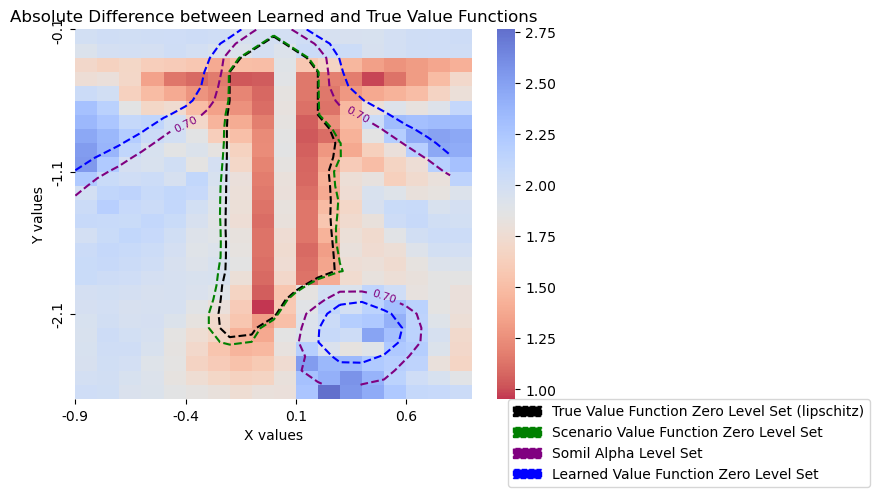

In [57]:
# Evaluate the difference between learned value function and true value function from reach-avoid measure
print(f"shape of V_flipped: {V_flipped.shape}") # learned
print(f"shape of Vlp_flipped: {Vlp_flipped.shape}") # true lower bounded
V_difference = np.abs(V_flipped - Vlp_flipped)
# V_difference = V_flipped - Vlp_flipped

fig14, ax14 = plt.subplots()
# heatmap = ax14.imshow(V_difference, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='bwr', vmin=-np.max(np.abs(V_difference)), vmax=np.max(np.abs(V_difference)))
sns.heatmap(V_difference, annot=False, cmap=cm.coolwarm_r, alpha = 0.8, ax=ax14, cbar=True,
            )
ax14.set_title('Absolute Difference between Learned and True Value Functions')
ax14.set_xlabel('X values')
ax14.set_ylabel('Y values')
# cbar = plt.colorbar(heatmap, ax=ax14)
x_ticks = np.arange(0, len(x), x_interval)
y_ticks = np.arange(0, len(y), y_interval)
ax14.set_xticks(x_ticks)
ax14.set_yticks(y_ticks)
ax14.set_xticklabels(np.round(x[::x_interval], 2))
ax14.set_yticklabels(np.round(y[::-y_interval]+0.02, 1))
# cbar.set_label('Value Function Difference')
# lp = ax14.contour((X+0.9)*50, (Y+2.6)*50, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')
# lp = ax14.contour((X+0.9)*20, (Y+2.6)*20, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')
lp = ax14.contour((X+0.9)*10, (Y+2.6)*10, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')

# ax14.clabel(lp, inline=True, fontsize=8, fmt="%.2f")
# ax14.contour((X+0.9)*50, (Y+2.6)*50, Vlp_scenario_updated_flipped, levels=[0], colors='green', linestyles='dashed')
# ax14.contour((X+0.9)*20, (Y+2.6)*20, Vlp_scenario_updated_flipped, levels=[0], colors='green', linestyles='dashed')
ax14.contour((X+0.9)*10, (Y+2.6)*10, Vlp_scenario_updated_flipped, levels=[0], colors='green', linestyles='dashed')

# somil = ax14.contour((X_V+0.9)*50, (Y_V+2.6)*50, V_flipped, levels=[alpha], colors='purple', linestyles='dashed')
# somil = ax14.contour((X_V+0.9)*20, (Y_V+2.6)*20, V_flipped, levels=[alpha], colors='purple', linestyles='dashed')
somil = ax14.contour((X_V+0.9)*10, (Y_V+2.6)*10, V_flipped, levels=[alpha], colors='purple', linestyles='dashed')

ax14.clabel(somil, inline=True, fontsize=8, fmt="%.2f")
# ax14.contour((X_V+0.9)*50, (Y_V+2.6)*50, V_flipped, levels=[0], colors='blue', linestyles='dashed')
# ax14.contour((X_V+0.9)*20, (Y_V+2.6)*20, V_flipped, levels=[0], colors='blue', linestyles='dashed')
ax14.contour((X_V+0.9)*10, (Y_V+2.6)*10, V_flipped, levels=[0], colors='blue', linestyles='dashed')

# create a legend for the contours
contour_legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='True Value Function Zero Level Set (lipschitz)', linestyle='dashed'),
    Patch(facecolor='green', edgecolor='green', label='Scenario Value Function Zero Level Set', linestyle='dashed'),
    Patch(facecolor='purple', edgecolor='purple', label='Somil Alpha Level Set', linestyle='dashed'),
    Patch(facecolor='blue', edgecolor='blue', label='Learned Value Function Zero Level Set', linestyle='dashed'),
]
ax14.legend(handles=contour_legend_elements, loc='upper left', bbox_to_anchor=(1.09, 0), borderaxespad=0.)
plt.show()

shape of V_flipped: (26, 18)
shape of Vlp_flipped: (26, 18)


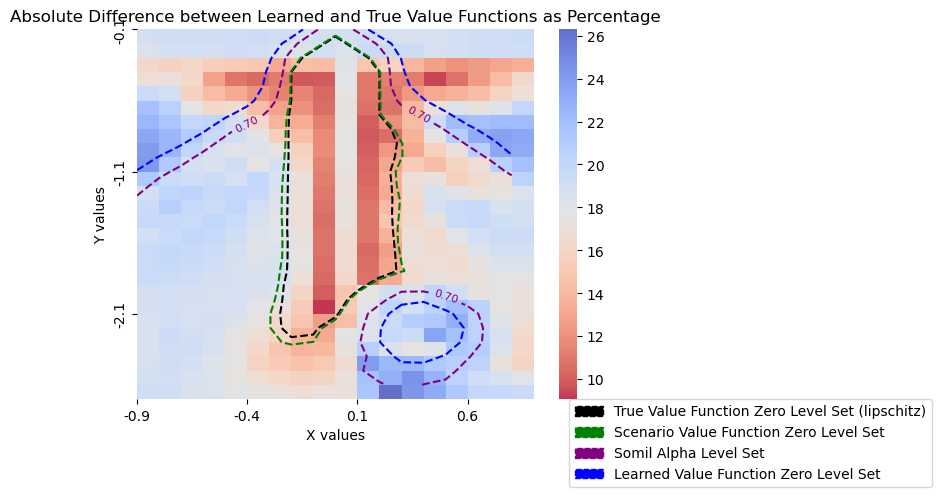

In [58]:
# Evaluate the scaled error between learned value function and true value function from reach-avoid measure
print(f"shape of V_flipped: {V_flipped.shape}") # learned
print(f"shape of Vlp_flipped: {Vlp_flipped.shape}") # true lower bounded
# V_difference = np.abs(V_flipped - Vlp_flipped)
# V_difference = V_flipped - Vlp_flipped
V_difference = np.abs(V_flipped - Vlp_flipped) / (np.max(Vlp_flipped) - np.min(Vlp_flipped)) * 100

fig14, ax14 = plt.subplots()
# heatmap = ax14.imshow(V_difference, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='bwr', vmin=-np.max(np.abs(V_difference)), vmax=np.max(np.abs(V_difference)))
sns.heatmap(V_difference, annot=False, cmap=cm.coolwarm_r, alpha = 0.8, ax=ax14, cbar=True,
            )
ax14.set_title('Absolute Difference between Learned and True Value Functions as Percentage')
ax14.set_xlabel('X values')
ax14.set_ylabel('Y values')
# cbar = plt.colorbar(heatmap, ax=ax14)
x_ticks = np.arange(0, len(x), x_interval)
y_ticks = np.arange(0, len(y), y_interval)
ax14.set_xticks(x_ticks)
ax14.set_yticks(y_ticks)
ax14.set_xticklabels(np.round(x[::x_interval], 2))
ax14.set_yticklabels(np.round(y[::-y_interval]+0.02, 1))
# cbar.set_label('Value Function Difference')
# lp = ax14.contour((X+0.9)*50, (Y+2.6)*50, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')
# lp = ax14.contour((X+0.9)*20, (Y+2.6)*20, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')
lp = ax14.contour((X+0.9)*10, (Y+2.6)*10, Vlp_flipped, levels=[0], colors='black', linestyles='dashed')

# ax14.clabel(lp, inline=True, fontsize=8, fmt="%.2f")
# ax14.contour((X+0.9)*50, (Y+2.6)*50, Vlp_scenario_updated_flipped, levels=[0], colors='green', linestyles='dashed')
# ax14.contour((X+0.9)*20, (Y+2.6)*20, Vlp_scenario_updated_flipped, levels=[0], colors='green', linestyles='dashed')
ax14.contour((X+0.9)*10, (Y+2.6)*10, Vlp_scenario_updated_flipped, levels=[0], colors='green', linestyles='dashed')

# somil = ax14.contour((X_V+0.9)*50, (Y_V+2.6)*50, V_flipped, levels=[alpha], colors='purple', linestyles='dashed')
# somil = ax14.contour((X_V+0.9)*20, (Y_V+2.6)*20, V_flipped, levels=[alpha], colors='purple', linestyles='dashed')
somil = ax14.contour((X_V+0.9)*10, (Y_V+2.6)*10, V_flipped, levels=[alpha], colors='purple', linestyles='dashed')

ax14.clabel(somil, inline=True, fontsize=8, fmt="%.2f")
# ax14.contour((X_V+0.9)*50, (Y_V+2.6)*50, V_flipped, levels=[0], colors='blue', linestyles='dashed')
# ax14.contour((X_V+0.9)*20, (Y_V+2.6)*20, V_flipped, levels=[0], colors='blue', linestyles='dashed')
ax14.contour((X_V+0.9)*10, (Y_V+2.6)*10, V_flipped, levels=[0], colors='blue', linestyles='dashed')

# create a legend for the contours
contour_legend_elements = [
    Patch(facecolor='black', edgecolor='black', label='True Value Function Zero Level Set (lipschitz)', linestyle='dashed'),
    Patch(facecolor='green', edgecolor='green', label='Scenario Value Function Zero Level Set', linestyle='dashed'),
    Patch(facecolor='purple', edgecolor='purple', label='Somil Alpha Level Set', linestyle='dashed'),
    Patch(facecolor='blue', edgecolor='blue', label='Learned Value Function Zero Level Set', linestyle='dashed'),
]
ax14.legend(handles=contour_legend_elements, loc='upper left', bbox_to_anchor=(1.09, 0), borderaxespad=0.)
plt.show()

In [ ]:
# ## Looping systematically through confidences and 
# ## sample breakdowns and saving plots

# import os
# import seaborn as sns
# import matplotlib.pyplot as plt
# from matplotlib.patches import Circle
# from matplotlib.patches import Patch

# save_dir = "./figures_updated_again_nobugs_epsx0.01"
# os.makedirs(save_dir, exist_ok=True)

# # confidence_list = [0.9, 0.95, 0.97, 0.975, 0.98, 0.99]
# confidence_list = [0.99]
# factor_list = [1, 5, 10, 20, 50, 100]
# labels = [0, 1]
# M = 4 # loops for iterative method
# horizon = 20

# Lf = 1.05125
# Lc=20
# Lr=10
# Ld = 0.1
# epsilon_d = 0.1
# epsilon_x = 0.01 #0.05
# certification_gamma = args.gamma

# x = np.arange(-0.9, 0.9, 0.05)
# y = np.arange(-2.6, 0, 0.05)
# X, Y = np.meshgrid(x, y)
# size_x = len(x)
# size_y = len(y)

# ## Lipschitz Certification
# got_lipschitz_Values = False
# env = gym.make(args.task)
# alphaC_list = np.zeros(horizon)
# alphaR_list = np.zeros(horizon)
# for t in range(horizon):
#     alphaC_list[t] = Lc * beta(t, Lf, Ld, epsilon_x, epsilon_d)
#     alphaR_list[t] = Lr * beta(t, Lf, Ld, epsilon_x, epsilon_d)
# V_lp = np.zeros((X.shape))
# ##

# ## SOCP Certification done once above
# V_qp = V_qp.copy()
# total_time_qp = total_time_qp
# ##


# for confidence in confidence_list:
#     for factor in factor_list:
#         print(f"Confidence: {confidence}, Factor: {factor}")
#         eps = 1 - confidence
#         delt = 1e-16

#         env = gym.make(args.task)
#         alpha_iterative, total_time_iterative = solve_iterative_method(env, eps, delt, M, horizon, epsilon_d)

#         alphaC_list_scenario3 = np.zeros(horizon)
#         alphaR_list_scenario3 = np.zeros(horizon)
#         env = gym.make(args.task)
#         start_time_scenario3 = time.time()
#         scenario_radii3, initial_states_scenario3 = get_beta3(env, horizon, epsilon_x, epsilon_d)
#         scenario_radii3_adjusted = scenario_radii3 + [Lf**t * epsilon_x for t in range(horizon + 1)]
#         scenario_betas3 = scenario_radii3_adjusted * certification_gamma**np.arange(horizon+1)
        
#         for t in range(horizon):
#             alphaC_list_scenario3[t] = Lc * scenario_betas3[t]
#             alphaR_list_scenario3[t] = Lr * scenario_betas3[t]

#         end_time_scenario3 = time.time()
#         total_time_scenario3 = end_time_scenario3 - start_time_scenario3

#         for label in labels:
#             alphaC_list_scenario2 = np.zeros(horizon)
#             alphaR_list_scenario2 = np.zeros(horizon)
#             print(f"Label: {label}")
#             env = gym.make(args.task)
#             start_time_scenario2 = time.time()
#             scenario_radii2, total_time_scenario, initial_states_scenario = get_beta2(env, horizon, epsilon_x, epsilon_d, label=label)
#             scenario_radii_adjusted = scenario_radii2 + [Lf**t * epsilon_x for t in range(horizon + 1)]
#             scenario_betas2 = scenario_radii2_adjusted * certification_gamma**np.arange(horizon+1)

#             for t in range(horizon):
#                 alphaC_list_scenario2[t] = Lc * scenario_betas2[t]
#                 alphaR_list_scenario2[t] = Lr * scenario_betas2[t]
#             end_time_scenario2 = time.time()
#             total_time_scenario2 = end_time_scenario2 - start_time_scenario2
#             # Getting value functions
#             V_iterative = V.copy()

            
#             # V_lp_scenario_updated = np.zeros((X.shape))

#             V_lp_scenario_new = []  # factor of trajectories per initial condition
#             V_lp_scenario_time_new = []

#             V_lp_scenario_new2 = []    # one trajectory per initial condition
#             V_lp_scenario_time_new2 = []

#             V_lp_scenario_new_gridded_initcond = np.zeros((X.shape))  # factor of trajectories per initial condition; gridded init conds
#             V_lp_scenario_new2_gridded_initcond = np.zeros((X.shape))  # one trajectory per initial condition; gridded init conds

#             for init_cond in initial_states_scenario:
#                 # import pdb; pdb.set_trace()
#                 env = gym.make(args.task)
#                 vlp, vlptime = calibrate_V_scenario(env, init_cond, horizon, alphaC_list_scenario2, alphaR_list_scenario2, verbose=False)
#                 V_lp_scenario_new.append(vlp)
#                 V_lp_scenario_time_new.append(vlptime)
            
#             for init_cond in initial_states_scenario3:
#                 env = gym.make(args.task)
#                 vlp2, vlptime2 = calibrate_V_scenario(env, init_cond, horizon, alphaC_list_scenario3, alphaR_list_scenario3, verbose=False)
#                 V_lp_scenario_new2.append(vlp2)
#                 V_lp_scenario_time_new2.append(vlptime2)

#             for ii in range(V_lp.shape[0]):
#                 for jj in range(V_lp.shape[1]):
#                     tmp_point = torch.tensor([
#                         X[ii,jj], ego_vx,
#                         Y[ii,jj], ego_vy,
#                         ego_z, ego_vz,
#                         ad_x, ad_vx,
#                         ad_y, ad_vy,
#                         ad_z, ad_vz
#                     ])
#                     if not got_lipschitz_Values:
#                         V_lp[ii,jj], _ = calibrate_V(env, tmp_point.numpy(), horizon)

#                         # got_lipschitz_Values = True
                    
#                     V_lp_scenario_new_gridded_initcond[ii,jj], _ = calibrate_V_scenario(env, tmp_point.numpy(), horizon, alphaC_list_scenario2, alphaR_list_scenario2, verbose=False)
#                     V_lp_scenario_new2_gridded_initcond[ii,jj], _ = calibrate_V_scenario(env, tmp_point.numpy(), horizon, alphaC_list_scenario3, alphaR_list_scenario3, verbose=False)
            
#             got_lipschitz_Values = True

#             ## Visulalization and saving plots (one big plot with subplots)
#             V_flipped = np.flipud(V_iterative)
#             Vlp_flipped = np.flipud(V_lp)
#             # Vlp_scenario_updated_flipped = np.flipud(V_lp_scenario_updated)
#             Vqp_flipped = np.flipud(V_qp)
#             Vlp_scenario_new_gridded_initcond_flipped = np.flipud(V_lp_scenario_new_gridded_initcond)
#             Vlp_scenario_new2_gridded_initcond_flipped = np.flipud(V_lp_scenario_new2_gridded_initcond)

#             fig, ax = plt.subplots(4, 2, figsize=(13, 18))
#             fig.tight_layout(pad=6.0)
#             ax = ax.flatten()

#             x_interval = 5
#             y_interval = 10
#             x_ticks = np.arange(0, len(x), x_interval)
#             y_ticks = np.arange(0, len(y), y_interval)

#             sns.heatmap(Vlp_flipped, annot=False, cmap=cm.coolwarm_r, alpha = 0.9, ax=ax[0], cbar=False)
#             ax[0].set_title('Lipschitz certified reach-avoid set')

#             sns.heatmap(Vqp_flipped, annot=False, cmap=cm.coolwarm_r, alpha = 0.9, ax=ax[1], cbar=False)
#             ax[1].set_title('SOCP certified reach-avoid set')

#             # sns.heatmap(Vlp_scenario_updated_flipped, annot=False, cmap=cm.coolwarm_r, alpha = 0.9, ax=ax[2], cbar=False)
#             # ax[2].set_title('Scenario + Lipschitz certified reach-avoid set')

#             for i in range(2):
#                 ax[i].set_xticks(x_ticks)
#                 ax[i].set_yticks(y_ticks)
#                 ax[i].set_xticklabels(np.round(x[::x_interval], 2))
#                 ax[i].set_yticklabels(np.round(y[::-y_interval]+0.02, 1))
#                 # contours = ax[i].contour((X+0.9)*100, (Y+2.6)*100, V_flipped, levels=[alpha], colors='black', linestyles='dashed')
#                 # ax[i].clabel(contours, inline=True, fontsize=8, fmt="%.2f")
#                 ax[i].set_xlabel('X values')
#                 ax[i].set_ylabel('Y values')

#             norm = colors.Normalize(vmin=min(V_lp_scenario_new), vmax=max(V_lp_scenario_new))
#             cmap = cm.coolwarm_r
#             for xcoor, ycoor, vlp, vlptime in zip(initial_states_scenario[:, 0], initial_states_scenario[:, 2], V_lp_scenario_new, V_lp_scenario_time_new):
#                 circle = Circle((xcoor, ycoor), radius=epsilon_x, color=cmap(norm(vlp)), alpha=0.7)
#                 ax[2].add_patch(circle)
#             ax[2].set_xlim(-0.9, 0.9)
#             ax[2].set_ylim(-2.6, 0)
#             ax[2].set_title(f'Scenario certified reach-avoid set (Old Method) with N ={len(initial_states_scenario)}')
#             ax[2].set_xlabel('X values')
#             ax[2].set_ylabel('Y values')

#             norm2 = colors.Normalize(vmin=min(V_lp_scenario_new2), vmax=max(V_lp_scenario_new2))
#             cmap2 = cm.coolwarm_r
#             for xcoor, ycoor, vlp, vlptime in zip(initial_states_scenario3[:, 0], initial_states_scenario3[:, 2], V_lp_scenario_new2, V_lp_scenario_time_new2):
#                 circle = Circle((xcoor, ycoor), radius=epsilon_x, color=cmap2(norm2(vlp)), alpha=0.7)
#                 ax[3].add_patch(circle)
#             ax[3].set_xlim(-0.9, 0.9)
#             ax[3].set_ylim(-2.6, 0)
#             ax[3].set_title(f'Scenario certified reach-avoid set (New Method) with N = {len(initial_states_scenario3)}')
#             ax[3].set_xlabel('X values')
#             ax[3].set_ylabel('Y values')

#             sns.heatmap(Vlp_scenario_new_gridded_initcond_flipped, annot=False, cmap=cm.coolwarm_r, alpha = 0.9, ax=ax[4], cbar=False)
#             ax[4].set_title('Scenario certified reach-avoid set (Old Method) - Gridded Init Conds')

#             sns.heatmap(Vlp_scenario_new2_gridded_initcond_flipped, annot=False, cmap=cm.coolwarm_r, alpha = 0.9, ax=ax[5], cbar=False)
#             ax[5].set_title('Scenario certified reach-avoid set (New Method) - Gridded Init Conds')

#             for i in range(4, 6):
#                 ax[i].set_xticks(x_ticks)
#                 ax[i].set_yticks(y_ticks)
#                 ax[i].set_xticklabels(np.round(x[::x_interval], 2))
#                 ax[i].set_yticklabels(np.round(y[::-y_interval]+0.02, 1))
#                 # contours = ax[i].contour((X+0.9)*100, (Y+2.6)*100, V_flipped, levels=[alpha], colors='black', linestyles='dashed')
#                 # ax[i].clabel(contours, inline=True, fontsize=8, fmt="%.2f")
#                 ax[i].set_xlabel('X values')
#                 ax[i].set_ylabel('Y values')

#             sns.heatmap(V_flipped, annot=False, cmap=cm.coolwarm_r, alpha = 0.9, ax=ax[6], cbar=False,
#                         vmin=V_flipped.min(),
#                         vmax=-V_flipped.min(),
#                         )
#             x_V = np.arange(-0.9, 0.9, 0.01)
#             y_V = np.arange(-2.6, 0, 0.01)
#             X_V, Y_V = np.meshgrid(x_V, y_V)
#             x_V_interval = 30
#             y_V_interval = 60
#             x_ticks = np.arange(0, len(x_V), x_V_interval)
#             y_ticks = np.arange(0, len(y_V), y_V_interval)
#             ax[6].set_xticks(x_ticks)
#             ax[6].set_yticks(y_ticks)
#             ax[6].set_xticklabels(np.round(x_V[::x_V_interval], 2))
#             ax[6].set_yticklabels(np.round(y_V[::-y_V_interval]+0.02, 1))
#             contours2 = ax[6].contour((X_V+0.9)*100, (Y_V+2.6)*100, V_flipped, levels=[alpha], colors='black', linestyles='dashed')
#             ax[6].clabel(contours2, inline=True, fontsize=8, fmt="%.2f")
#             ax[6].set_title('Scenario Iterative certified reach-avoid set')

#             binary_Viterative = np.zeros(V_iterative.shape)
#             binary_Viterative[V_iterative > alpha_iterative] = 1

#             binary_Vlp = np.zeros(V_lp.shape)
#             binary_Vlp[V_lp > 0] = 1

#             binary_Vqp = np.zeros(V_qp.shape)
#             binary_Vqp[V_qp > 0] = 1

#             # binary_Vscenario_updated = np.zeros(V_lp_scenario_updated.shape)
#             # binary_Vscenario_updated[V_lp_scenario_updated > 0] = 1
#             ax[7].contour(X, Y, binary_Vlp, levels=[1 - 1e-6], colors=color_list[2], 
#                           label='Lipschitz')
#             ax[7].contour(X, Y, binary_Vqp, levels=[1 - 1e-6], colors=color_list[0], 
#                           label='SOCP')
#             ax[7].contourf(X, Y, binary_Vlp, levels=[1 - 1e-6, 1], colors=color_list[2], alpha=0.5)
#             ax[7].contourf(X, Y, binary_Vqp, levels=[1 - 1e-6, 1], colors=color_list[0], alpha=0.5)

#             # ax[5].contour(X, Y, binary_Vscenario_updated, levels=[1 - 1e-6], colors=color_list[8], 
#                         #   label='Scenario + Lipschitz')
#             # ax[5].contourf(X, Y, binary_Vscenario_updated, levels=[1 - 1e-6, 1], colors=color_list[8], alpha=0.5)

#             ax[7].contour(X_V, Y_V, binary_Viterative, levels=[1 - 1e-6], colors=color_list[3]
#                           , label='Scenario Iterative')
#             ax[7].contourf(X_V, Y_V, binary_Viterative, levels=[1 - 1e-6, 1], colors=color_list[3], alpha=0.5)

#             norm = colors.Normalize(vmin=min(V_lp_scenario_new), vmax=max(V_lp_scenario_new))
#             # cmap = cm.coolwarm_r
#             cmap = cm.Blues
#             for xcoor, ycoor, vlp, vlptime in zip(initial_states_scenario[:, 0], initial_states_scenario[:, 2], V_lp_scenario_new, V_lp_scenario_time_new):
#                 if vlp > 0:
#                     circle = Circle((xcoor, ycoor), radius=epsilon_x, color=cmap(norm(vlp)), alpha=0.7)
#                     ax[7].add_patch(circle)
#             ax[7].set_xlim(-0.9, 0.9)
#             ax[7].set_ylim(-2.6, 0)
#             # ax[7].set_title(f'Scenario certified reach-avoid set (Old Method) with N ={len(initial_states_scenario)}')
#             # ax[7].set_xlabel('X values')
#             # ax[7].set_ylabel('Y values')

#             norm2 = colors.Normalize(vmin=min(V_lp_scenario_new2), vmax=max(V_lp_scenario_new2))
#             # cmap2 = cm.coolwarm_r
#             cmap2 = cm.Reds
#             for xcoor, ycoor, vlp, vlptime in zip(initial_states_scenario3[:, 0], initial_states_scenario3[:, 2], V_lp_scenario_new2, V_lp_scenario_time_new2):
#                 if vlp > 0:
#                     circle = Circle((xcoor, ycoor), radius=epsilon_x, color=cmap2(norm2(vlp)), alpha=0.7)
#                     ax[7].add_patch(circle)
#             # ax[7].set_xlim(-0.9, 0.9)
#             # ax[7].set_ylim(-2.6, 0)
#             # ax[7].set_title(f'Scenario certified reach-avoid set (New Method) with N = {len(initial_states_scenario3)}')
#             # ax[7].set_xlabel('X values')
#             # ax[7].set_ylabel('Y values')


#             ax[7].set_title('Overlay of Certified Reach-Avoid Sets')
#             ax[7].grid()
#             ax[7].set_xlabel('X values')
#             ax[7].set_ylabel('Y values')
#             ax[7].add_patch(Circle((0,0), 0, color="blue", alpha=0.4, label="Old Method"))
#             ax[7].add_patch(Circle((0,0), 0, color="red", alpha=0.4, label="New Method"))



#             legend_elements = [
#                 Patch(facecolor=color_list[2], alpha=0.5, label="Lipschitz"),
#                 Patch(facecolor=color_list[0], alpha=0.5, label="SOCP"),
#                 Patch(facecolor=color_list[3], alpha=0.5, label="Scenario Iterative"),
#                 Patch(facecolor="blue", alpha=0.4, label="Old Method Circles"),
#                 Patch(facecolor="red", alpha=0.4, label="New Method Circles")
#             ]
#             # ax[7].legend(handles=legend_elements, loc='upper right')
#             ax[7].legend(
#                 handles=legend_elements,
#                 loc="upper left",                # corner of legend
#                 bbox_to_anchor=(1.05, 1),        # shift legend outside axes
#                 borderaxespad=0.
#             )
#             # ax[7].legend(loc='upper right')

#             # ax[5].axis('off')

#             fig.suptitle(f'Confidence: {confidence}, Factor: {factor}, Label: {label}', fontsize=16)
#             plt.tight_layout(rect=[0, 0, 1, 0.96])
#             save_path = os.path.join(save_dir, f'certification_conf_{confidence}_factor_{factor}_label_{label}.png')
#             plt.savefig(save_path, dpi=300)
#             plt.close(fig)









            

            

            




In [59]:
"""
success rate is computed by recording the number of initial states that can be maintained within the target set for 100 steps
"""
from LCRL.data import Batch
from tqdm import tqdm

def find_a(state):
    tmp_obs = np.array(state).reshape(1,-1)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy(tmp_batch, model = "actor_old").act
    act = policy.map_action(tmp).cpu().detach().numpy().flatten()
    act[3:] = np.random.uniform(-1, 1, size = 3)
    return act

def evaluate_V(state):
    tmp_obs = np.array(state).reshape(1,-1)
    tmp_batch = Batch(obs = tmp_obs, info = Batch())
    tmp = policy.critic_old(tmp_batch.obs, policy(tmp_batch, model="actor_old").act)
    return tmp.cpu().detach().numpy().flatten()

import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import numpy as np
import math

n_dim = env.observation_space.shape[0]
def roll_out_traj(env, state, horizon, verbose = False):
    n_dim = env.observation_space.shape[0]
    state_traj = np.zeros((n_dim, horizon+1))
    
    state_traj[:,0] = state
    # env.reset(initial_state = state)
    options = {'initial_state': state}
    env.reset(options=options)
    safe_reaching_time = np.inf
    for t in range(horizon):
        action = find_a(state_traj[:,t])
        rand_disturbance = np.random.uniform(low = -1, high = 1, size = (3,))
        # action = np.array([action[0], action[1], action[2], rand_disturbance[0], rand_disturbance[1], rand_disturbance[1]])
        action = np.array([action[0], action[1], action[2], 0, 0, 0])
        tmp, rew, _, _, info = env.step(action)
        
        state_traj[:,t+1] = tmp
        if rew > 0 and t<=horizon-2 and info["constraint"] > 0:
            if t>1 and verbose:
                print("success at time = {}!".format(t))
            return state_traj[:,:t+1], True, rand_disturbance

        if info["constraint"] < 0:
            print("constraint violated!") if verbose else None
            return state_traj[:,:t+1], False, rand_disturbance
            break
        
        if state_traj[2,t+1] > 0 or state_traj[8,t+1] > 0:
            print("A Drone passed frame!") if verbose else None
            return state_traj[:,:t+1], False, rand_disturbance
            break
    return state_traj, False, rand_disturbance

num_samples = 100
sampled_states = np.zeros((n_dim,num_samples))
num_success = 0
horizon = 300
high = np.array([  
                0.8,  0.2,  -1.5,  0.7,  0.8,  0.2,
                0.8,  0.2,  -1.5,  0.7,  0.8,  0.2,
                ], dtype=np.float32) # x1 vx1 y1 vy1 z1 vz1          x2 vx2 y2 vy2 z2 vz2
low  = np.array([  
                -0.8, -0.2, -3, 0.2, -0.8, -0.2,
                -0.8, -0.2, -3, 0.2, -0.8, -0.2,
                ], dtype=np.float32)

list_of_failure_states = []
list_of_success_states = []
list_of_sampled_states = []
for ii in tqdm(range(num_samples)):
    sampled_initial_state = np.random.uniform(low = low, high = high)
    # tmp = envs.reset(initial_state = sampled_initial_state)
    options = {'initial_state': sampled_initial_state}
    tmp = envs.reset(options=options)
    sampled_states[:,ii] = tmp[0]
    while evaluate_V(sampled_states[:,ii]) < 0:
        sampled_initial_state = np.random.uniform(low = low, high = high)
        # tmp = envs.reset(initial_state = sampled_initial_state)
        options = {'initial_state': sampled_initial_state}
        tmp = envs.reset(options=options)
        sampled_states[:,ii] = tmp[0]
    list_of_sampled_states.append(sampled_states[:,ii])
    traj, success,_ = roll_out_traj(envs, sampled_states[:,ii], horizon, verbose = True)
    if success==True :
        num_success = num_success + 1
        list_of_success_states.append(sampled_states[:,ii])
    else:
        list_of_failure_states.append(sampled_states[:,ii])
        continue
num_success/num_samples

  3%|▎         | 3/100 [00:00<00:04, 22.75it/s]

success at time = 15!
success at time = 19!
success at time = 23!
success at time = 9!
success at time = 14!
success at time = 16!


 11%|█         | 11/100 [00:00<00:03, 28.59it/s]

success at time = 25!
success at time = 14!
success at time = 27!
success at time = 2!
success at time = 5!
success at time = 19!
success at time = 16!


 18%|█▊        | 18/100 [00:00<00:02, 27.98it/s]

...

 92%|█████████▏| 92/100 [00:03<00:00, 21.85it/s]

success at time = 16!
success at time = 16!
constraint violated!
success at time = 2!
success at time = 30!
success at time = 10!


100%|██████████| 100/100 [00:03<00:00, 28.12it/s]

success at time = 27!
success at time = 9!
success at time = 10!
success at time = 9!


0.97

In [60]:
# save the list of sampled states, we will use them in the notebook "droneracing_post_training_DDPG_evaluation_classical.ipynb" to evaluate the learned policy there on this set of initial states

import pickle
with open("list_of_initial_states_droneracing_from_new_reachability_value_function_learning.pkl", "wb") as f:
    pickle.dump(list_of_sampled_states, f)

In [61]:
# # Test how the learned policy performs on the sampled initial states from droneracing_post_training_DDPG_evaluation_classical.ipynb
# NOTE! We assume the list_of_initial_states_droneracing_from_classical_reachability_value_function_learning.pkl is stored in the current directory, which can be obtained from droneracing_post_training_DDPG_evaluation_classical.ipynb
import pickle
with open("list_of_initial_states_droneracing_from_classical_reachability_value_function_learning.pkl", "rb") as f:
    list_of_initial_sampled_states = pickle.load(f)
num_samples = len(list_of_initial_sampled_states)
list_of_success_states = []
list_of_failure_states = []
num_success = 0
for ii in tqdm(range(num_samples)):
    # tmp = envs.reset(initial_state = sampled_initial_state)
    options = {'initial_state': sampled_initial_state}
    tmp = envs.reset(options=options)
    traj, success,_ = roll_out_traj(envs, list_of_initial_sampled_states[ii], horizon, verbose = True)
    if success==True :
        num_success = num_success + 1
        list_of_success_states.append(list_of_initial_sampled_states[ii])
    else:
        list_of_failure_states.append(list_of_initial_sampled_states[ii])
        continue
num_success/num_samples

  6%|▌         | 6/98 [00:00<00:01, 50.82it/s]

success at time = 8!
success at time = 10!
success at time = 7!
success at time = 10!
success at time = 16!
success at time = 13!
success at time = 9!
success at time = 6!
success at time = 2!


 18%|█▊        | 18/98 [00:00<00:01, 53.45it/s]

success at time = 8!
success at time = 13!
success at time = 9!
success at time = 11!
success at time = 4!
success at time = 13!
success at time = 6!
success at time = 8!
success at time = 4!
success at time = 10!
success at time = 7!


 33%|███▎      | 32/98 [00:00<00:01, 57.35it/s]

...

 91%|█████████ | 89/98 [00:01<00:00, 56.98it/s]

success at time = 12!
success at time = 11!
success at time = 10!
success at time = 9!
success at time = 10!
success at time = 11!
success at time = 7!
success at time = 11!


100%|██████████| 98/98 [00:01<00:00, 54.42it/s]

success at time = 9!
success at time = 10!
success at time = 8!
success at time = 11!
success at time = 7!
success at time = 9!


1.0

100%|██████████| 520/520 [00:12<00:00, 40.74it/s]
/tmp/ipykernel_3617319/3968439498.py:61: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(X,Y,reward, levels=[1 - 1e-6, 1],  colors = "#80A8D6", alpha = 0.5,
/tmp/ipykernel_3617319/3968439498.py:65: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(X,Y,reward, levels=[1 - 1e-6], colors = "#80A8D6", alpha=1, label = "target set")
100%|██████████| 1/1 [00:12<00:00, 12.78s/it]


(-0.95, 0.95)

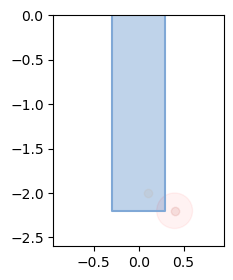

In [62]:
#9748
# note that we need to load epoch = 1600!!!!!!!!
# plot the target set too!
import matplotlib.pyplot as plt
import matplotlib.animation as manimation
import matplotlib
from tqdm import tqdm
FFMpegWriter = manimation.writers['ffmpeg']
writer = FFMpegWriter(fps=15, metadata=dict(artist='Me'))
initial_state = np.array([
    0.1, ego_vx, # x, vx
    -2.0, ego_vy,
    ego_z, ego_vz,
    ad_x, ad_vx,
    ad_y, ad_vy,
    ad_z, ad_vz
])

# initial_state = np.array([
#     -0.1, ego_vx, # x, vx
#     -0.3, ego_vy,
#     ego_z, ego_vz,
#     ad_x, ad_vx,
#     ad_y, ad_vy,
#     ad_z, ad_vz
# ])
horizon = 300
traj,_,rand_disturbance = roll_out_traj(envs, initial_state, horizon, verbose=True)
fig, ax = plt.subplots(figsize=(2.2,3))
min_x = -0.6
max_x = 0.6
min_y = -2.8
max_y = -1.4
alphas = np.linspace(0.1, 1.0, len(traj[0,:]))
ax.scatter(traj[0,:], traj[2,:],  color = color_list[0], alpha = alphas ) #"o", color="#314cd4",  label = "ego")
ax.scatter(traj[6,:], traj[8,:],  color = color_list[4], alpha = alphas) #'o', color="#EA3323",label = "adversary")


def target_set(env, X, Y, tmp_point = np.array([
    0, 0.,-1, 0.8,-0.0, 0,0.3,  0,-2.2, 0.3,0., 0
])):
    reward = np.zeros((X.shape))
    for ii in tqdm(range(reward.shape[0])):
        for jj in range(reward.shape[1]):
            tmp_point[0], tmp_point[2] = X[ii,jj], Y[ii,jj]
            # env.reset(initial_state = tmp_point)
            options = {'initial_state': tmp_point}
            env.reset(options=options)
            reward[ii,jj] = 1 if env.step([0,0,0,0,0,0])[1]>=0 else 0
    return reward

plt.rcParams["contour.linewidth"]=1.5

for j in tqdm(range(traj.shape[1])):    
    # plot the target set
    if j == traj.shape[1]-1:
        x = np.arange(-0.9, 0.9, 0.005)
        y = np.arange(-2.6, 0, 0.005)
        X, Y = np.meshgrid(x, y)
        reward = target_set(envs, X, Y, traj[:,j])
        plt.contourf(X,Y,reward, levels=[1 - 1e-6, 1],  colors = "#80A8D6", alpha = 0.5, 
                    label = "target set"
                    # hatches=['//']
                    )
        plt.contour(X,Y,reward, levels=[1 - 1e-6], colors = "#80A8D6", alpha=1, label = "target set")
    ax.add_patch(matplotlib.patches.Circle((traj[6,j], traj[8,j]), 0.2, color='r', fill=True, alpha=0.05))
ax.set_ylim([-2.6, 0])
ax.set_xlim([-0.95, 0.95])


success at time = 17!
traj shape: (12, 18)


100%|██████████| 18/18 [00:15<00:00,  1.19it/s]


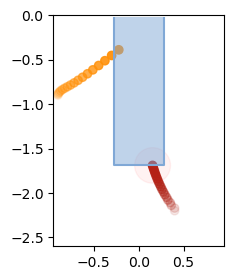

In [67]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as manimation
import matplotlib
from tqdm import tqdm

FFMpegWriter = manimation.writers['ffmpeg']
writer = FFMpegWriter(fps=15, metadata=dict(artist='Me'))

# --- Parameters ---
# initial_state = np.array([
#     -0.76, ego_vx,  # x, vx
#     -2.5, ego_vy,
#     ego_z, ego_vz,
#     ad_x, ad_vx,
#     ad_y, ad_vy,
#     ad_z, ad_vz
# ])

# initial_state = np.array([
#     -0.9, ego_vx,  # x, vx
#     -0.9, ego_vy,
#     ego_z, ego_vz,
#     ad_x, ad_vx,
#     ad_y, ad_vy,
#     ad_z, ad_vz
# ])

initial_state = np.array([
    -0.9, ego_vx,  # x, vx
    -0.9, 0.1,
    ego_z, ego_vz,
    ad_x, ad_vx,
    ad_y, ad_vy,
    ad_z, ad_vz
])

# initial_state = np.array([
#     -0.66022104,  0.56769637, -2.07759241,  0.89082305, -0.02117593, -0.17434851,
#   0.30126442, -0.17482849, -2.02,        0.3,         0.,          0.        ])
horizon = 300

# Roll out the trajectory
traj, _, rand_disturbance = roll_out_traj(envs, initial_state, horizon, verbose=True)
# print(f"traj ego x: {traj[0,:]}")
# print(f"traj ego y: {traj[2,:]}")
# print(f"traj adv x: {traj[6,:]}")
# print(f"traj adv y: {traj[8,:]}")
print(f"traj shape: {traj.shape}")
# Plot setup
fig, ax = plt.subplots(figsize=(2.2,3))
ax.set_xlim([-0.95, 0.95])
ax.set_ylim([-2.6, 0])

# --- Target set function ---
def target_set(env, X, Y, tmp_point):
    reward = np.zeros(X.shape)
    for ii in range(reward.shape[0]):
        for jj in range(reward.shape[1]):
            tmp_point[0], tmp_point[2] = X[ii,jj], Y[ii,jj]
            # env.reset(initial_state=tmp_point)
            options = {'initial_state': tmp_point}
            env.reset(options=options)
            reward[ii,jj] = 1 if env.step([0,0,0,0,0,0])[1] >= 0 else 0
    return reward

plt.rcParams["contour.linewidth"] = 1.5

# --- Animation function ---
def animate(i):
    ax.clear()
    ax.set_xlim([-0.95, 0.95])
    ax.set_ylim([-2.6, 0])
    
    # Plot ego and adversary trajectory so far
    alphas = np.linspace(0.1, 1.0, i+1)
    ax.scatter(traj[0,:i+1], traj[2,:i+1], color=color_list[0], alpha=alphas, label='ego')
    # print(f"ego traj x: {traj[0,:i+1]}")
    # print(f"ego traj y: {traj[2,:i+1]}")
    ax.scatter(traj[6,:i+1], traj[8,:i+1], color=color_list[4], alpha=alphas, label='adversary')
    
    # Small circle for current adversary position
    ax.add_patch(matplotlib.patches.Circle((traj[6,i], traj[8,i]), 0.2, color='r', fill=True, alpha=0.05))
    
    # --- Compute and plot moving target set around current point ---
    x = np.arange(-0.9, 0.9, 0.02)  # coarser grid for speed
    y = np.arange(-2.6, 0, 0.02)
    X, Y = np.meshgrid(x, y)
    reward = target_set(envs, X, Y, traj[:,i].copy())
    
    # Draw contours
    contf = ax.contourf(X, Y, reward, levels=[1-1e-6, 1], colors="#80A8D6", alpha=0.5)
    cont = ax.contour(X, Y, reward, levels=[1-1e-6], colors="#80A8D6", alpha=1)
    
    return contf, cont  # return for blitting (optional)

# --- Create video ---
# print(f"traj length: {len(traj[0,:])}")
# print(f"ego traj x: {traj[0,:]}")
# print(f"ego traj y: {traj[2,:]}")
folder = "videos"
os.makedirs(folder, exist_ok=True)
with writer.saving(fig, os.path.join(folder, f"trajectory_moving_target_egox{traj[0,0]:.2f}_egoy{traj[2,0]:.2f}_advx{traj[6,0]:.2f}_advy{traj[8,0]:.2f}.mp4"), dpi=150):
    for i in tqdm(range(traj.shape[1])):
        animate(i)
        writer.grab_frame()


In [66]:
print(f"ego_vx: {ego_vx}, ego_vy: {ego_vy}, ego_z: {ego_z},  ego_vz: {ego_vz}")
print(f"ad_x: {ad_x}, ad_y: {ad_y}, ad_z: {ad_z}")
print(f"ad_vx: {ad_vx}, ad_vy: {ad_vy}, ad_vz: {ad_vz}")

ego_vx: 0.0, ego_vy: 0.7, ego_z: 0.0,  ego_vz: 0.0
ad_x: 0.4, ad_y: -2.2, ad_z: 0.0
ad_vx: 0.0, ad_vy: 0.3, ad_vz: 0.0


  0%|          | 0/31 [00:00<?, ?it/s]

100%|██████████| 31/31 [00:01<00:00, 28.60it/s]


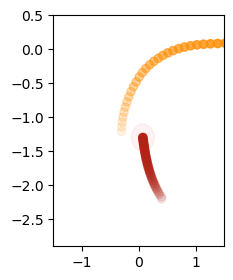

In [65]:
# display iterative trajectories
num = 1000
fig, ax = plt.subplots(figsize=(2.2,3))
# ax.set_xlim([-0.95, 0.95])
# ax.set_ylim([-2.6, 0])

def animate3(i):
    ax.clear()
    # ax.set_xlim([-0.95, 0.95])
    ax.set_xlim([-1.5, 1.5])
    ax.set_ylim([-2.9, 0.5])
    alphas = np.linspace(0.1, 1.0, i+1)
    ax.scatter(state_traj_iterative[num,0,:i+1], state_traj_iterative[num,2,:i+1], color=color_list[0], alpha=alphas, label='ego')
    ax.scatter(state_traj_iterative[num,6,:i+1], state_traj_iterative[num,8,:i+1], color=color_list[4], alpha=alphas, label='adversary')
    ax.add_patch(matplotlib.patches.Circle((state_traj_iterative[num,6,i], state_traj_iterative[num,8,i]), 0.2, color='r', fill=True, alpha=0.05))
    return

folder = "videos_iterative"
os.makedirs(folder, exist_ok=True)
with writer.saving(fig, os.path.join(folder, f"trajectory_{num}_iterative_egox{state_traj_iterative[num,0,0]:.2f}_egoy{state_traj_iterative[num,2,0]:.2f}_advx{state_traj_iterative[num,6,0]:.2f}_advy{state_traj_iterative[num,8,0]:.2f}.mp4"), dpi=150):
    for i in tqdm(range(state_traj_iterative.shape[2])):
        animate3(i)
        writer.grab_frame()

shape of state_trajs3: (2964, 12, 31)
shape of nominal_trajs3: (2964, 12, 31)


100%|██████████| 31/31 [00:25<00:00,  1.22it/s]


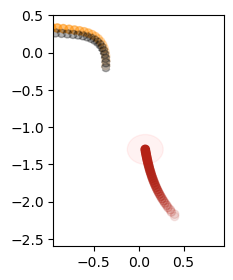

In [66]:
# display scenario optimization trajectories
print(f"shape of state_trajs3: {state_trajs3.shape}")
print(f"shape of nominal_trajs3: {nominal_trajs3.shape}")
num = 40
fig, ax = plt.subplots(figsize=(2.2,3))
ax.set_xlim([-0.95, 0.95])
ax.set_ylim([-2.6, 0])

def animate2(i):
    ax.clear()
    ax.set_xlim([-0.95, 0.95])
    # ax.set_xlim([-0.95, 2.5])
    ax.set_ylim([-2.6, 0.5])
    alphas = np.linspace(0.1, 1.0, i+1)
    ax.scatter(state_trajs3[num,0,:i+1], state_trajs3[num,2,:i+1], color=color_list[0], alpha=alphas, label='ego')
    ax.scatter(nominal_trajs3[num,0,:i+1], nominal_trajs3[num,2,:i+1], color='black', alpha=0.3, label='nominal ego', linestyle='dashed')
    ax.scatter(state_trajs3[num,6,:i+1], state_trajs3[num,8,:i+1], color=color_list[4], alpha=alphas, label='adversary')
    # ax.scatter(nominal_trajs3[num,6,:i+1], nominal_trajs3[num,8,:i+1], color='gray', alpha=0.3, label='nominal adv', linestyle='dashed')
    ax.add_patch(matplotlib.patches.Circle((state_trajs3[num,6,i], state_trajs3[num,8,i]), 0.2, color='r', fill=True, alpha=0.05))

    x = np.arange(-0.9, 0.9, 0.02)  # coarser grid for speed
    y = np.arange(-2.6, 0, 0.02)
    X, Y = np.meshgrid(x, y)
    # reward = target_set(envs, X, Y, state_trajs3[num,:,i].copy())
    reward = target_set(envs, X, Y, nominal_trajs3[num,:,i].copy())

    contf = ax.contourf(X, Y, reward, levels=[1-1e-6, 1], colors="#80A8D6", alpha=0.5)
    cont = ax.contour(X, Y, reward, levels=[1-1e-6], colors="#80A8D6", alpha=1)

    return contf, cont  # return for blitting (optional)

folder = "scenario_opt_videos"
os.makedirs(folder, exist_ok=True)
with writer.saving(fig, os.path.join(folder, f"scenario_trajectory_{num}_egox{state_trajs3[num,0,0]:.2f}_egoy{state_trajs3[num,2,0]:.2f}_advx{state_trajs3[num,6,0]:.2f}_advy{state_trajs3[num,8,0]:.2f}.mp4"), dpi=150):
    for i in tqdm(range(state_trajs3.shape[2])):
        animate2(i)
        writer.grab_frame()
